Let's analyze whether different spurious correlation methods affect the importance of spurious features in the representation.

We have models pretrained with:
* ERM
* Reweighting
* Group DRO
* Just Train Twice (JTT)
* Deep Feature Reweighting (DFR)


We will do, for each model: 
1. Decompose training data into PCA components.
2. Evaluate each component in terms of how much it can predict the spurious label.
Prediction is done by training a LogisticRegression on the decomposition for each component for T iterations.
3. Note components which have over X% accuracy in predicting the spurious label.
4. Note where in the representation top predicting components belong




In [1]:
import os, pathlib

HF_HOME = "/workspace1/araymond/.cache/huggingface"  # ajústalo si quieres
os.environ["HF_HOME"] = HF_HOME
os.environ["TRANSFORMERS_CACHE"]     = f"{HF_HOME}/transformers"   # legacy, aún funciona
os.environ["HF_DATASETS_CACHE"]      = f"{HF_HOME}/datasets"
os.environ["HUGGINGFACE_HUB_CACHE"]  = f"{HF_HOME}/hub"
os.environ["TOKENIZERS_PARALLELISM"] = "false"  # opcional: silencia warnings

# Crea las carpetas si no existen
for key in ("TRANSFORMERS_CACHE", "HF_DATASETS_CACHE", "HUGGINGFACE_HUB_CACHE"):
    pathlib.Path(os.environ[key]).mkdir(parents=True, exist_ok=True)

print("HF_HOME =", os.environ["HF_HOME"])
from collections import defaultdict
from copy import deepcopy
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import pandas as pd

# ==== tu setup y utilidades existentes ====
import numpy as np
import sys
sys.path.append("/workspace1/araymond/svdrop/")
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score
from easydict import EasyDict as edict
from utils import SimpleCNN, SVDropClassifier
import torchvision
from data.data import prepare_data

from pytorch_transformers import BertConfig, BertForSequenceClassification
from transformers import BertForSequenceClassification as BertForSequenceClassification2
cub_dict = {0.0: 50, 0.25: 625, 0.5: 75, 0.75: 875, 0.9: 95, 1.0: 100}

def setup(model, dataset , dataset_corr):
    args = edict()
    args.dataset = dataset
    args.root_dir = "/workspace1/araymond/datasets"

    args.augment_data = None
    if dataset == "MNISTCIFAR":
        args.target_name = f"waterbird_complete{dataset_corr}"
        args.confounder_names = [dataset_corr]
        args.fraction = 1.0
    elif dataset =="CelebA":
        args.target_name = f"Blond_Hair"
        args.confounder_names = ["Male"]
        args.fraction = 1.0
    elif dataset == "CUB":
        args.target_name = f"waterbird_complete{cub_dict[dataset_corr]}"
        args.confounder_names = ["forest2water2"]
        args.fraction = 1.0
    elif dataset == "MultiNLI":
        args.target_name = "gold_label_random"
        args.confounder_names = ["sentence2_has_negation"]
        args.fraction = 1.0
        args.augment_data = False
    elif dataset == "civilcomments":
        args.augment_data = False
        args.dataset = "jigsaw"
        args.target_name = "toxicity"
        args.confounder_names = ["identity_any"]
        args.fraction = 1.0
    else:
        raise ValueError(f"Dataset {dataset} not supported.")
    args.model = model
 
    args.shift_type = "confounder"

    if dataset == "civilcomments":
        args.metadata_csv_name = "all_data_with_identities.csv"
    else:
        args.metadata_csv_name = 'metadata.csv'
        
    return args

def get_reps(model, dl, device="cuda", remove="none"):
    import torch.nn as nn
    from copy import deepcopy

    temp_model = deepcopy(model).to(device).eval()

    # Detecta si el modelo es BERT (pytorch_transformers o transformers)
    is_hf_bert = hasattr(temp_model, "bert") or "bert" in temp_model.__class__.__name__.lower()

    results = None
    y_label = None
    y_spur = None

    with torch.no_grad():
        for x, y, g, *_ in tqdm(dl):
            if is_hf_bert:
                # x: [B, L, 3]  ->  ids / mask / token_type_ids
                input_ids    = x[:, :, 0].long().to(device)
                attention_ms = x[:, :, 1].long().to(device)
                token_types  = x[:, :, 2].long().to(device)

                # Forward SOLO el encoder para sacar representación (CLS)
                enc_out = temp_model.bert(
                    input_ids=input_ids,
                    attention_mask=attention_ms,
                    token_type_ids=token_types,
                )

                # Compatibilidad: pytorch_transformers devuelve tuple
                # (last_hidden_state, pooled_output, ...)
                if isinstance(enc_out, tuple):
                    pooled = enc_out[1]                # pooled CLS
                    # Si prefieres mean-pooling:
                    # last_hidden = enc_out[0]
                    # pooled = (last_hidden * attention_ms.unsqueeze(-1)).sum(1) / attention_ms.sum(1, keepdim=True).clamp(min=1)
                else:
                    # transformers moderno: objeto con atributos
                    pooled = enc_out.pooler_output     # [B, 768]

                reps = pooled.detach().cpu()

            else:
                # Rama visión (igual que antes)
                x = x.to(device)
                if remove == "spur":
                    x[:, :, 32:, :] *= 0
                elif remove == "nonspur":
                    x[:, :, :32, :] *= 0

                # Quita la última capa si existe
                if hasattr(temp_model, "fc"):
                    temp_model.fc = nn.Identity()
                elif hasattr(temp_model, "classifier"):
                    temp_model.classifier = nn.Identity()

                reps = temp_model(x).detach().cpu()

            g = (g % 2).cpu()  # tu definición de “spurious”

            if results is None:
                results, y_label, y_spur = reps, y.cpu(), g
            else:
                results = torch.cat([results, reps], dim=0)
                y_label = torch.cat([y_label, y.cpu()], dim=0)
                y_spur  = torch.cat([y_spur,  g], dim=0)

    return results, y_label, y_spur


def load_model(dataset, method, model_corr, seed=111):
    # Estructura esperada:
    # {DATASET}/{METHOD}_{MODEL_CORR}/model_outputs_{SEED}/best_model.pth
    # CelebA no lleva correlación en la ruta del modelo
    if dataset == "CUB":
        model_corr = cub_dict[model_corr]
    if dataset != "CelebA":
        path = f"{dataset}/{method}_{model_corr}/model_outputs_{seed}/best_model.pth"
    else:
        path = f"{dataset}/{method}/model_outputs_{seed}/best_model.pth"
    if not os.path.exists(path):  # si no hay best_model, intenta con el 0_model
        print(f"Couldn't find best_model.pth for dataset: {dataset}, method: {method}, seed: {seed}!")
        path = path.replace("best_model.pth", "0_model.pth")

    weights = torch.load(path, map_location="cpu")

    if dataset == "MNISTCIFAR":
        m = SimpleCNN([32,64,128], 1, num_classes=2, add_pooling=False)
    elif dataset in ["MultiNLI", "civilcomments"]:
        if dataset == "MultiNLI":
            config_class = BertConfig
            model_class = BertForSequenceClassification

            config = config_class.from_pretrained("bert-base-uncased",
                                                num_labels=3,
                                                finetuning_task="mnli")
            m = model_class.from_pretrained("bert-base-uncased",
                                                from_tf=False,
                                                config=config)
        elif dataset == "civilcomments":
            m = BertForSequenceClassification2.from_pretrained(
                "bert-base-uncased",
                num_labels=2)
        else: 
            raise NotImplementedError
    else:
        m = torchvision.models.resnet50(pretrained=True)
        d = m.fc.in_features
        m.fc = SVDropClassifier(d, 2)

    m.load_state_dict(weights)
    m.eval()
    return m

# ==== NUEVO: Guardado de representaciones por dataset / corr / método / semilla ====

def make_subdir_for_reps(dataset, method, dataset_corr):
    """Devuelve el subdir que empata la nomenclatura de modelos para este dataset."""
    if dataset == "CelebA":
        sub = f"{method}"  # CelebA no usa corr en la ruta del modelo
    else:
        corr_tag = cub_dict[dataset_corr] if dataset == "CUB" else dataset_corr
        sub = f"{method}_{corr_tag}"
    return os.path.join("reps", dataset, sub)

def save_reps(base_dir, seed, split, R, y, g):
    os.makedirs(os.path.join(base_dir, f"seed_{seed}"), exist_ok=True)
    out_path = os.path.join(base_dir, f"seed_{seed}", f"{split}.pt")
    torch.save({"R": R, "y": y, "g": g}, out_path)
    print(f"[saved] {out_path}  -> R:{tuple(R.shape)}  y:{tuple(y.shape)}  g:{tuple(g.shape)}")

# Parámetros
methods = ["erm"]
seeds = [111]
bs = {'MNISTCIFAR': 10000, 'CUB': 128, "CelebA": 512, "MultiNLI": 32, "civilcomments":32}
corrs = {
    "MNISTCIFAR": [0.0, 0.25, 0.5, 0.75, 0.9],
    "CUB":        [0.0, 0.25, 0.5, 0.75, 0.9],
    "CelebA":     [0.9],
    "MultiNLI":     [0.9],
    "civilcomments":     [0.9]
}

device = "cuda" if torch.cuda.is_available() else "cpu"
datasets = ["CelebA"]
for dataset in tqdm(datasets, desc="Datasets"):
    if dataset in ['MultiNLI',"civilcomments"]:
        m = "bert-base-uncased" 
    elif dataset == "MNISTCIFAR":
        m = "scnn"
    else:
        m="resnet50"
    for dataset_corr in tqdm(corrs[dataset], desc=f"{dataset} correlations"):
        # dataset / loaders
        args = setup(m, dataset, dataset_corr)
        args.batch_size = bs[dataset]
        data = prepare_data(args, train=True)
        dls = {
            'train': DataLoader(data[0], batch_size=bs[dataset], shuffle=False),
            'test':  DataLoader(data[1], batch_size=bs[dataset], shuffle=False)
        }

        for method in tqdm(methods, leave=False, desc="Methods"):
            subdir = make_subdir_for_reps(dataset, method, dataset_corr)

            for seed in tqdm(seeds, desc="Seeds"):
                print(f"\n=== {dataset} | corr={dataset_corr} | {method} | seed={seed} ===")
                model = load_model(dataset, method, dataset_corr, seed=seed)

                print("Getting train reps")
                R_train, y_train, g_train = get_reps(model, dls['train'], device=device)
                print("Getting test reps")
                R_test,  y_test,  g_test  = get_reps(model, dls['test'],  device=device)

                # guardar
                save_reps(subdir, seed, "train", R_train, y_train, g_train)
                save_reps(subdir, seed, "test",  R_test,  y_test,  g_test)


HF_HOME = /workspace1/araymond/.cache/huggingface


/home/araymond/pyenv/versions/mini/lib/python3.10/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Datasets:   0%|          | 0/1 [00:00<?, ?it/s]

CelebA correlations:   0%|          | 0/1 [00:00<?, ?it/s]

Methods:   0%|          | 0/1 [00:00<?, ?it/s]

...

Getting train reps


  0%|          | 0/318 [00:00<?, ?it/s]

Getting test reps


  0%|          | 0/39 [00:00<?, ?it/s]

[saved] reps/CelebA/erm/seed_111/train.pt  -> R:(162770, 2048)  y:(162770,)  g:(162770,)
[saved] reps/CelebA/erm/seed_111/test.pt  -> R:(19867, 2048)  y:(19867,)  g:(19867,)


## Obtain all final classifier layers

In [9]:
import os
import torch
import torch.nn as nn
import torchvision

# ==== CONFIG ====
METHODS  = ["erm", "rw_erm", "gdro", "erm_gdro", "erm_rw", "erm_dfr","erm_dfr_rw","erm_dfr_gdro"]
SEEDS    = [111, 222, 333]
DATASETS = ["MNISTCIFAR", "CUB", "CelebA", "MultiNLI", "civilcomments"]  # <-- añadido
CORRS = {
    "MNISTCIFAR": [0.0, 0.25, 0.5, 0.75, 0.9],
    "CUB":        [0.0, 0.25, 0.5, 0.75, 0.9],
    "CelebA":     [0.9],
    "MultiNLI":   [0.9],
    "civilcomments": [0.9],
}

CUB_MAP = {0.0: 50, 0.25: 625, 0.5: 75, 0.75: 875, 0.9: 95, 1.0: 100}

OUT_ROOT = "final_classifiers"
OUT_AGG  = os.path.join(OUT_ROOT, "all_classifiers.pt")
os.makedirs(OUT_ROOT, exist_ok=True)

import sys
sys.path.append("/workspace1/araymond/svdrop/")
from utils import SimpleCNN, SVDropClassifier  # para los modelos CNN/ResNet

# ====== BERT (sin descargar nada) ======
# Usamos config locales (valores por defecto = BERT base),
# no llamamos .from_pretrained(...) para evitar accesos a HF.
def build_bert_multinli(num_labels=3):
    try:
        from pytorch_transformers import BertConfig, BertForSequenceClassification
    except Exception:
        # fallback a transformers modernos si no está pytorch_transformers
        from transformers import BertConfig, BertForSequenceClassification
    cfg = BertConfig(num_labels=num_labels)  # base config, no descarga
    return BertForSequenceClassification(cfg)

def build_bert_civil(num_labels=2):
    try:
        from transformers import BertConfig, BertForSequenceClassification
    except Exception:
        from pytorch_transformers import BertConfig, BertForSequenceClassification
    cfg = BertConfig(num_labels=num_labels)  # base config, no descarga
    return BertForSequenceClassification(cfg)

# ==== helpers ====
def build_checkpoint_path(dataset: str, method: str, corr_float, seed: int) -> str:
    """Devuelve la ruta del checkpoint según tu convención."""
    if dataset == "CUB":
        corr_tag = CUB_MAP[corr_float]
        path = f"{dataset}/{method}_{corr_tag}/model_outputs_{seed}/best_model.pth"
    elif dataset == "CelebA":
        path = f"{dataset}/{method}/model_outputs_{seed}/best_model.pth"
    else:  # MNISTCIFAR, MultiNLI, civilcomments
        path = f"{dataset}/{method}_{corr_float}/model_outputs_{seed}/best_model.pth"
    if not os.path.exists(path):
        path = path.replace("best_model.pth", "0_model.pth")
    return path

def _strip_module_prefix(state):
    """Quita 'module.' si viene de DataParallel/DistributedDataParallel."""
    if any(k.startswith("module.") for k in state.keys()):
        return {k.replace("module.", "", 1): v for k, v in state.items()}
    return state

def _normalize_resnet_fc_keys(state):
    """
    Normaliza distintas variantes de la cabeza fc de ResNet:
    - fc.1.weight/bias -> fc.weight/bias  (Sequential con la Linear en idx 1)
    - fc.0.weight/bias -> fc.weight/bias  (por si la Linear estaba en idx 0)
    Elimina otras keys de fc.* que sobran (p.ej. dropout en fc.0.*).
    """
    state = _strip_module_prefix(state)
    has_fc_weight = "fc.weight" in state or "fc.bias" in state

    # Detecta variantes secuenciales
    if ("fc.1.weight" in state) or ("fc.0.weight" in state):
        # Prefiere el índice que tenga weight/bias presentes
        src_idx = None
        if "fc.1.weight" in state:
            src_idx = "1"
        elif "fc.0.weight" in state:
            src_idx = "0"

        if src_idx is not None:
            # Clona a fc.weight/bias
            if f"fc.{src_idx}.weight" in state:
                state["fc.weight"] = state[f"fc.{src_idx}.weight"]
            if f"fc.{src_idx}.bias" in state:
                state["fc.bias"] = state[f"fc.{src_idx}.bias"]

            # Limpia otras entradas bajo fc.* que no sean las finales
            for k in list(state.keys()):
                if k.startswith("fc.") and k not in ("fc.weight", "fc.bias"):
                    state.pop(k, None)

            has_fc_weight = True

    # Si después de normalizar seguimos sin fc.weight, no tocamos más
    return state, has_fc_weight

def load_model(dataset: str, method: str, corr_float, seed: int) -> nn.Module:
    """Reconstruye el modelo y carga el state_dict (robusto a variantes de la cabeza)."""
    ckpt_path = build_checkpoint_path(dataset, method, corr_float, seed)
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f"No existe checkpoint: {ckpt_path}")

    weights = torch.load(ckpt_path, map_location="cpu")
    state = weights["state_dict"] if isinstance(weights, dict) and "state_dict" in weights else weights
    # --- normaliza prefijos y cabeza fc ---
    state, has_fc = _normalize_resnet_fc_keys(state)

    # Construye el modelo base
    if dataset == "MNISTCIFAR":
        m = SimpleCNN([32, 64, 128], 1, num_classes=2, add_pooling=False)
    elif dataset in ["MultiNLI", "civilcomments"]:
        if dataset == "MultiNLI":
            m = build_bert_multinli(num_labels=3)    # 3 clases
        else:  # civilcomments
            m = build_bert_civil(num_labels=2)       # binario
    else:
        m = torchvision.models.resnet50(pretrained=False)
        d = m.fc.in_features

        # Si el checkpoint trae una fc lineal estándar, usa nn.Linear para que casen las keys.
        # Si prefieres siempre SVDropClassifier, asegúrate que su state_dict exponga 'weight'/'bias' como Linear.
        if has_fc:
            m.fc = nn.Linear(d, 2, bias=True)
        else:
            # fallback: mantén tu cabeza por defecto, pero el load podría quedar partial
            m.fc = SVDropClassifier(d, 2)

    # Intenta cargar con strict=False para tolerar buffers/keys no relevantes tras normalización
    missing, unexpected = m.load_state_dict(state, strict=False)
    if missing or unexpected:
        print(f"[info] load_state_dict tolerante | missing={missing} | unexpected={unexpected}")

    m.eval()
    return m

def find_final_linear(model: nn.Module) -> nn.Linear:
    """Encuentra la capa lineal final."""
    # ResNets/tu SVDrop
    if hasattr(model, "fc"):
        # SVDropClassifier o Linear
        if isinstance(model.fc, (SVDropClassifier, nn.Linear)):
            return model.fc
        # si fuese un contenedor, busca la última Linear dentro
        for mod in reversed(list(model.fc.modules())):
            if isinstance(mod, nn.Linear):
                return mod

    # BERT (HF) suele tener .classifier como Linear
    if hasattr(model, "classifier") and isinstance(model.classifier, nn.Linear):
        return model.classifier

    # fallback: última Linear del modelo
    for mod in reversed(list(model.modules())):
        if isinstance(mod, nn.Linear):
            return mod

    raise RuntimeError("No pude localizar la capa lineal final (nn.Linear).")

def extract_classifier_params(model: nn.Module):
    """Extrae (W, b, w_dir) del último Linear. w_dir sólo si C=2."""
    last = find_final_linear(model)
    W = last.weight.detach().cpu().clone()  # (C, D)
    b = last.bias.detach().cpu().clone() if last.bias is not None else torch.zeros(W.size(0))
    w_dir = None
    if W.dim() == 2 and W.size(0) == 2:
        w_dir = (W[1] - W[0]).contiguous()
    return W, b, w_dir

def subdir_for_save(dataset: str, method: str, corr_float):
    """Nombre de subcarpeta de salida (coincide con tu convención)."""
    if dataset == "CUB":
        return f"{method}_{CUB_MAP[corr_float]}"
    elif dataset == "CelebA":
        return f"{method}"
    else:
        return f"{method}_{corr_float}"

def save_per_model_classifier(dataset: str, method: str, corr_float, seed: int, W, b, w_dir, overwrite=False):
    out_dir = os.path.join(OUT_ROOT, dataset, subdir_for_save(dataset, method, corr_float), f"seed_{seed}")
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, "classifier.pt")
    if (not overwrite) and os.path.exists(out_path):
        # no pisar resultados previos
        return
    torch.save(
        {"W": W, "b": b, "w_dir": w_dir,
         "meta": {
             "dataset": dataset,
             "method": method,
             "seed": seed,
             "corr_float": None if dataset == "CelebA" else float(corr_float),
             "corr_tag": None if dataset != "CUB" else int(CUB_MAP[corr_float]),
             "D": int(W.shape[1]),
             "C": int(W.shape[0]),
         }},
        out_path
    )

# ==== cargar agregado existente (si hay) para no perder nada ====
agg = {}
if os.path.exists(OUT_AGG):
    try:
        agg = torch.load(OUT_AGG, map_location="cpu")
    except Exception:
        agg = {}

# ==== Recorrido + guardado ====
for dataset in DATASETS:
    for corr in CORRS[dataset]:
        for method in METHODS:
            for seed in SEEDS:
                try:
                    model = load_model(dataset, method, corr, seed)
                except FileNotFoundError as e:
                    print(f"[skip] {e}")
                    continue
                except Exception as e:
                    print(f"[warn] carga {dataset}-{method}-seed{seed}-corr{corr}: {e}")
                    continue

                try:
                    W, b, w_dir = extract_classifier_params(model)
                except Exception as e:
                    print(f"[warn] extraer {dataset}-{method}-seed{seed}-corr{corr}: {e}")
                    continue

                save_per_model_classifier(dataset, method, corr, seed, W, b, w_dir, overwrite=False)

                key = (dataset, method, seed, None if dataset == "CelebA" else float(corr))
                agg[key] = {
                    "W": W, "b": b, "w_dir": w_dir,
                    "meta": {
                        "dataset": dataset,
                        "method": method,
                        "seed": seed,
                        "corr_float": None if dataset == "CelebA" else float(corr),
                        "corr_tag": None if dataset != "CUB" else int(CUB_MAP[corr]),
                        "D": int(W.shape[1]),
                        "C": int(W.shape[0]),
                    }
                }
                print(f"[ok] {dataset} | {method} | seed={seed} | corr={corr} -> W:{tuple(W.shape)}")

torch.save(agg, OUT_AGG)
print(f"\n[OK] Agregado actualizado en: {OUT_AGG}")
print(f"[OK] Guardados individuales bajo: {OUT_ROOT}/<dataset>/<method[_corr]>/seed_<seed>/classifier.pt")


[ok] MNISTCIFAR | erm | seed=111 | corr=0.0 -> W:(2, 2688)
[ok] MNISTCIFAR | erm | seed=222 | corr=0.0 -> W:(2, 2688)
[ok] MNISTCIFAR | erm | seed=333 | corr=0.0 -> W:(2, 2688)
[ok] MNISTCIFAR | rw_erm | seed=111 | corr=0.0 -> W:(2, 2688)
[ok] MNISTCIFAR | rw_erm | seed=222 | corr=0.0 -> W:(2, 2688)
[ok] MNISTCIFAR | rw_erm | seed=333 | corr=0.0 -> W:(2, 2688)
[ok] MNISTCIFAR | gdro | seed=111 | corr=0.0 -> W:(2, 2688)
[ok] MNISTCIFAR | gdro | seed=222 | corr=0.0 -> W:(2, 2688)
[ok] MNISTCIFAR | gdro | seed=333 | corr=0.0 -> W:(2, 2688)
[ok] MNISTCIFAR | erm_gdro | seed=111 | corr=0.0 -> W:(2, 2688)
[ok] MNISTCIFAR | erm_gdro | seed=222 | corr=0.0 -> W:(2, 2688)
[ok] MNISTCIFAR | erm_gdro | seed=333 | corr=0.0 -> W:(2, 2688)
[ok] MNISTCIFAR | erm_rw | seed=111 | corr=0.0 -> W:(2, 2688)
[ok] MNISTCIFAR | erm_rw | seed=222 | corr=0.0 -> W:(2, 2688)
[ok] MNISTCIFAR | erm_rw | seed=333 | corr=0.0 -> W:(2, 2688)
[skip] No existe checkpoint: MNISTCIFAR/erm_dfr_0.0/model_outputs_111/0_model.p

KeyboardInterrupt: 

In [3]:
df =  pd.DataFrame.from_dict(final_report)
df.to_csv(f"spurious_analysis_{dataset}.csv")    

## Training Spurious Classifier

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from tqdm.notebook import tqdm

# ========= Config =========
REPS_ROOT = "reps"
OUT_ROOT  = "linear_heads_ce"
os.makedirs(OUT_ROOT, exist_ok=True)

METHODS   = ["erm", "gdro", "rw_erm"]  # puedes reactivar "rw_erm" si ya tienes reps
SEEDS     = [111, 222, 333]
DATASETS  = ["MultiNLI", "civilcomments"]  # <-- añadidos
CORRS = {
    "MNISTCIFAR": [0.0, 0.25, 0.5, 0.75, 0.9],
    "CUB":        [0.0, 0.25, 0.5, 0.75, 0.9],
    "CelebA":     [0.9],
    "MultiNLI":   [0.9],
    "civilcomments": [0.9],
}
CUB_MAP = {0.0: 50, 0.25: 625, 0.5: 75, 0.75: 875, 0.9: 95, 1.0: 100}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ========= Utilidades de carga =========
def _subdir_for_reps(dataset: str, method: str, corr_float):
    if dataset == "CelebA":
        return f"{method}"
    if dataset == "CUB":
        return f"{method}_{CUB_MAP[corr_float]}"
    return f"{method}_{corr_float}"  # MNISTCIFAR, MultiNLI, civilcomments

def reps_path(dataset: str, method: str, corr_float, seed: int, split: str):
    sub = _subdir_for_reps(dataset, method, corr_float)
    return os.path.join(REPS_ROOT, dataset, sub, f"seed_{seed}", f"{split}.pt")

def load_reps(dataset, method, corr_float, seed, split):
    path = reps_path(dataset, method, corr_float, seed, split)
    obj = torch.load(path, map_location="cpu", weights_only=False)
    R = obj["R"].float()               # (N, D)
    y = obj["y"].long().view(-1)       # (N,)
    # g ya fue guardado como binario en tu pipeline; %2 por seguridad (idempotente)
    g = (obj["g"] % 2).long().view(-1) # (N,)
    return R, y, g

def load_reps_concat(dataset, method, corr, seed, splits=("train","test")):
    Rs, ys, gs = [], [], []
    for sp in splits:
        path = reps_path(dataset, method, corr, seed, sp)
        if not os.path.exists(path):
            raise FileNotFoundError(f"Faltan reps: {path}")
        R, y, g = load_reps(dataset, method, corr, seed, sp)
        Rs.append(R); ys.append(y); gs.append(g)
    R = torch.cat(Rs, dim=0)
    y = torch.cat(ys, dim=0)
    g = torch.cat(gs, dim=0)
    return R, y, g

# ========= Balanceo =========
def _balanced_indices_binary(binary_labels, n_per=None, seed=0):
    rng = np.random.default_rng(seed)
    lbl = np.asarray(binary_labels, dtype=int).reshape(-1)
    idx0 = np.where(lbl == 0)[0]
    idx1 = np.where(lbl == 1)[0]
    if len(idx0) == 0 or len(idx1) == 0:
        raise ValueError(f"No se puede balancear: counts -> 0:{len(idx0)} 1:{len(idx1)}")
    if n_per is None:
        n_per = min(len(idx0), len(idx1))
    rng.shuffle(idx0); rng.shuffle(idx1)
    chosen = np.concatenate([idx0[:n_per], idx1[:n_per]])
    rng.shuffle(chosen)
    return chosen

def _balanced_indices_multiclass(labels, n_per=None, seed=0):
    """
    Balancea uniformemente entre todas las clases presentes.
    Si n_per es None, usa el mínimo conteo entre clases.
    """
    rng = np.random.default_rng(seed)
    lbl = np.asarray(labels, dtype=int).reshape(-1)
    classes, counts = np.unique(lbl, return_counts=True)
    if len(classes) < 2:
        raise ValueError("Sólo hay una clase presente; no se puede balancear multiclase.")
    k = counts.min() if n_per is None else min(int(n_per), counts.min())
    chosen = []
    for c in classes:
        c_idx = np.where(lbl == c)[0]
        rng.shuffle(c_idx)
        chosen.extend(c_idx[:k])
    chosen = np.array(chosen)
    rng.shuffle(chosen)
    return chosen

def balance_by_g(R, y, g, seed=0, n_per=None):
    idx = _balanced_indices_binary((g % 2).cpu().numpy(), n_per=n_per, seed=seed)
    return R[idx], y[idx], g[idx], idx

def balance_by_y(R, y, g, seed=0, n_per=None):
    y_np = y.cpu().numpy()
    n_classes = int(len(np.unique(y_np)))
    if n_classes == 2:
        idx = _balanced_indices_binary(y_np, n_per=n_per, seed=seed)
    else:
        idx = _balanced_indices_multiclass(y_np, n_per=n_per, seed=seed)
    return R[idx], y[idx], g[idx], idx

# ========= Head lineal (CE) =========
class LinearHead(nn.Module):
    def __init__(self, in_dim: int, out_dim: int):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim)
    def forward(self, x):
        return self.fc(x)

@torch.no_grad()
def accuracy(logits: torch.Tensor, y: torch.Tensor) -> float:
    pred = logits.argmax(dim=1)
    return (pred == y).float().mean().item()

def train_linear_head_ce(X: torch.Tensor,
                         y_target: torch.Tensor,
                         epochs: int = 30,
                         batch_size: int = 512,
                         lr: float = 1e-2,
                         weight_decay: float = 0.0,
                         seed: int = 0,
                         out_dim: int = 2):
    torch.manual_seed(seed)
    in_dim = X.shape[1]
    head = LinearHead(in_dim, out_dim).to(DEVICE)
    ds = TensorDataset(X, y_target)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

    opt = torch.optim.Adam(head.parameters(), lr=lr, weight_decay=weight_decay)
    crit = nn.CrossEntropyLoss()

    head.train()
    for _ in range(epochs):
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = head(xb)
            loss = crit(logits, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()

    head.eval()
    with torch.no_grad():
        logits = head(X.to(DEVICE))
        train_acc = accuracy(logits, y_target.to(DEVICE))
    return head.cpu(), train_acc

def save_head(dataset, method, corr_float, seed, target_tag, head, n_train, D, train_acc):
    # target_tag ∈ {"spurious", "class"}
    out_dir = os.path.join(OUT_ROOT, dataset, _subdir_for_reps(dataset, method, corr_float), f"seed_{seed}", target_tag)
    os.makedirs(out_dir, exist_ok=True)

    W = head.fc.weight.detach().clone()      # (C, D)
    b = head.fc.bias.detach().clone()        # (C,)
    w_dir = None
    if W.shape[0] == 2:
        w_dir = (W[1] - W[0]).contiguous()

    payload = {
        "state_dict": head.state_dict(),
        "W": W, "b": b, "w_dir": w_dir,
        "meta": {
            "dataset": dataset,
            "method": method,
            "seed": seed,
            "corr_float": None if dataset == "CelebA" else float(corr_float),
            "corr_tag": None if dataset != "CUB" else int(CUB_MAP[corr_float]),
            "target": target_tag,     # "spurious" o "class"
            "n_train": int(n_train),
            "D": int(D),
            "C": int(W.shape[0]),
            "loss": "CrossEntropyLoss",
            "head": f"nn.Linear(D,{W.shape[0]})"
        },
        "metrics": {
            "train_acc": float(train_acc)
        }
    }
    out_path = os.path.join(out_dir, "linear_head.pt")
    torch.save(payload, out_path)
    return out_path

# ========= Loop principal =========
def run_all(seeds=SEEDS, methods=METHODS, datasets=DATASETS, corrs=CORRS,
            seed_balance=42, n_per_shared=None, train_source="both"):
    """
    Entrena heads lineales nn.Linear(D,C) con CrossEntropy **usando el split TEST** (o train+test si train_source="both").
    - target "spurious": balanceo 50/50 por g y se entrena con g (C=2)
    - target "class":    balanceo uniforme por y y se entrena con y (C=#clases; p.ej. 3 para MultiNLI)
    Guarda en: linear_heads_ce/.../<spurious|class>/linear_head.pt
    """
    logs = []
    for dataset in tqdm(datasets, desc="Datasets"):
        for corr in tqdm(corrs[dataset], desc="Correlations"):
            for method in tqdm(methods, desc="Methods"):
                for seed in tqdm(seeds, "seeds"):
                    te_path = reps_path(dataset, method, corr, seed, "test")
                    if not os.path.exists(te_path):
                        print(f"[skip] faltan reps de test: {te_path}")
                        continue

                    # Cargar reps
                    if train_source == "both":
                        R, y, g = load_reps_concat(dataset, method, corr, seed, splits=("train","test"))
                        trained_on = "train+test"
                    else:
                        R, y, g = load_reps(dataset, method, corr, seed, train_source)
                        trained_on = train_source
                    Rte, yte, gte = load_reps(dataset, method, corr, seed, "test")

                    # Determinar #clases de y desde TEST (robusto)
                    classes_y = torch.unique(yte).cpu().numpy().tolist()
                    C_y = len(classes_y)  # 2 para binario, 3 para MultiNLI

                    # n_per compartido (opcional, calculado sobre TEST)
                    n_per = None
                    if n_per_shared is not None:
                        # g siempre binario
                        cnt_g0 = int((gte == 0).sum())
                        cnt_g1 = int((gte == 1).sum())
                        # para y multiclase tomamos el mínimo entre todas las clases
                        counts_y = [int((yte == c).sum()) for c in classes_y]
                        n_per = min(cnt_g0, cnt_g1, min(counts_y), int(n_per_shared))

                    # ----- head entrenada con g -> "spurious" (sobre TEST) -----
                    try:
                        Xg, Yg, Gg, _ = balance_by_g(Rte, yte, gte, seed=seed_balance, n_per=n_per)
                        head_g, fit_acc_g = train_linear_head_ce(
                            Xg, (Gg % 2), epochs=50, batch_size=512, lr=1e-2, seed=seed, out_dim=2
                        )
                        out_g = save_head(
                            dataset, method, corr, seed, "spurious",
                            head_g, Xg.shape[0], Xg.shape[1], fit_acc_g
                        )
                        print(f"[ok][spurious-TEST] {dataset} | {method} | seed={seed} | corr={corr} | "
                              f"train_on={trained_on} | N={Xg.shape[0]} | acc={fit_acc_g:.3f} -> {out_g}")
                        logs.append(("spurious", dataset, method, seed, corr, Xg.shape[0], fit_acc_g, out_g))
                    except Exception as e:
                        print(f"[warn][spurious-TEST] {dataset}-{method}-seed{seed}-corr{corr}: {e}")

                    # ----- head entrenada con y -> "class" (sobre TEST) -----
                    try:
                        Xy, Yy, Gy, _ = balance_by_y(Rte, yte, gte, seed=seed_balance, n_per=n_per)
                        head_y, fit_acc_y = train_linear_head_ce(
                            Xy, Yy, epochs=30, batch_size=512, lr=1e-2, seed=seed, out_dim=C_y
                        )
                        out_y = save_head(
                            dataset, method, corr, seed, "class",
                            head_y, Xy.shape[0], Xy.shape[1], fit_acc_y
                        )
                        print(f"[ok][class-TEST]    {dataset} | {method} | seed={seed} | corr={corr} | "
                              f"train_on={trained_on} | N={Xy.shape[0]} | acc={fit_acc_y:.3f} -> {out_y}")
                        logs.append(("class", dataset, method, seed, corr, Xy.shape[0], fit_acc_y, out_y))
                    except Exception as e:
                        print(f"[warn][class-TEST] {dataset}-{method}-seed{seed}-corr{corr}: {e}")
    return logs


In [3]:
logs = run_all()

Datasets:   0%|          | 0/2 [00:00<?, ?it/s]

Correlations:   0%|          | 0/1 [00:00<?, ?it/s]

Methods:   0%|          | 0/3 [00:00<?, ?it/s]

seeds:   0%|          | 0/3 [00:00<?, ?it/s]

[ok][spurious-TEST] MultiNLI | erm | seed=111 | corr=0.9 | train_on=train+test | N=12088 | acc=0.895 -> linear_heads_ce/MultiNLI/erm_0.9/seed_111/spurious/linear_head.pt
[ok][class-TEST]    MultiNLI | erm | seed=111 | corr=0.9 | train_on=train+test | N=82344 | acc=0.832 -> linear_heads_ce/MultiNLI/erm_0.9/seed_111/class/linear_head.pt
[ok][spurious-TEST] MultiNLI | erm | seed=222 | corr=0.9 | train_on=train+test | N=12088 | acc=0.907 -> linear_heads_ce/MultiNLI/erm_0.9/seed_222/spurious/linear_head.pt
[ok][class-TEST]    MultiNLI | erm | seed=222 | corr=0.9 | train_on=train+test | N=82344 | acc=0.808 -> linear_heads_ce/MultiNLI/erm_0.9/seed_222/class/linear_head.pt
[ok][spurious-TEST] MultiNLI | erm | seed=333 | corr=0.9 | train_on=train+test | N=12088 | acc=0.888 -> linear_heads_ce/MultiNLI/erm_0.9/seed_333/spurious/linear_head.pt
[ok][class-TEST]    MultiNLI | erm | seed=333 | corr=0.9 | train_on=train+test | N=82344 | acc=0.829 -> linear_heads_ce/MultiNLI/erm_0.9/seed_333/class/line

...

[ok][spurious-TEST] civilcomments | erm | seed=111 | corr=0.9 | train_on=train+test | N=37694 | acc=0.832 -> linear_heads_ce/civilcomments/erm_0.9/seed_111/spurious/linear_head.pt
[ok][class-TEST]    civilcomments | erm | seed=111 | corr=0.9 | train_on=train+test | N=10110 | acc=0.866 -> linear_heads_ce/civilcomments/erm_0.9/seed_111/class/linear_head.pt
[ok][spurious-TEST] civilcomments | erm | seed=222 | corr=0.9 | train_on=train+test | N=37694 | acc=0.834 -> linear_heads_ce/civilcomments/erm_0.9/seed_222/spurious/linear_head.pt
[ok][class-TEST]    civilcomments | erm | seed=222 | corr=0.9 | train_on=train+test | N=10110 | acc=0.863 -> linear_heads_ce/civilcomments/erm_0.9/seed_222/class/linear_head.pt
[ok][spurious-TEST] civilcomments | erm | seed=333 | corr=0.9 | train_on=train+test | N=37694 | acc=0.819 -> linear_heads_ce/civilcomments/erm_0.9/seed_333/spurious/linear_head.pt
[ok][class-TEST]    civilcomments | erm | seed=333 | corr=0.9 | train_on=train+test | N=10110 | acc=0.864 

seeds:   0%|          | 0/3 [00:00<?, ?it/s]

[ok][spurious-TEST] civilcomments | gdro | seed=111 | corr=0.9 | train_on=train+test | N=37694 | acc=0.824 -> linear_heads_ce/civilcomments/gdro_0.9/seed_111/spurious/linear_head.pt
[ok][class-TEST]    civilcomments | gdro | seed=111 | corr=0.9 | train_on=train+test | N=10110 | acc=0.839 -> linear_heads_ce/civilcomments/gdro_0.9/seed_111/class/linear_head.pt
[ok][spurious-TEST] civilcomments | gdro | seed=222 | corr=0.9 | train_on=train+test | N=37694 | acc=0.821 -> linear_heads_ce/civilcomments/gdro_0.9/seed_222/spurious/linear_head.pt
[ok][class-TEST]    civilcomments | gdro | seed=222 | corr=0.9 | train_on=train+test | N=10110 | acc=0.858 -> linear_heads_ce/civilcomments/gdro_0.9/seed_222/class/linear_head.pt
[ok][spurious-TEST] civilcomments | gdro | seed=333 | corr=0.9 | train_on=train+test | N=37694 | acc=0.805 -> linear_heads_ce/civilcomments/gdro_0.9/seed_333/spurious/linear_head.pt
[ok][class-TEST]    civilcomments | gdro | seed=333 | corr=0.9 | train_on=train+test | N=10110 |

seeds:   0%|          | 0/3 [00:00<?, ?it/s]

[ok][spurious-TEST] civilcomments | rw_erm | seed=111 | corr=0.9 | train_on=train+test | N=37694 | acc=0.857 -> linear_heads_ce/civilcomments/rw_erm_0.9/seed_111/spurious/linear_head.pt
[ok][class-TEST]    civilcomments | rw_erm | seed=111 | corr=0.9 | train_on=train+test | N=10110 | acc=0.863 -> linear_heads_ce/civilcomments/rw_erm_0.9/seed_111/class/linear_head.pt
[ok][spurious-TEST] civilcomments | rw_erm | seed=222 | corr=0.9 | train_on=train+test | N=37694 | acc=0.833 -> linear_heads_ce/civilcomments/rw_erm_0.9/seed_222/spurious/linear_head.pt
[ok][class-TEST]    civilcomments | rw_erm | seed=222 | corr=0.9 | train_on=train+test | N=10110 | acc=0.859 -> linear_heads_ce/civilcomments/rw_erm_0.9/seed_222/class/linear_head.pt
[ok][spurious-TEST] civilcomments | rw_erm | seed=333 | corr=0.9 | train_on=train+test | N=37694 | acc=0.814 -> linear_heads_ce/civilcomments/rw_erm_0.9/seed_333/spurious/linear_head.pt
[ok][class-TEST]    civilcomments | rw_erm | seed=333 | corr=0.9 | train_on=

## Calculo de alineaciones

In [14]:
import os
import math
import torch
import pandas as pd

# ===== Config =====
DATASETS  = ["MNISTCIFAR", "CUB", "CelebA", "MultiNLI", "civilcomments"]
METHODS   = ["erm", "rw_erm", "gdro", "erm_gdro", "erm_rw", "erm_dfr", "erm_dfr_rw", "erm_dfr_gdro"]  # <- añadidos
SEEDS     = [111, 222, 333]
CORRS = {
    "MNISTCIFAR":   [0.0, 0.25, 0.5, 0.75, 0.9],
    "CUB":          [0.0, 0.25, 0.5, 0.75, 0.9],
    "CelebA":       [0.9],      # no se usa en el path
    "MultiNLI":     [0.9],
    "civilcomments":[0.9],
}

FINAL_ROOT = "final_classifiers"
HEADS_ROOT = "linear_heads_ce"
OUT_CSV    = "cosine_alignment_heads_vs_models.csv"

CUB_MAP = {0.0: 50, 0.25: 625, 0.5: 75, 0.75: 875, 0.9: 95, 1.0: 100}

# En tu MultiNLIDataset: {'contradiction':0, 'entailment':1, 'neutral':2}
MULTINLI_LABEL_IDX = {"contradiction": 0, "entailment": 1, "neutral": 2}
CONTRA_IDX = MULTINLI_LABEL_IDX["contradiction"]

# === Signo por dataset/target ===
SIGN_MAP = {
    "CelebA":   {"spurious": -1, "class": +1}
    # otros datasets por defecto +1
}
def signed(value: float, dataset: str, target: str) -> float:
    return value * SIGN_MAP.get(dataset, {}).get(target, +1)

def subdir_for(dataset: str, method: str, corr: float | None) -> str:
    if dataset == "CelebA":
        return f"{method}"
    if dataset == "CUB":
        return f"{method}_{CUB_MAP[corr]}"
    # MNISTCIFAR / MultiNLI / civilcomments
    return f"{method}_{corr}"

def load_pt(path: str):
    return torch.load(path, map_location="cpu", weights_only=False)

def wdir_binary(W: torch.Tensor) -> torch.Tensor:
    """Para problema binario: W.shape = (2, D) -> W[1]-W[0]."""
    assert W.dim() == 2 and W.size(0) == 2, f"W binaria inválida: {tuple(W.shape)}"
    return (W[1] - W[0]).contiguous().view(-1)

def wdir_one_vs_rest(W: torch.Tensor, pos_idx: int) -> torch.Tensor:
    """
    Para multiclase: dirección one-vs-rest -> W[pos] - mean(W[others]).
    W: (C, D)
    """
    assert W.dim() == 2 and W.size(0) >= 2, f"W inválida: {tuple(W.shape)}"
    C = W.size(0)
    others = [i for i in range(C) if i != pos_idx]
    mean_others = W[others].mean(dim=0)
    return (W[pos_idx] - mean_others).contiguous().view(-1)

def get_wdir_from_payload(payload: dict, dataset: str, is_head: bool, head_target: str | None) -> torch.Tensor:
    """
    Devuelve el vector de dirección a comparar:
    - Modelos y heads binarios: usa w_dir si existe, o (W[1]-W[0]).
    - MultiNLI (C=3), target 'class': usa one-vs-rest para 'contradiction' (idx=0).
      (Tanto para el clasificador del modelo como para el head 'class'.)
    - Heads 'spurious' son binarios (C=2) -> como binario.
    """
    if "w_dir" in payload and payload["w_dir"] is not None:
        w = payload["w_dir"]
        w = w if isinstance(w, torch.Tensor) else torch.tensor(w)
        w = w.detach().cpu().float().view(-1)
        if w.numel() > 0:
            return w

    W = payload["W"]
    W = W if isinstance(W, torch.Tensor) else torch.tensor(W)
    W = W.detach().cpu().float()

    if dataset == "MultiNLI":
        if (not is_head) or (head_target == "class"):
            return wdir_one_vs_rest(W, pos_idx=CONTRA_IDX)
        else:
            return wdir_binary(W)

    return wdir_binary(W)

def cos_and_angle(a: torch.Tensor, b: torch.Tensor) -> tuple[float, float]:
    a = a.view(-1).float(); b = b.view(-1).float()
    na = a.norm().item(); nb = b.norm().item()
    if na == 0 or nb == 0:
        return float("nan"), float("nan")
    cosv = (a @ b).item() / (na * nb)
    cosv = max(-1.0, min(1.0, cosv))
    ang = math.degrees(math.acos(cosv))
    return float(cosv), float(ang)

# Heads a usar para comparación:
# - Si method in {'erm_gdro','erm_rw'} -> usar heads de ERM
# - Si no, usar heads del mismo método
def head_method_for(method: str) -> str:
    return "erm" if method in {"erm_gdro", "erm_rw", "erm_dfr", "erm_dfr_rw", "erm_dfr_gdro"} else method

rows = []

for dataset in DATASETS:
    for corr in CORRS[dataset]:
        for method in METHODS:
            # subcarpeta del MODELO (del método actual)
            sub_model = subdir_for(dataset, method, corr if dataset != "CelebA" else None)
            # subcarpeta de los HEADS (puede forzarse a 'erm')
            hm = head_method_for(method)
            sub_heads = subdir_for(dataset, hm, corr if dataset != "CelebA" else None)

            for seed in SEEDS:
                # paths
                model_path   = os.path.join(FINAL_ROOT, dataset, sub_model, f"seed_{seed}", "classifier.pt")
                head_sp_path = os.path.join(HEADS_ROOT, dataset, sub_heads, f"seed_{seed}", "spurious", "linear_head.pt")
                head_cl_path = os.path.join(HEADS_ROOT, dataset, sub_heads, f"seed_{seed}", "class",    "linear_head.pt")

                # cargar clasificador original (modelo)
                if not os.path.exists(model_path):
                    print(f"[skip] faltó original: {model_path}")
                    continue
                model_obj = load_pt(model_path)
                w_model = get_wdir_from_payload(model_obj, dataset=dataset, is_head=False, head_target=None)
                D_model = int(w_model.numel())

                # comparar con head SPURIOUS (de ERM si corresponde)
                if os.path.exists(head_sp_path):
                    sp_obj = load_pt(head_sp_path)
                    w_sp = get_wdir_from_payload(sp_obj, dataset=dataset, is_head=True, head_target="spurious")
                    if w_sp.numel() != D_model:
                        print(f"[warn] Dim mismatch spurious: {dataset}-{method}-seed{seed}-corr{corr} "
                              f"{w_sp.numel()} vs {D_model} — salto")
                    else:
                        cosv_raw, ang_raw = cos_and_angle(w_model, w_sp)
                        cosv = signed(cosv_raw, dataset, "spurious")
                        ang  = math.degrees(math.acos(max(-1.0, min(1.0, cosv)))) if not math.isnan(cosv) else float("nan")
                        rows.append({
                            "dataset": dataset, "method": method, "seed": seed,
                            "corr": None if dataset == "CelebA" else float(corr),
                            "target": "spurious",
                            "cosine_raw": cosv_raw, "angle_deg_raw": ang_raw,
                            "cosine": cosv, "angle_deg": ang,
                            "D": D_model,
                            "model_path": model_path, "head_path": head_sp_path,
                            "heads_method": hm  # para saber de dónde salió el head
                        })
                else:
                    print(f"[skip] faltó head spurious: {head_sp_path}")

                # comparar con head CLASS (de ERM si corresponde)
                if os.path.exists(head_cl_path):
                    cl_obj = load_pt(head_cl_path)
                    w_cl = get_wdir_from_payload(cl_obj, dataset=dataset, is_head=True, head_target="class")
                    if w_cl.numel() != D_model:
                        print(f"[warn] Dim mismatch class: {dataset}-{method}-seed{seed}-corr{corr} "
                              f"{w_cl.numel()} vs {D_model} — salto")
                    else:
                        cosv_raw, ang_raw = cos_and_angle(w_model, w_cl)
                        cosv = signed(cosv_raw, dataset, "class")  # por defecto no invertimos 'class' salvo map
                        ang  = math.degrees(math.acos(max(-1.0, min(1.0, cosv)))) if not math.isnan(cosv) else float("nan")
                        rows.append({
                            "dataset": dataset, "method": method, "seed": seed,
                            "corr": None if dataset == "CelebA" else float(corr),
                            "target": "class_contradiction_vs_rest" if dataset=="MultiNLI" else "class",
                            "cosine_raw": cosv_raw, "angle_deg_raw": ang_raw,
                            "cosine": cosv, "angle_deg": ang,
                            "D": D_model,
                            "model_path": model_path, "head_path": head_cl_path,
                            "heads_method": hm
                        })
                else:
                    print(f"[skip] faltó head class: {head_cl_path}")

# guardar resultados
df = pd.DataFrame(rows)
df.loc[df["target"] == "class_contradiction_vs_rest", "target"] = "class"
df.to_csv(OUT_CSV, index=False)
print(f"[OK] Guardado {OUT_CSV} con {len(df)} filas")
display(df.head())


[skip] faltó original: final_classifiers/MNISTCIFAR/erm_dfr_0.0/seed_111/classifier.pt
[skip] faltó original: final_classifiers/MNISTCIFAR/erm_dfr_0.0/seed_222/classifier.pt
[skip] faltó original: final_classifiers/MNISTCIFAR/erm_dfr_0.0/seed_333/classifier.pt
[skip] faltó original: final_classifiers/MNISTCIFAR/erm_dfr_rw_0.0/seed_111/classifier.pt
[skip] faltó original: final_classifiers/MNISTCIFAR/erm_dfr_rw_0.0/seed_222/classifier.pt
[skip] faltó original: final_classifiers/MNISTCIFAR/erm_dfr_rw_0.0/seed_333/classifier.pt
[skip] faltó original: final_classifiers/MNISTCIFAR/erm_dfr_gdro_0.0/seed_111/classifier.pt
[skip] faltó original: final_classifiers/MNISTCIFAR/erm_dfr_gdro_0.0/seed_222/classifier.pt
[skip] faltó original: final_classifiers/MNISTCIFAR/erm_dfr_gdro_0.0/seed_333/classifier.pt
[skip] faltó original: final_classifiers/CUB/erm_dfr_50/seed_111/classifier.pt
[skip] faltó original: final_classifiers/CUB/erm_dfr_50/seed_222/classifier.pt
[skip] faltó original: final_classi

,dataset,method,seed,corr,target,cosine_raw,angle_deg_raw,cosine,angle_deg,D,model_path,head_path,heads_method
0,MNISTCIFAR,erm,111,0.0,spurious,0.011825,89.322434,0.011825,89.322434,2688,final_classifiers/MNISTCIFAR/erm_0.0/seed_111/...,linear_heads_ce/MNISTCIFAR/erm_0.0/seed_111/sp...,erm
1,MNISTCIFAR,erm,111,0.0,class,0.223726,77.072001,0.223726,77.072001,2688,final_classifiers/MNISTCIFAR/erm_0.0/seed_111/...,linear_heads_ce/MNISTCIFAR/erm_0.0/seed_111/cl...,erm
2,MNISTCIFAR,erm,222,0.0,spurious,0.020589,88.820236,0.020589,88.820236,2688,final_classifiers/MNISTCIFAR/erm_0.0/seed_222/...,linear_heads_ce/MNISTCIFAR/erm_0.0/seed_222/sp...,erm
3,MNISTCIFAR,erm,222,0.0,class,0.355133,69.198385,0.355133,69.198385,2688,final_classifiers/MNISTCIFAR/erm_0.0/seed_222/...,linear_heads_ce/MNISTCIFAR/erm_0.0/seed_222/cl...,erm
4,MNISTCIFAR,erm,333,0.0,spurious,0.014793,89.152405,0.014793,89.152405,2688,final_classifiers/MNISTCIFAR/erm_0.0/seed_333/...,linear_heads_ce/MNISTCIFAR/erm_0.0/seed_333/sp...,erm


In [27]:
df['target'].unique()

array(['spurious', 'class'], dtype=object)

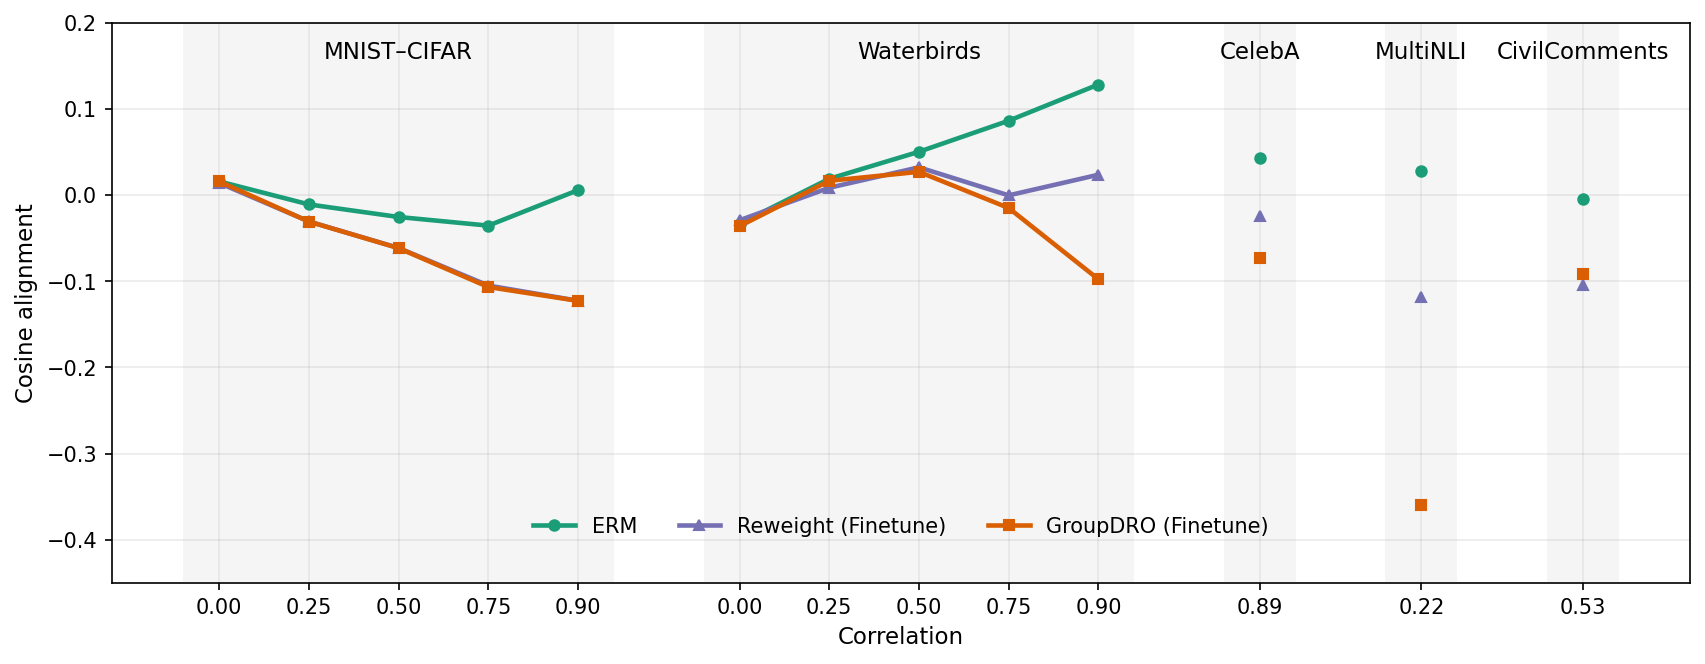

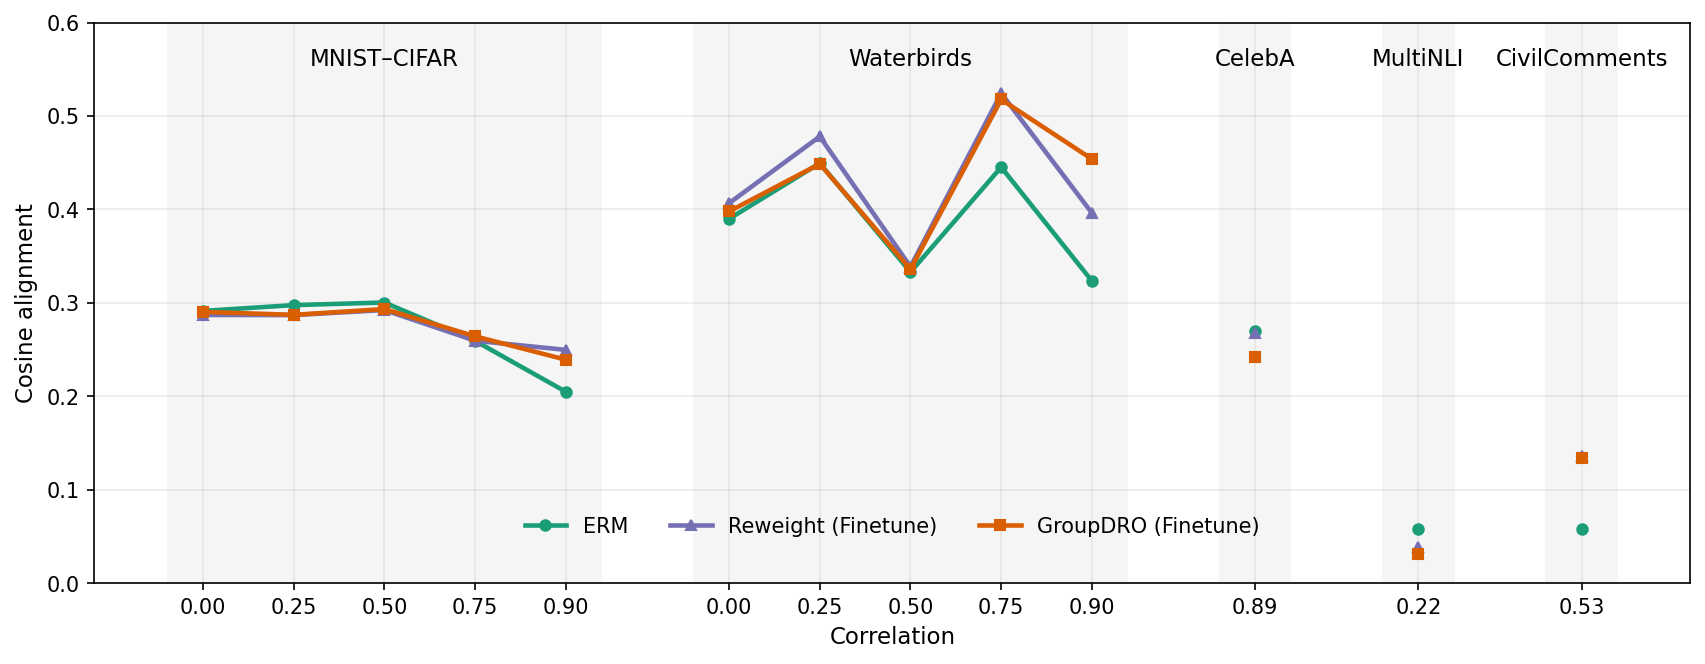

Figuras guardadas en alignment_spurious_lines.png y alignment_class_lines.png


In [51]:
# === Líneas con barras de error (std) y puntos, promedio por semilla ===
# Requiere: cosine_alignment_heads_vs_models.csv  (o final_classifiers/ & linear_heads_ce/)
import os, math, numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

DATASETS  = ["MNISTCIFAR", "CUB", "CelebA", "MultiNLI", "civilcomments"]
METHODS   = ["erm", 
             #"rw_erm", "gdro",
             "erm_rw", "erm_gdro"]
SEEDS     = [111, 222, 333]
CORRS     = {
    "MNISTCIFAR":[0.0,0.25,0.5,0.75,0.9],
    "CUB":[0.0,0.25,0.5,0.75,0.9],
    "CelebA":[0.9],
    "MultiNLI":[0.9],
    "civilcomments":[0.9],
}
CUB_MAP   = {0.0:50, 0.25:625, 0.5:75, 0.75:875, 0.9:95, 1.0:100}

FINAL_ROOT = "final_classifiers"
HEADS_ROOT = "linear_heads_ce"
CSV_CAND   = ["cosine_alignment_heads_vs_models.csv", "/mnt/data/cosine_alignment_heads_vs_models.csv"]

def subdir_for(ds, method, corr):
    if ds=="CelebA": return f"{method}"
    if ds=="CUB":    return f"{method}_{CUB_MAP[corr]}"
    # MNISTCIFAR, MultiNLI, civilcomments usan method_corr
    return f"{method}_{corr}"

def load_pt(p): 
    return torch.load(p, map_location="cpu", weights_only=False)

def _tensor(v):
    return v if isinstance(v, torch.Tensor) else torch.tensor(v)

def get_wdir(obj):
    """
    Devuelve el vector de dirección del clasificador:
    - Prioriza 'w_dir' si está guardado en el payload (recomendado).
    - Si no existe: para 2 clases, usa W[1]-W[0].
    - Si hay 3 clases y el payload es MultiNLI, usa 'contradiction vs resto':
         W[0] - 0.5*(W[1] + W[2])
    """
    # 1) si ya lo guardaste como w_dir (o w_head_dir_*), úsalo
    if "w_dir" in obj and obj["w_dir"] is not None:
        return _tensor(obj["w_dir"]).float().view(-1)

    # 2) si viene sólo W/b
    W = _tensor(obj["W"]).float()
    assert W.dim()==2, f"W con shape inesperado: {tuple(W.shape)}"
    C, D = W.shape

    # Intenta deducir dataset desde meta
    ds = None
    if "meta" in obj and isinstance(obj["meta"], dict):
        ds = obj["meta"].get("dataset", None)

    if C == 2:
        return (W[1] - W[0]).contiguous().view(-1)

    if C == 3 and (ds == "MultiNLI"):
        # contradiction (índice 0) vs (entailment, neutral)
        return (W[0] - 0.5*(W[1] + W[2])).contiguous().view(-1)

    raise ValueError(
        f"No puedo inferir w_dir: C={C}, dataset_meta={ds}. "
        "Guarda 'w_dir' en el payload al crear los clasificadores."
    )

def cosang(a,b):
    a=a.view(-1).float(); b=b.view(-1).float()
    na=a.norm().item(); nb=b.norm().item()
    if na==0 or nb==0: return float("nan"), float("nan")
    c = max(-1.0, min(1.0, float((a@b)/(na*nb))))
    return c, math.degrees(math.acos(c))

# 1) Cargar o reconstruir el DF
df = None
for p in CSV_CAND:
    if os.path.exists(p):
        df = pd.read_csv(p); break

if df is None:
    rows=[]
    for ds in DATASETS:
        for corr in CORRS[ds]:
            for m in METHODS:
                sub = subdir_for(ds, m, corr if ds!="CelebA" else None)
                for seed in SEEDS:
                    mp = os.path.join(FINAL_ROOT, ds, sub, f"seed_{seed}", "classifier.pt")
                    if not os.path.exists(mp): 
                        continue
                    wm = get_wdir(load_pt(mp))
                    for tgt in ["spurious","class"]:
                        hp = os.path.join(HEADS_ROOT, ds, sub, f"seed_{seed}", tgt, "linear_head.pt")
                        if not os.path.exists(hp): 
                            continue
                        wh = get_wdir(load_pt(hp))
                        if wh.numel()!=wm.numel(): 
                            # evita crashear si dimensiones difieren (p.ej., cambios de backbone)
                            continue
                        c, ang = cosang(wm, wh)
                        rows.append({
                            "dataset":ds,"method":m,"seed":seed,
                            "corr":None if ds=="CelebA" else float(corr),
                            "target":tgt,"cosine":c,"angle_deg":ang
                        })
    if not rows:
        raise RuntimeError("No hay datos para graficar. Genera primero los clasificadores y heads, o el CSV.")
    df = pd.DataFrame(rows)
    df.to_csv("cosine_alignment_heads_vs_models.csv", index=False)


# ==== Prepara X con gaps y secciones + estilo consistente ====
def corr_fill(row):
    if pd.isna(row["corr"]) and str(row["dataset"]).lower()=="celeba":
        return 0.90
    return row["corr"]

df["corr_filled"] = df.apply(corr_fill, axis=1).astype(float)

# agregación por semilla
agg = df.groupby(["dataset","method","corr_filled","target"], as_index=False).agg(
    cosine_mean=("cosine","mean"),
    cosine_std=("cosine","std"),
    n=("cosine","count")
).fillna({"cosine_std": 0.0})
agg = agg[agg["method"].isin(METHODS)].copy()

preferred_order = ["MNISTCIFAR", "CUB", "CelebA", "MultiNLI", "civilcomments"]
dataset_order = [ds for ds in preferred_order if ds in agg["dataset"].unique()]

# correlaciones por dataset
corr_order = {ds: sorted(agg.loc[agg["dataset"]==ds, "corr_filled"].unique().tolist())
              for ds in dataset_order}
for ds in ["CelebA","MultiNLI","civilcomments"]:
    if ds in dataset_order and not corr_order.get(ds):
        corr_order[ds] = [0.90]



AXIS_LABEL_OVERRIDE = {
    "CelebA":        "0.89",
    "MultiNLI":      "0.22",
    "civilcomments": "0.53",
}

# Posiciones X desde los corrs reales
gap = 0.8
x_pos, x_ticks, x_ticklabs, sections = {}, [], [], []
x = 0.0
for ds in dataset_order:
    cs = corr_order[ds]  # valores reales
    if not cs: 
        continue
    x0 = x
    for c in cs:
        x_pos[(ds, float(c))] = x
        label = AXIS_LABEL_OVERRIDE.get(ds, f"{float(c):.2f}")  # solo cambia el texto
        x_ticks.append(x)
        x_ticklabs.append(label)
        x += 1.0
    x1 = x - 1.0
    sections.append((x0-0.4, x1+0.4, ds))
    x += gap

# Estilo (igual al panel anterior)
plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "legend.fontsize": 10, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "lines.linewidth": 2.2, "figure.dpi": 150,
})

dataset_label_map = {
    "MNISTCIFAR": "MNIST–CIFAR",
    "CUB": "Waterbirds",
    "CelebA": "CelebA",
    "MultiNLI": "MultiNLI",
    "civilcomments": "CivilComments"
}
# Colores/markers coherentes
colors  = {"erm":"#1b9e77", "gdro":"#d95f02", "rw_erm":"#7570b3",
           "erm_gdro":"#d95f02", "erm_rw":"#7570b3"}
markers = {"erm":"o", "gdro":"s", "rw_erm":"^",
           "erm_gdro":"s", "erm_rw":"^"}
method_label_map = {
    "erm":"ERM",
    #"gdro":"GroupDRO", #"rw_erm":"Reweight",
    "erm_gdro":"GroupDRO (Finetune)", "erm_rw":"Reweight (Finetune)"
}

def plot_lines_with_err(target_value, title, out_path, ylim=(0.0,1.0), show_errorbars=True, markersize=5):
    sub = agg[agg["target"]==target_value].copy()
    if sub.empty:
        print(f"[skip] Sin datos para target={target_value}")
        return

    # usa METHODS como orden base pero agrega extras si existen
    present = [m for m in METHODS if m in sub["method"].unique()]
    extras  = [m for m in sub["method"].unique() if m not in present]
    method_list = [m for m in METHODS if m in sub["method"].unique()]

    fig, ax = plt.subplots(figsize=(max(10, 0.5*len(x_ticks)+len(sections)), 4.8))

    # bandas de fondo por dataset
    for x0, x1, ds in sections:
        ax.axvspan(x0, x1, color="#000000", alpha=0.04, lw=0)

    # líneas por método, conectando dentro de cada dataset
    for m in method_list:
        msub = sub[sub["method"]==m]
        if msub.empty:
            continue
        first_label = True
        for ds in dataset_order:
            dsub = msub[msub["dataset"]==ds]
            if dsub.empty:
                continue
            xs, ys, es = [], [], []
            for c in corr_order[ds]:
                row = dsub[dsub["corr_filled"]==float(c)]
                if row.empty:
                    continue
                xs.append(x_pos[(ds, float(c))])
                ys.append(float(row["cosine_mean"].iloc[0]))
                es.append(float(row["cosine_std"].iloc[0]) if show_errorbars else 0.0)

            if xs:
                fmt = markers.get(m, "o") + "-"
                lbl = method_label_map.get(m, m) if first_label else None
                kw = dict(fmt=fmt, markersize=markersize, color=colors.get(m, None), label=lbl)
                if show_errorbars:
                    kw.update(yerr=es, capsize=3)
                ax.errorbar(xs, ys, **kw)
                first_label = False

    # ejes y decoración
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_ticklabs)
    ax.set_xlabel("Correlation")
    ax.set_ylabel("Cosine alignment")
    if title: ax.set_title(title)

    # nombres de dataset arriba
    top = ax.get_ylim()[1]
    for x0, x1, ds in sections:
        ax.text((x0+x1)/2, top, dataset_label_map.get(ds, ds), ha="center", va="bottom", fontsize=11)

    ax.grid(True, axis="y", alpha=0.25, lw=0.8)
    for xt in x_ticks:
        ax.axvline(xt, color="#000000", alpha=0.06, lw=0.8)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.legend(
        loc="lower center",
        ncol=min(4, max(1, len(method_list))),
        frameon=False,
        bbox_to_anchor=(0.5, 0.05)  # 👈 más abajo
    )
    plt.tight_layout(rect=(0, 0.05, 1, 1))  # 👈 deja más espacio al pie
    if out_path:
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_lines_with_err("spurious", "", "alignment_spurious_lines.png", ylim=(-0.45,0.2), show_errorbars=False)
plot_lines_with_err("class",    "", "alignment_class_lines.png", ylim=(0.0,0.6), show_errorbars=False)
print("Figuras guardadas en alignment_spurious_lines.png y alignment_class_lines.png")

## PCA Decomposition + Feature Analysis

In [1]:
import os
import torch
import numpy as np

# ==== Config ====
REPS_ROOT = "reps"
OUT_ROOT  = "pca_reps"
os.makedirs(OUT_ROOT, exist_ok=True)

METHODS   = ["erm", "rw_erm", "gdro"]
SEEDS     = [111, 222, 333]

DATASETS  = [ "CelebA"]
CORRS = {
    "MNISTCIFAR":   [0.0, 0.25, 0.5, 0.75, 0.9],
    "CUB":          [0.0, 0.25, 0.5, 0.75, 0.9],
    "CelebA":       [0.9],
    "MultiNLI":     [0.9],
    "civilcomments":[0.9],
}
CUB_MAP = {0.0: 50, 0.25: 625, 0.5: 75, 0.75: 875, 0.9: 95, 1.0: 100}
K = 200  # nº de componentes principales a guardar

# ==== Helpers de rutas/carga ====
def _subdir_for_reps(dataset: str, method: str, corr_float):
    if dataset == "CelebA":
        return f"{method}"
    if dataset == "CUB":
        return f"{method}_{CUB_MAP[corr_float]}"
    # MNISTCIFAR / MultiNLI / civilcomments
    return f"{method}_{corr_float}"

def reps_path(dataset: str, method: str, corr_float, seed: int, split: str):
    sub = _subdir_for_reps(dataset, method, corr_float)
    return os.path.join(REPS_ROOT, dataset, sub, f"seed_{seed}", f"{split}.pt")

def load_reps(dataset, method, corr_float, seed, split):
    path = reps_path(dataset, method, corr_float, seed, split)
    obj = torch.load(path, map_location="cpu", weights_only=False)
    R = obj["R"].float()                # (N, D)
    y = obj["y"].long().view(-1)        # (N,)
    g = (obj["g"] % 2).long().view(-1)  # (N,)
    return R, y, g

def out_dir(dataset: str, method: str, corr_float, seed: int):
    sub = _subdir_for_reps(dataset, method, corr_float)
    return os.path.join(OUT_ROOT, dataset, sub, f"seed_{seed}")

# ==== PCA con torch (ajustada en TRAIN) ====
@torch.no_grad()
def pca_fit_transform_train(R_train: torch.Tensor, k: int = 50):
    """
    Devuelve:
      Z_train: proyección (N, k)
      basis: dict con 'mean', 'components' (D,k), 'singular_values', 'explained_variance', 'explained_ratio'
    """
    # centrar por media de train
    mean = R_train.mean(dim=0, keepdim=True)       # (1, D)
    Xc   = R_train - mean

    N, D = Xc.shape
    k_eff = int(min(k, N, D))  # por si D<k o N<k

    # pca_lowrank: Xc ≈ U @ diag(S) @ Vt ; V tiene vectores en columnas (D x q)
    U, S, V = torch.pca_lowrank(Xc, q=k_eff, center=False)
    Vk = V[:, :k_eff].contiguous()
    Sk = S[:k_eff].contiguous()

    # varianza total (suma de varianzas por feature)
    var_total = Xc.var(dim=0, unbiased=True).sum().clamp_min(1e-12)

    # varianza explicada por comp i: S_i^2 / (N-1)
    expl_var   = (Sk ** 2) / max(N - 1, 1)
    expl_ratio = expl_var / var_total

    # proyección de train
    Z_train = Xc @ Vk  # (N, k)

    basis = {
        "mean": mean.squeeze(0).clone(),                 # (D,)
        "components": Vk.clone(),                        # (D, k)
        "singular_values": Sk.clone(),                   # (k,)
        "explained_variance": expl_var.clone(),          # (k,)
        "explained_ratio": expl_ratio.clone(),           # (k,)
        "k": k_eff,
        "D": D,
        "N_train": N,
    }
    return Z_train, basis

@torch.no_grad()
def pca_transform(R: torch.Tensor, basis: dict) -> torch.Tensor:
    mean = basis["mean"].view(1, -1)  # (1, D)
    Vk   = basis["components"]        # (D, k)
    return (R - mean) @ Vk            # (N, k)

# ==== Loop principal ====
def run_pca_all():
    for dataset in DATASETS:
        for corr in CORRS[dataset]:
            for method in METHODS:
                for seed in SEEDS:
                    tr_path = reps_path(dataset, method, corr, seed, "train")
                    if not os.path.exists(tr_path):
                        print(f"[skip] faltan reps train: {tr_path}")
                        continue
                    Rtr, ytr, gtr = load_reps(dataset, method, corr, seed, "train")

                    # fit PCA en TRAIN y proyectar TRAIN
                    Ztr, basis = pca_fit_transform_train(Rtr, k=K)

                    # proyectar TEST con misma base (si existe)
                    te_path = reps_path(dataset, method, corr, seed, "test")
                    Zte, yte, gte = None, None, None
                    if os.path.exists(te_path):
                        Rte, yte, gte = load_reps(dataset, method, corr, seed, "test")
                        Zte = pca_transform(Rte, basis)

                    # guardar
                    o_dir = out_dir(dataset, method, corr, seed)
                    os.makedirs(o_dir, exist_ok=True)
                    print(basis['explained_ratio'].sum().item())
                    # base PCA
                    torch.save(
                        {
                            "basis": basis,
                            "meta": {
                                "dataset": dataset,
                                "method": method,
                                "seed": seed,
                                "corr_float": None if dataset == "CelebA" else float(corr),
                                "corr_tag": None if dataset != "CUB" else int(CUB_MAP[corr]),
                                "fit_split": "train",
                            },
                        },
                        os.path.join(o_dir, "basis.pt"),
                    )

                    # train proyectado
                    torch.save(
                        {"Z": Ztr, "y": ytr, "g": gtr,
                         "meta": {"split": "train", "k": basis["k"], "D": basis["D"], "N": int(Ztr.shape[0])}},
                        os.path.join(o_dir, "train.pt"),
                    )

                    # test proyectado (si existe)
                    if Zte is not None:
                        torch.save(
                            {"Z": Zte, "y": yte, "g": gte,
                             "meta": {"split": "test", "k": basis["k"], "D": basis["D"], "N": int(Zte.shape[0])}},
                            os.path.join(o_dir, "test.pt"),
                        )

                    print(f"[ok] {dataset} | {method} | seed={seed} | corr={corr} -> "
                          f"PCA k={basis['k']} D={basis['D']} "
                          f"(train N={basis['N_train']}{', test proj' if Zte is not None else ''}) -> {o_dir}")

# Ejecuta:
# run_pca_all()


In [2]:
run_pca_all()

0.8918073177337646
[ok] CelebA | erm | seed=111 | corr=0.9 -> PCA k=200 D=2048 (train N=162770, test proj) -> pca_reps/CelebA/erm/seed_111
0.8929827809333801
[ok] CelebA | erm | seed=222 | corr=0.9 -> PCA k=200 D=2048 (train N=162770, test proj) -> pca_reps/CelebA/erm/seed_222
0.8914535641670227
[ok] CelebA | erm | seed=333 | corr=0.9 -> PCA k=200 D=2048 (train N=162770, test proj) -> pca_reps/CelebA/erm/seed_333
0.8988092541694641
[ok] CelebA | rw_erm | seed=111 | corr=0.9 -> PCA k=200 D=2048 (train N=162770, test proj) -> pca_reps/CelebA/rw_erm/seed_111
0.9020276665687561
[ok] CelebA | rw_erm | seed=222 | corr=0.9 -> PCA k=200 D=2048 (train N=162770, test proj) -> pca_reps/CelebA/rw_erm/seed_222
0.8969067931175232
[ok] CelebA | rw_erm | seed=333 | corr=0.9 -> PCA k=200 D=2048 (train N=162770, test proj) -> pca_reps/CelebA/rw_erm/seed_333
0.900224506855011
[ok] CelebA | gdro | seed=111 | corr=0.9 -> PCA k=200 D=2048 (train N=162770, test proj) -> pca_reps/CelebA/gdro/seed_111
0.904285

In [1]:
# dci_from_pca.py (versión extendida: MultiNLI + civilcomments, y no sobreescribe por defecto)

import os
import numpy as np
import torch
from typing import Dict, Tuple, Optional, List
from dataclasses import dataclass

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
import scipy.stats as ss
import pandas as pd
from tqdm import tqdm

# ---------------------------
# Utilidades de carga PCA
# ---------------------------

CUB_MAP = {0.0: 50, 0.25: 625, 0.5: 75, 0.75: 875, 0.9: 95, 1.0: 100}

def _subdir_for(dataset: str, method: str, corr) -> str:
    if dataset == "CelebA":
        return f"{method}"
    if dataset == "CUB":
        return f"{method}_{CUB_MAP[corr]}"
    # MNISTCIFAR / MultiNLI / civilcomments
    return f"{method}_{corr}"

def pca_paths(pca_root: str, dataset: str, method: str, corr, seed: int) -> Dict[str, str]:
    sub = _subdir_for(dataset, method, corr)
    base_dir = os.path.join(pca_root, dataset, sub, f"seed_{seed}")
    return {
        "dir": base_dir,
        "train": os.path.join(base_dir, "train.pt"),
        "test": os.path.join(base_dir, "test.pt"),
        "out_npz": os.path.join(base_dir.replace("pca_reps", "dci_pca"), "dci_pca.npz"),
    }

def load_split(path_pt: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Devuelve (Z, y, g) como numpy."""
    obj = torch.load(path_pt, map_location="cpu", weights_only=False)
    Z = obj["Z"].float().numpy()                # (N, k)
    y = obj["y"].long().view(-1).numpy()        # (N,) -> puede ser binario o multiclase (p.ej. MultiNLI)
    g = (obj["g"] % 2).long().view(-1).numpy()  # (N,) -> binario
    return Z, y, g

def split_fallback(Z, y, g, test_size=0.2, random_state=0):
    idx = np.arange(Z.shape[0])
    tr, te = train_test_split(idx, test_size=test_size, random_state=random_state, shuffle=True)
    return Z[tr], Z[te], y[tr], y[te], g[tr], g[te]

# ---------------------------
# Métricas DCI
# ---------------------------

def disentanglement_per_code(importance_matrix: np.ndarray) -> np.ndarray:
    # importance_matrix: (D, J)  D=dims, J=factores
    J = importance_matrix.shape[1]
    ent = ss.entropy((importance_matrix.T + 1e-11), base=J)  # shape (D,)
    return 1.0 - ent

def disentanglement(importance_matrix: np.ndarray) -> float:
    per_code = disentanglement_per_code(importance_matrix)
    total = importance_matrix.sum()
    if total == 0.0:
        importance_matrix = np.ones_like(importance_matrix)
        total = importance_matrix.sum()
    code_importance = importance_matrix.sum(axis=1) / total  # (D,)
    return float(np.sum(per_code * code_importance))

def completeness_per_factor(importance_matrix: np.ndarray) -> np.ndarray:
    D = importance_matrix.shape[0]
    ent = ss.entropy((importance_matrix + 1e-11), base=D, axis=0)  # (J,)
    return 1.0 - ent

def completeness(importance_matrix: np.ndarray) -> float:
    per_factor = completeness_per_factor(importance_matrix)
    total = importance_matrix.sum()
    if total == 0.0:
        importance_matrix = np.ones_like(importance_matrix)
        total = importance_matrix.sum()
    factor_importance = importance_matrix.sum(axis=0) / total  # (J,)
    return float(np.sum(per_factor * factor_importance))

# ---------------------------
# GBT: importancias por factor
# ---------------------------

@dataclass
class DCIResult:
    importance_matrix: np.ndarray  # (D, J)
    disentanglement: float
    completeness: float
    train_acc_mean: float
    test_acc_mean: float
    train_acc_per_factor: Dict[str, float]
    test_acc_per_factor: Dict[str, float]
    factors: List[str]

def compute_importance_gbt(
    x_train: np.ndarray,        # (N_tr, D)
    y_train: np.ndarray,        # (J, N_tr)  filas=factores
    x_test: np.ndarray,         # (N_te, D)
    y_test: np.ndarray,         # (J, N_te)
    factor_names: Optional[List[str]] = None,
    gbt_kwargs: Optional[dict] = None,
) -> DCIResult:
    if gbt_kwargs is None:
        gbt_kwargs = dict(random_state=0)

    num_factors = y_train.shape[0]
    D = x_train.shape[1]
    importance_matrix = np.zeros((D, num_factors), dtype=np.float64)

    train_acc = {}
    test_acc  = {}
    names = factor_names or [f"factor_{i}" for i in range(num_factors)]

    for j in tqdm(range(num_factors)):
        clf = GradientBoostingClassifier(**gbt_kwargs)
        clf.fit(x_train, y_train[j])  # soporta multiclase (p.ej. y de MultiNLI con 3 clases)
        importance_matrix[:, j] = np.abs(clf.feature_importances_)
        train_acc[names[j]] = float(np.mean(clf.predict(x_train) == y_train[j]))
        test_acc[names[j]]  = float(np.mean(clf.predict(x_test)  == y_test[j]))

    dis = disentanglement(importance_matrix)
    comp = completeness(importance_matrix)
    return DCIResult(
        importance_matrix=importance_matrix,
        disentanglement=dis,
        completeness=comp,
        train_acc_mean=float(np.mean(list(train_acc.values()))),
        test_acc_mean=float(np.mean(list(test_acc.values()))),
        train_acc_per_factor=train_acc,
        test_acc_per_factor=test_acc,
        factors=names,
    )

# ---------------------------
# Helpers de persistencia
# ---------------------------

def _npz_to_record(npz_path: str, dataset: str, method: str, corr, seed: int) -> Optional[dict]:
    if not os.path.exists(npz_path):
        return None
    data = np.load(npz_path, allow_pickle=True)
    return {
        "dataset": dataset,
        "method": method,
        "corr": None if dataset == "CelebA" else float(corr),
        "seed": seed,
        "k": int(data["importance_matrix"].shape[0]),   # D (nº dims usados en PCA)
        "N_train": int(data["train_acc_per_factor"].shape[0]) if "train_acc_per_factor" in data else None,
        "N_test": None,  # si quieres puedes guardarlo también al crear el npz
        "disentanglement": float(data["disentanglement"]),
        "completeness": float(data["completeness"]),
        "informativeness_train": float(data["train_acc_mean"]),
        "informativeness_test": float(data["test_acc_mean"]),
        "train_acc_class": float(data["train_acc_per_factor"][0]) if len(data["train_acc_per_factor"])>0 else None,
        "test_acc_class":  float(data["test_acc_per_factor"][0])  if len(data["test_acc_per_factor"])>0 else None,
        "npz_path": npz_path,
    }

# ---------------------------
# Wrapper principal PCA
# ---------------------------

def compute_dci_from_pca_dir(
    pca_root: str,
    dataset: str,
    method: str,
    corr,
    seed: int,
    out_root: str = "dci_pca",
    include_spurious: bool = True,
    include_class: bool = True,
    test_split_fallback: float = 0.2,
    gbt_kwargs: Optional[dict] = None,
    overwrite: bool = False,   # <— NUEVO: no sobrescribir por defecto
) -> Optional[Dict]:
    """
    Carga {train,test}.pt de PCA, arma etiquetas (class, spurious), entrena GBT por factor,
    calcula DCI y guarda .npz. Si el .npz ya existe y overwrite=False, lo reutiliza.
    """
    paths = pca_paths(pca_root, dataset, method, corr, seed)
    train_pt, test_pt, out_npz = paths["train"], paths["test"], paths["out_npz"]

    # Reusar resultados existentes si no queremos sobrescribir
    if (not overwrite) and os.path.exists(out_npz):
        rec = _npz_to_record(out_npz, dataset, method, corr, seed)
        if rec is not None:
            return rec

    if not os.path.exists(train_pt):
        print(f"[skip] No existe: {train_pt}")
        return None

    Ztr, ytr, gtr = load_split(train_pt)
    if os.path.exists(test_pt):
        Zte, yte, gte = load_split(test_pt)
    else:
        Ztr, Zte, ytr, yte, gtr, gte = split_fallback(Ztr, ytr, gtr, test_size=test_split_fallback, random_state=0)

    # Armar matrices de etiquetas (J, N)
    factors = []
    Ys_tr = []
    Ys_te = []

    if include_class:
        factors.append("class")
        Ys_tr.append(ytr)  # MultiNLI puede ser {0,1,2}; los demás binario
        Ys_te.append(yte)
    if include_spurious:
        factors.append("spurious")
        Ys_tr.append(gtr)  # binario
        Ys_te.append(gte)

    if not factors:
        raise ValueError("No hay factores seleccionados (include_class/include_spurious están en False).")

    y_train = np.stack(Ys_tr, axis=0)  # (J, N_tr)
    y_test  = np.stack(Ys_te, axis=0)  # (J, N_te)

    res = compute_importance_gbt(
        x_train=Ztr, y_train=y_train,
        x_test=Zte, y_test=y_test,
        factor_names=factors,
        gbt_kwargs=gbt_kwargs,
    )

    # Guardar NPZ (crear dir de salida)
    out_dir = os.path.join(out_root, dataset, _subdir_for(dataset, method, corr), f"seed_{seed}")
    os.makedirs(out_dir, exist_ok=True)
    np.savez(
        out_npz,
        importance_matrix=res.importance_matrix,
        disentanglement=res.disentanglement,
        completeness=res.completeness,
        train_acc_mean=res.train_acc_mean,
        test_acc_mean=res.test_acc_mean,
        factors=np.array(res.factors, dtype=object),
        train_acc_per_factor=np.array([res.train_acc_per_factor[f] for f in res.factors]),
        test_acc_per_factor=np.array([res.test_acc_per_factor[f] for f in res.factors]),
        meta=np.array([dataset, method, str(corr), str(seed)], dtype=object),
    )

    return {
        "dataset": dataset,
        "method": method,
        "corr": None if dataset == "CelebA" else float(corr),
        "seed": seed,
        "k": int(Ztr.shape[1]),
        "N_train": int(Ztr.shape[0]),
        "N_test": int(Zte.shape[0]),
        "disentanglement": res.disentanglement,
        "completeness": res.completeness,
        "informativeness_train": res.train_acc_mean,
        "informativeness_test": res.test_acc_mean,
        **{f"train_acc_{f}": res.train_acc_per_factor[f] for f in res.factors},
        **{f"test_acc_{f}":  res.test_acc_per_factor[f]  for f in res.factors},
        "npz_path": out_npz,
    }

# ---------------------------
# Runner por lotes + resumen
# ---------------------------

def run_dci_pca_grid(
    pca_root: str = "pca_reps",
    out_root: str = "dci_pca",
    datasets: List[str] = ("MNISTCIFAR","CUB","CelebA","MultiNLI","civilcomments"),
    methods: List[str] = ("erm","rw_erm","gdro"),
    seeds: List[int] = (111,222,333),
    corrs_map: Dict[str, List[float]] = {
        "MNISTCIFAR":   [0.0, 0.25, 0.5, 0.75, 0.9],
        "CUB":          [0.0, 0.25, 0.5, 0.75, 0.9],
        "CelebA":       [0.9],
        "MultiNLI":     [0.9],
        "civilcomments":[0.9],
    },
    include_spurious: bool = True,
    include_class: bool = True,
    out_csv: str = "pca_dci_summary.csv",
    gbt_kwargs: Optional[dict] = None,
    overwrite: bool = False,   # <— NUEVO: respeta resultados previos
) -> pd.DataFrame:
    rows = []
    for ds in tqdm(datasets, desc="Datasets"):
        for corr in tqdm(corrs_map[ds], desc=f"Correlations ({ds})"):
            for m in tqdm(methods, desc="Methods"):
                for s in tqdm(seeds, desc="Seeds"):
                    rec = compute_dci_from_pca_dir(
                        pca_root=pca_root,
                        dataset=ds, method=m, corr=corr, seed=s,
                        out_root=out_root,
                        include_spurious=include_spurious,
                        include_class=include_class,
                        gbt_kwargs=gbt_kwargs,
                        overwrite=overwrite,
                    )
                    if rec is not None:
                        rows.append(rec)

    df = pd.DataFrame(rows)
    if not df.empty:
        df.to_csv(out_csv, index=False)
        print(f"[OK] Resumen guardado en {out_csv} (n={len(df)})")
    else:
        print("[WARN] No se generó ningún resultado (¿faltan PCA .pt?).")
    return df


In [2]:

df = run_dci_pca_grid(
    pca_root="/workspace1/asoto/araymond/svdrop/pca_reps",
    out_root="/workspace1/asoto/araymond/svdrop/dci_pca",
    datasets=["CUB"],#["MNISTCIFAR","CUB","CelebA", "MultiNLI", "civilcomments"],
    methods=["erm","rw_erm","gdro"],
    seeds=[111,222,333],
    gbt_kwargs=dict(random_state=0),  # puedes añadir n_estimators, max_depth, etc.
)
df.head()


Correlations (CUB):   0%|          | 0/5 [00:00<?, ?it/s]

Methods:   0%|          | 0/3 [00:00<?, ?it/s]


Seeds:   0%|          | 0/3 [00:00<?, ?it/s]



  0%|          | 0/2 [00:00<?, ?it/s]



 50%|█████     | 1/2 [00:14<00:14, 14.12s/it]



100%|██████████| 2/2 [00:50<00:00, 25.22s/it]



Seeds:  33%|███▎      | 1/3 [00:50<01:40, 50.48s/it]



  0%|          | 0/2 [00:00<?, ?it/s]



 50%|█████     | 1/2 [00:14<00:14, 14.13s/it]



100%|██████████| 2/2 [00:49<00:00, 24.83s/it]



Seeds:  67%|██████▋   | 2/3 [01:40<00:50, 50.01s/it]



  0%|          | 0/2 [00:00<?, ?it/s]



 50%|█████     | 1/2 [00:14<00:14, 14.07s/it]



100%|██████████| 2/2 [00:49<00:00, 24.63s/it]



Seeds: 100%|██████████| 3/3 [02:29<00:00, 49.81s/it]


Methods:  33%|███▎      | 1/3 [02:29<04:58, 149.44s/it]


Seeds:   0%|          | 0/3 [00:00<?, ?it/s]



  0%|          | 0/2 [00:00<?, ?it/s]



 50%|█████     | 1/2 [00:35<00:35, 35.67s/it]



100%|██████████| 2/2 [01:10<00:00, 35.32s/it]



Seeds:  33%|███

[OK] Resumen guardado en pca_dci_summary.csv (n=45)


,dataset,method,corr,seed,k,N_train,N_test,disentanglement,completeness,informativeness_train,informativeness_test,train_acc_class,train_acc_spurious,test_acc_class,test_acc_spurious,npz_path
0,CUB,erm,0.0,111,200,4795,1199,0.988927,0.906994,0.976538,0.940784,1.000000,0.953076,0.955796,0.925771,/workspace1/asoto/araymond/svdrop/dci_pca/CUB/...
1,CUB,erm,0.0,222,200,4795,1199,0.987848,0.906967,0.977372,0.938282,1.000000,0.954745,0.959133,0.917431,/workspace1/asoto/araymond/svdrop/dci_pca/CUB/...
2,CUB,erm,0.0,333,200,4795,1199,0.989224,0.898305,0.978519,0.931610,1.000000,0.957039,0.950792,0.912427,/workspace1/asoto/araymond/svdrop/dci_pca/CUB/...
3,CUB,rw_erm,0.0,111,200,4795,1199,0.901482,0.883446,0.978206,0.942869,0.993535,0.962878,0.953294,0.932444,/workspace1/asoto/araymond/svdrop/dci_pca/CUB/...
4,CUB,rw_erm,0.0,222,200,4795,1199,0.737503,0.843125,0.966840,0.941201,0.975391,0.958290,0.951626,0.930776,/workspace1/asoto/araymond/svdrop/dci_pca/CUB/...


In [3]:
import os
import numpy as np
import pandas as pd

def record_from_npz(npz_path: str) -> dict:
    """
    Lee un dci_pca.npz y devuelve un dict con las mismas claves que compute_dci_from_pca_dir.
    NO recalcula nada, solo reusa lo que ya está guardado.
    """
    data = np.load(npz_path, allow_pickle=True)

    # Recuperar meta si existe (dataset, method, corr, seed)
    if "meta" in data:
        dataset, method, corr_str, seed_str = data["meta"].tolist()
        # Corr en el CSV original: None para CelebA, float para el resto
        corr = None if dataset == "CelebA" else float(corr_str)
        seed = int(seed_str)
    else:
        # Fallback por si no hubiera meta: parsear del path
        # .../dci_pca/<dataset>/<subdir>/seed_<seed>/dci_pca.npz
        parts = os.path.normpath(npz_path).split(os.sep)
        # [..., "dci_pca", dataset, subdir, seed_xxx, "dci_pca.npz"]
        dataset = parts[-4]
        subdir  = parts[-3]      # p.ej. "erm_0.25" o "erm_50"
        seed = int(parts[-2].split("_")[-1])

        # Inferir method y corr a partir de subdir
        if dataset == "CelebA":
            method = subdir
            corr = None
        elif dataset == "CUB":
            # Puede ser p.ej. "erm_50": el sufijo es el porcentaje mapeado
            method = subdir.split("_")[0]
            # Si quieres exactitud total, podrías invertir CUB_MAP, pero normalmente
            # ya tienes corr en meta, así que este bloque casi no se usará.
            corr = None
        else:
            # MNISTCIFAR / MultiNLI / civilcomments: method_corr
            method, corr_str = subdir.split("_")
            corr = float(corr_str)

    # Extraer datos del npz
    importance_matrix = data["importance_matrix"]
    k = int(importance_matrix.shape[0])

    disentanglement = float(data["disentanglement"])
    completeness = float(data["completeness"])
    train_acc_mean = float(data["train_acc_mean"])
    test_acc_mean = float(data["test_acc_mean"])

    factors = data["factors"].tolist()
    train_pf = data["train_acc_per_factor"]
    test_pf  = data["test_acc_per_factor"]

    rec = {
        "dataset": dataset,
        "method": method,
        "corr": corr,
        "seed": seed,
        "k": k,
        # OJO: en el CSV original no guardaste N_train/N_test en el .npz,
        # así que aquí solo podemos dejarlos en None sin recargar los .pt
        "N_train": None,
        "N_test": None,
        "disentanglement": disentanglement,
        "completeness": completeness,
        "informativeness_train": train_acc_mean,
        "informativeness_test": test_acc_mean,
        "npz_path": npz_path,
    }

    # Guardar accuracies por factor como columnas extra (igual que antes)
    for j, f in enumerate(factors):
        rec[f"train_acc_{f}"] = float(train_pf[j])
        rec[f"test_acc_{f}"]  = float(test_pf[j])

    # Campos "train_acc_class"/"test_acc_class" para compatibilidad con tu código
    if "class" in factors:
        j = factors.index("class")
        rec["train_acc_class"] = float(train_pf[j])
        rec["test_acc_class"]  = float(test_pf[j])
    else:
        rec["train_acc_class"] = None
        rec["test_acc_class"]  = None

    return rec


def rebuild_pca_dci_summary(
    out_root: str = "dci_pca",
    out_csv: str = "pca_dci_summary.csv",
) -> pd.DataFrame:
    """
    Recorre out_root, lee todos los .npz (dci_pca.npz) y reconstruye el CSV resumen
    sin recalcular DCI ni entrenar nada.
    """
    rows = []

    for root, dirs, files in os.walk(out_root):
        for fn in files:
            if not fn.endswith(".npz"):
                continue
            npz_path = os.path.join(root, fn)
            try:
                rec = record_from_npz(npz_path)
                rows.append(rec)
            except Exception as e:
                print(f"[WARN] Error leyendo {npz_path}: {e}")

    if not rows:
        print(f"[WARN] No se encontró ningún .npz en {out_root}")
        return pd.DataFrame()

    df = pd.DataFrame(rows)

    # Orden más razonable
    sort_cols = [c for c in ["dataset", "corr", "method", "seed"] if c in df.columns]
    if sort_cols:
        df = df.sort_values(sort_cols).reset_index(drop=True)

    df.to_csv(out_csv, index=False)
    print(f"[OK] Resumen reconstruido con {len(df)} filas en {out_csv}")
    return df


In [4]:
df = rebuild_pca_dci_summary(
    out_root="dci_pca",
    out_csv="pca_dci_summary_1.csv",  # o el nombre que usabas, p.ej. "dci_pca_summary.csv"
)

[OK] Resumen reconstruido con 117 filas en pca_dci_summary_1.csv


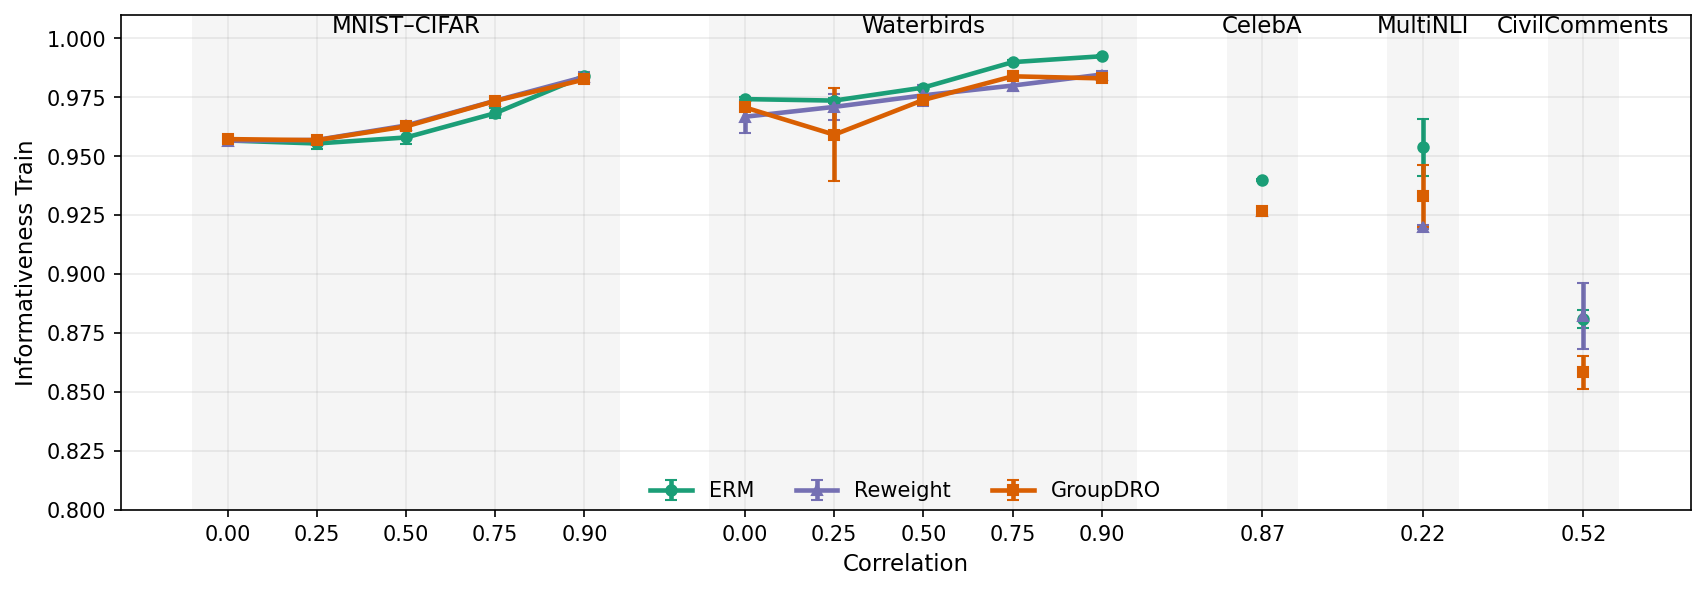

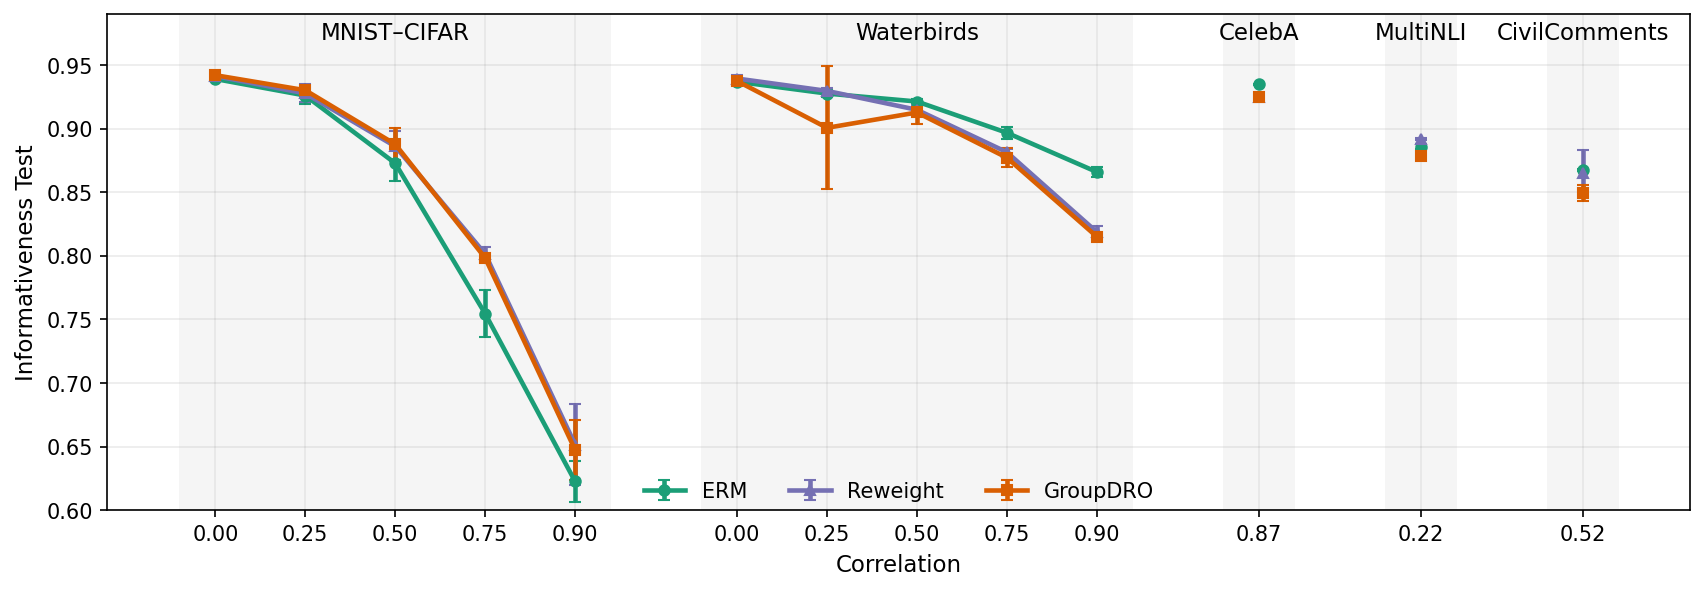

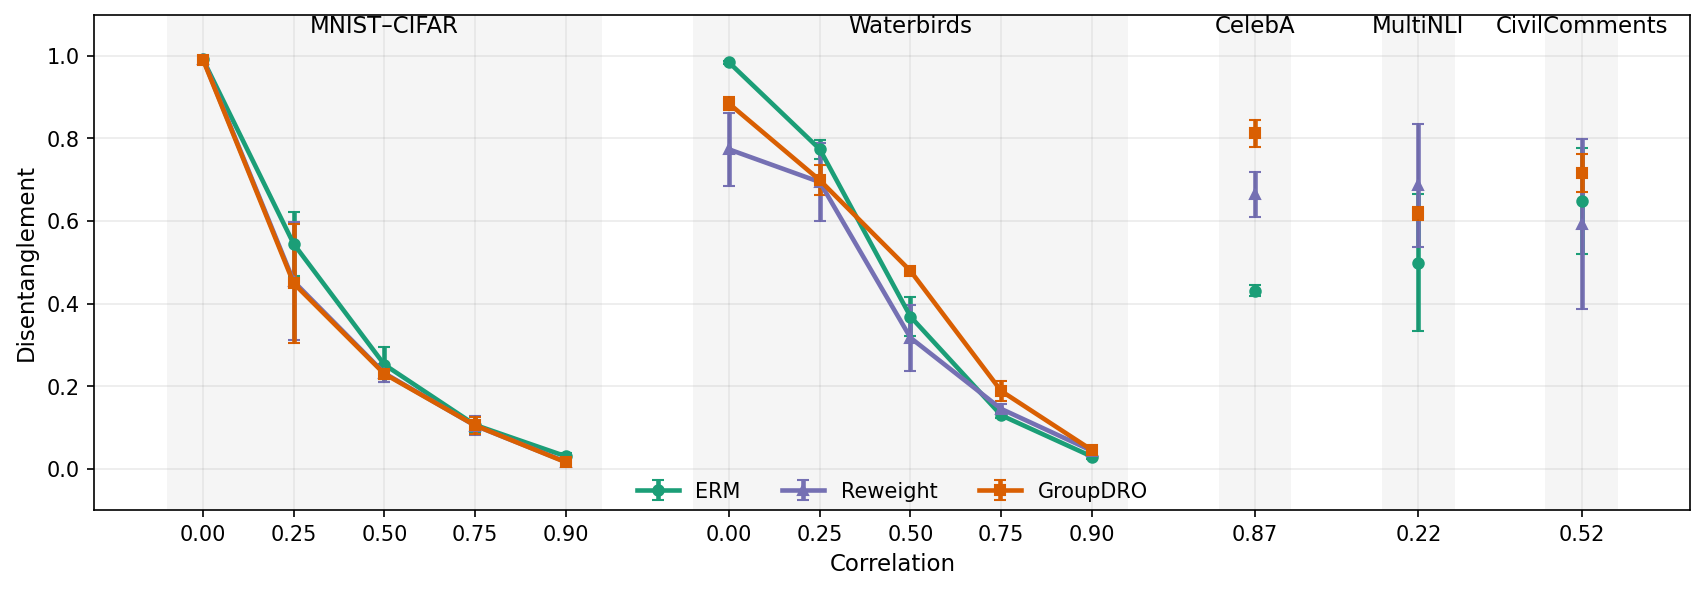

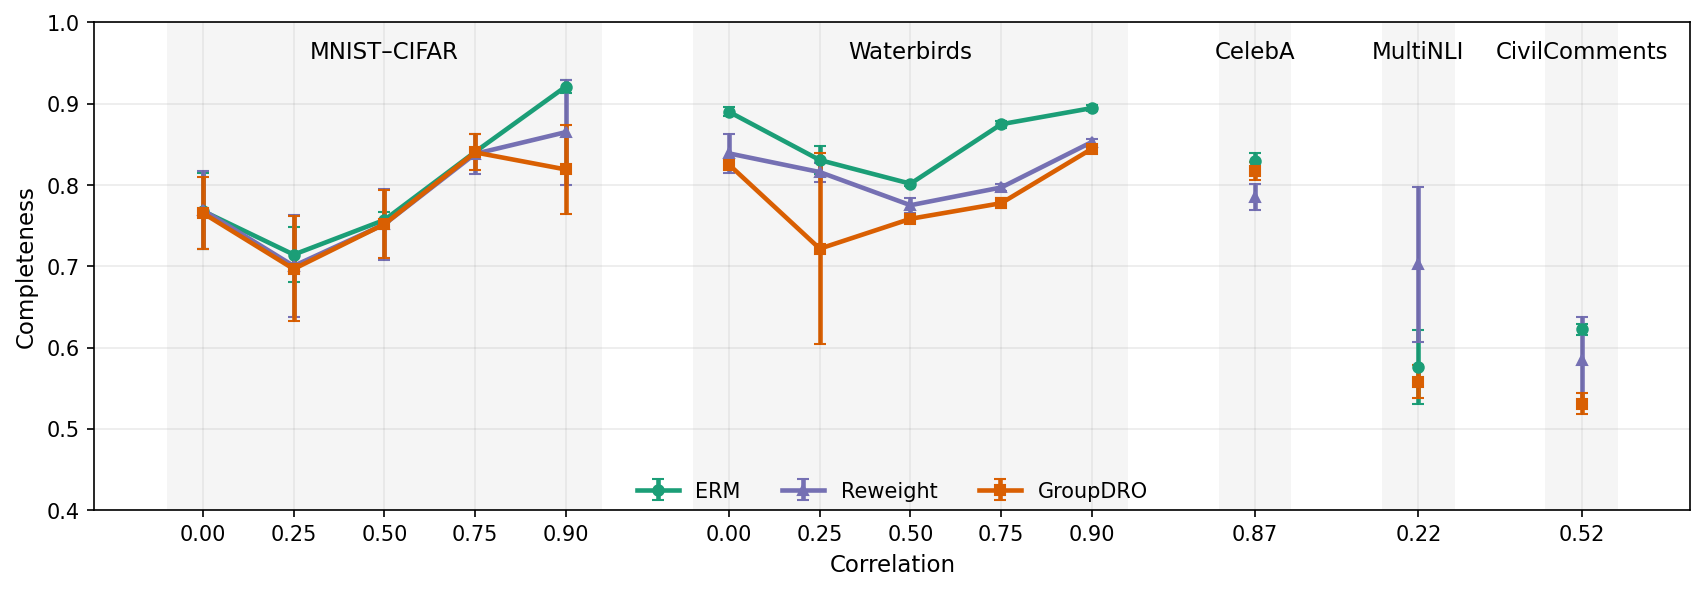

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Cargar y preparar ===
csv_path = "pca_dci_summary_1.csv"   # ajusta si usaste otro nombre
df = pd.read_csv(csv_path)

# Relleno por defecto para corr faltante (solo CelebA suele venir NaN)
default_corr = {"CelebA": 0.9}
df["corr_plot"] = df.apply(
    lambda r: default_corr.get(r["dataset"], r["corr"]) if pd.isna(r["corr"]) else r["corr"],
    axis=1
).astype(float)

corr_overrides = {
    # 1) Valor fijo para todo el dataset:
    "CelebA": 0.87,              # fuerza TODAS las filas de CelebA a 0.87

    # 2) Mapping (solo cambia ciertos valores originales):
    #    ejemplo: en MultiNLI, si corr era 0.10 -> 0.12; si 0.30 -> 0.28; el resto queda igual
    "MultiNLI": 0.22,

    # 3) Función por fila (usa r del DataFrame: r["corr"], r["split"], r["method"], etc.)
    #    ejemplo: en CivilComments, si method es 'gdro' pon 0.35, si no 0.32
    "civilcomments": 0.52,
}

def _apply_corr_overrides(df, corr_col="corr_plot"):
    df = df.copy()
    for ds, rule in corr_overrides.items():
        m = (df["dataset"] == ds)
        if not m.any():
            continue
        if callable(rule):
            df.loc[m, corr_col] = df.loc[m].apply(rule, axis=1).astype(float)
        elif isinstance(rule, dict):
            df.loc[m, corr_col] = df.loc[m, corr_col].map(lambda c: rule.get(float(c), float(c))).astype(float)
        else:
            df.loc[m, corr_col] = float(rule)
    return df

df = _apply_corr_overrides(df, corr_col="corr_plot")

# Promedio y std por semilla
group_cols = ["dataset", "corr_plot", "method"]
metrics = ["disentanglement", "completeness", "informativeness_train", "informativeness_test"]
agg_mean = df.groupby(group_cols)[metrics].mean().reset_index()
agg_std  = df.groupby(group_cols)[metrics].std(ddof=1).reset_index().rename(
    columns={m: f"{m}_std" for m in metrics}
)



agg = pd.merge(agg_mean, agg_std, on=group_cols, how="left").fillna(0.0)

# === Orden del eje X (datasets en secciones con gaps) ===
preferred_order = ["MNISTCIFAR", "CUB", "CelebA", "MultiNLI", "civilcomments"]
dataset_order = [ds for ds in preferred_order if ds in agg["dataset"].unique()]

# correlaciones presentes por dataset
corr_order = {ds: sorted(agg.loc[agg["dataset"] == ds, "corr_plot"].unique().tolist())
              for ds in dataset_order}
if "CelebA" in dataset_order and len(corr_order.get("CelebA", [])) == 0:
    corr_order["CelebA"] = [0.9]

# Construcción de posiciones X con gaps entre datasets
gap = 0.8  # espacio visual entre datasets
x_pos, x_ticks, x_ticklabs, sections = {}, [], [], []
x = 0.0
for ds in dataset_order:
    corrs = corr_order[ds]
    if not corrs:
        continue
    x0 = x
    for c in corrs:
        x_pos[(ds, float(c))] = x
        x_ticks.append(x)
        x_ticklabs.append(f"{c:.2f}")
        x += 1.0
    x1 = x - 1.0
    sections.append((x0-0.4, x1+0.4, ds))
    x += gap

# Métodos (mantén orden consistente en la leyenda)
methods = [m for m in ["erm","rw_erm","gdro"] if m in agg["method"].unique()]
colors  = {"erm":"#1b9e77","gdro":"#d95f02","rw_erm":"#7570b3"}
markers = {"erm":"o","gdro":"s","rw_erm":"^"}

plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "legend.fontsize": 10, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "lines.linewidth": 2.2, "figure.dpi": 150,
})

def plot_grouped_single_panel(
    agg, metric, annotate=False, ylim=None, outfile=None, title=None,
    connect_within_dataset=True,
    show_errorbars=True,
    markersize=5,
    dataset_label_map=None,   # ← NUEVO
    method_label_map=None     # ← NUEVO
):
    dataset_label_map = dataset_label_map or {}
    method_label_map  = method_label_map  or {}

    metric_std = f"{metric}_std"
    fig, ax = plt.subplots(figsize=(max(10, 0.5*len(x_ticks)+len(sections)), 4.2))

    # bandas de fondo por dataset
    for x0, x1, ds in sections:
        ax.axvspan(x0, x1, color="#000000", alpha=0.04, lw=0)

    # líneas por método, separadas por dataset
    for m in methods:
        first_label = True
        for ds in dataset_order:
            xs, ys, es = [], [], []
            sub = agg[(agg["method"] == m) & (agg["dataset"] == ds)]
            for c in corr_order[ds]:
                key = (ds, float(c))
                if key not in x_pos:
                    continue
                row = sub[sub["corr_plot"] == float(c)]
                if row.empty:
                    continue
                xs.append(x_pos[key])
                ys.append(float(row[metric].iloc[0]))
                if show_errorbars and metric_std in row.columns:
                    es.append(float(row[metric_std].iloc[0]))
                else:
                    es.append(0.0)

            if xs:
                fmt = markers.get(m, "o")
                if connect_within_dataset:
                    fmt += "-"
                label_to_show = method_label_map.get(m, m) if first_label else None
                kwargs = dict(fmt=fmt, markersize=markersize,
                              color=colors.get(m, None),
                              label=label_to_show)
                if show_errorbars:
                    kwargs.update(yerr=es, capsize=3)
                ax.errorbar(xs, ys, **kwargs)

                if annotate:
                    for xi, yi in zip(xs, ys):
                        ax.text(xi, yi + 0.003, f"{yi:.3f}",
                                ha="center", va="bottom", fontsize=9)
                first_label = False

    # ejes y decoración
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_ticklabs, rotation=0)
    ax.set_xlabel("Correlation")
    ax.set_ylabel(metric.replace("_", " ").title())
    if title:
        ax.set_title(title)

    # etiquetas de dataset (usa mapping si viene)
    top = ax.get_ylim()[1]
    for x0, x1, ds in sections:
        ds_disp = dataset_label_map.get(ds, ds)
        ax.text((x0+x1)/2, top, ds_disp, ha="center", va="bottom", fontsize=11)

    ax.grid(True, axis="y", alpha=0.25, lw=0.8)
    for xt in x_ticks:
        ax.axvline(xt, color="#000000", alpha=0.06, lw=0.8)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.legend(loc="lower center", ncol=len(methods), frameon=False, bbox_to_anchor=(0.5,-0.02))
    plt.tight_layout(rect=(0,0.03,1,1))
    if outfile:
        plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()


dataset_label_map = {
    "MNISTCIFAR": "MNIST–CIFAR",
    "CUB": "Waterbirds",
    "CelebA": "CelebA",
    "MultiNLI": "MultiNLI",
    "civilcomments": "CivilComments"
}
method_label_map = {
    "erm": "ERM",
    "gdro": "GroupDRO",
    "rw_erm": "Reweight"
}


# === Ejemplos de uso (ajusta títulos/ylim a gusto) ===
plot_grouped_single_panel(
    agg, metric="informativeness_train", annotate=False,
    ylim=(0.80, 1.01),
    title=None,
    outfile="inform_train_grouped.png",
    show_errorbars=True,    
    dataset_label_map=dataset_label_map,
    method_label_map=method_label_map
)
plot_grouped_single_panel(
    agg, metric="informativeness_test", annotate=False,
    ylim=(0.6, 0.99),
    title=None,
    outfile="inform_test_grouped.png",
    show_errorbars=True,
    dataset_label_map=dataset_label_map,
    method_label_map=method_label_map
)
plot_grouped_single_panel(
    agg, metric="disentanglement", annotate=False,
    ylim=(-0.1, 1.1),
    title=None,
    outfile="disentanglement_grouped.png",
    show_errorbars=True,
    dataset_label_map=dataset_label_map,
    method_label_map=method_label_map
)
plot_grouped_single_panel(
    agg, metric="completeness", annotate=False,
    ylim=(0.4, 1.0),
    title=None,
    outfile="completeness_grouped.png",
    show_errorbars=True,
    dataset_label_map=dataset_label_map,
    method_label_map=method_label_map
)


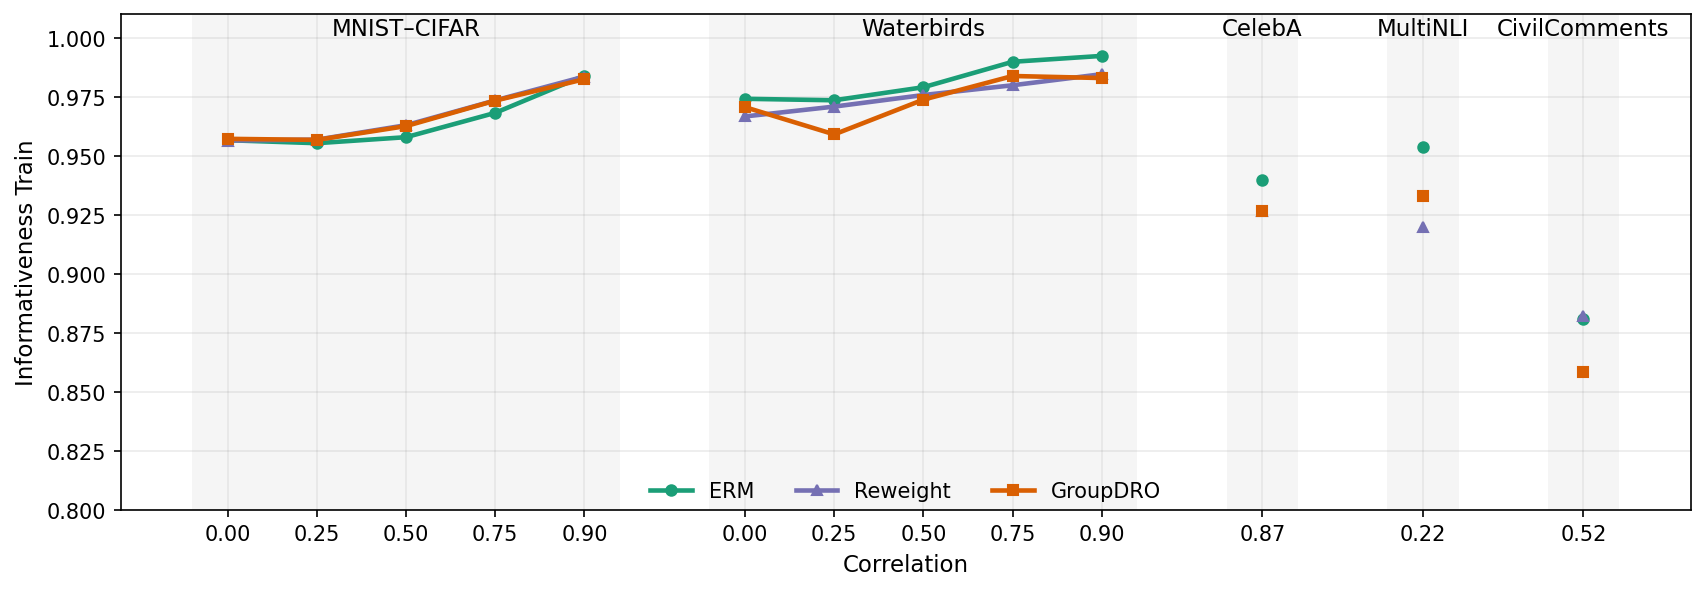

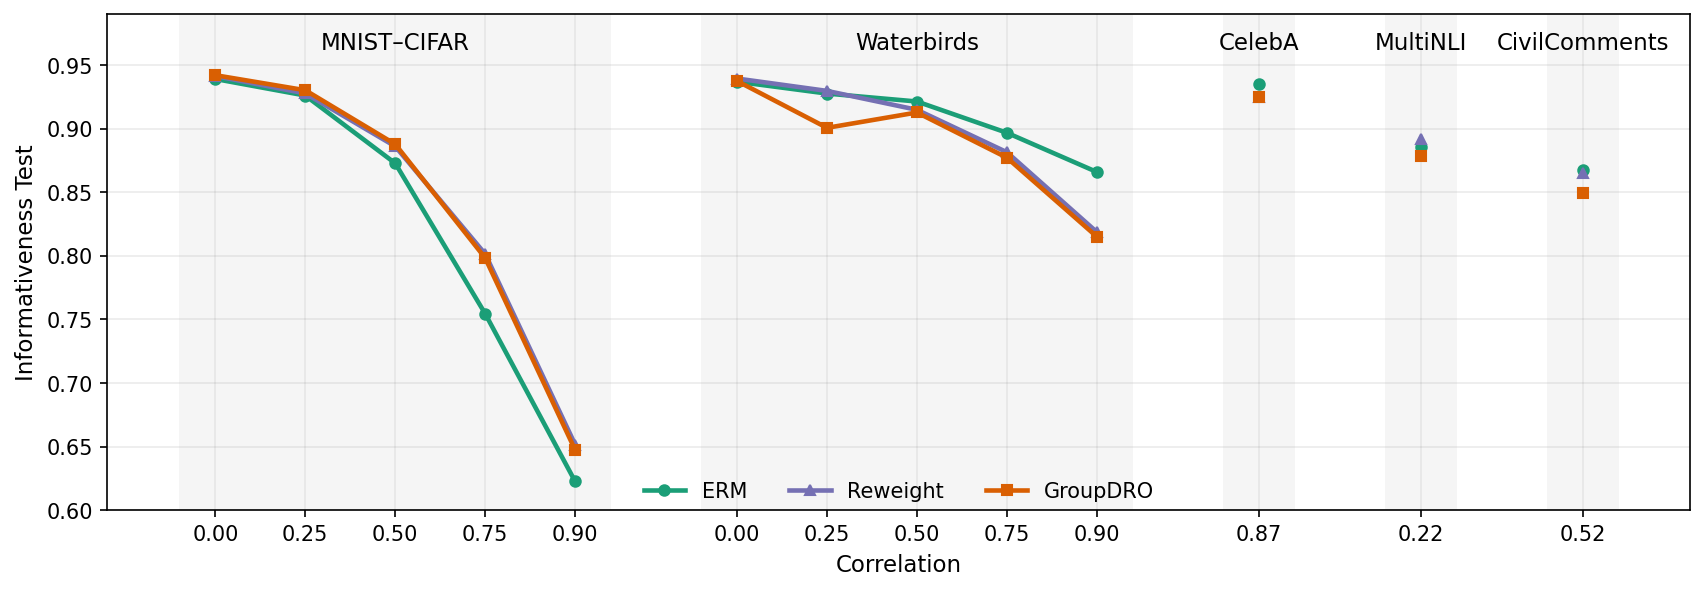

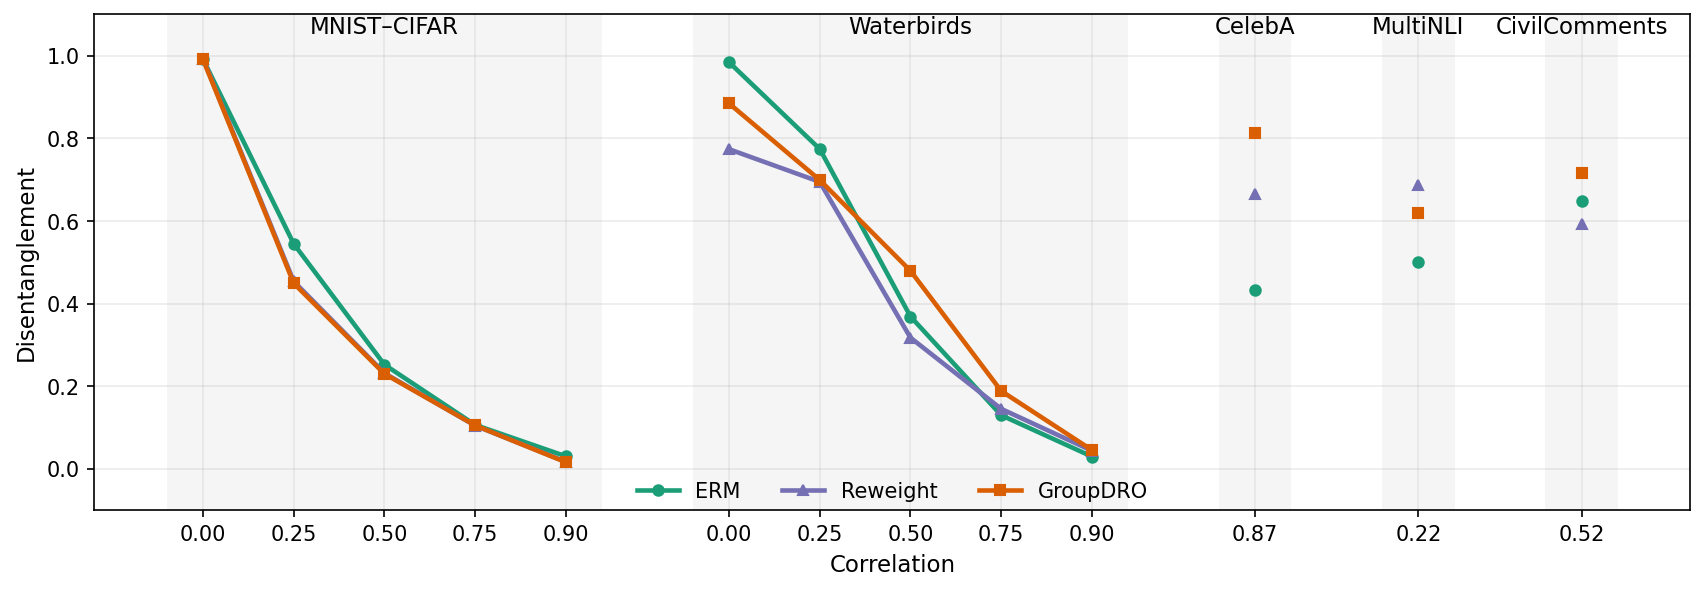

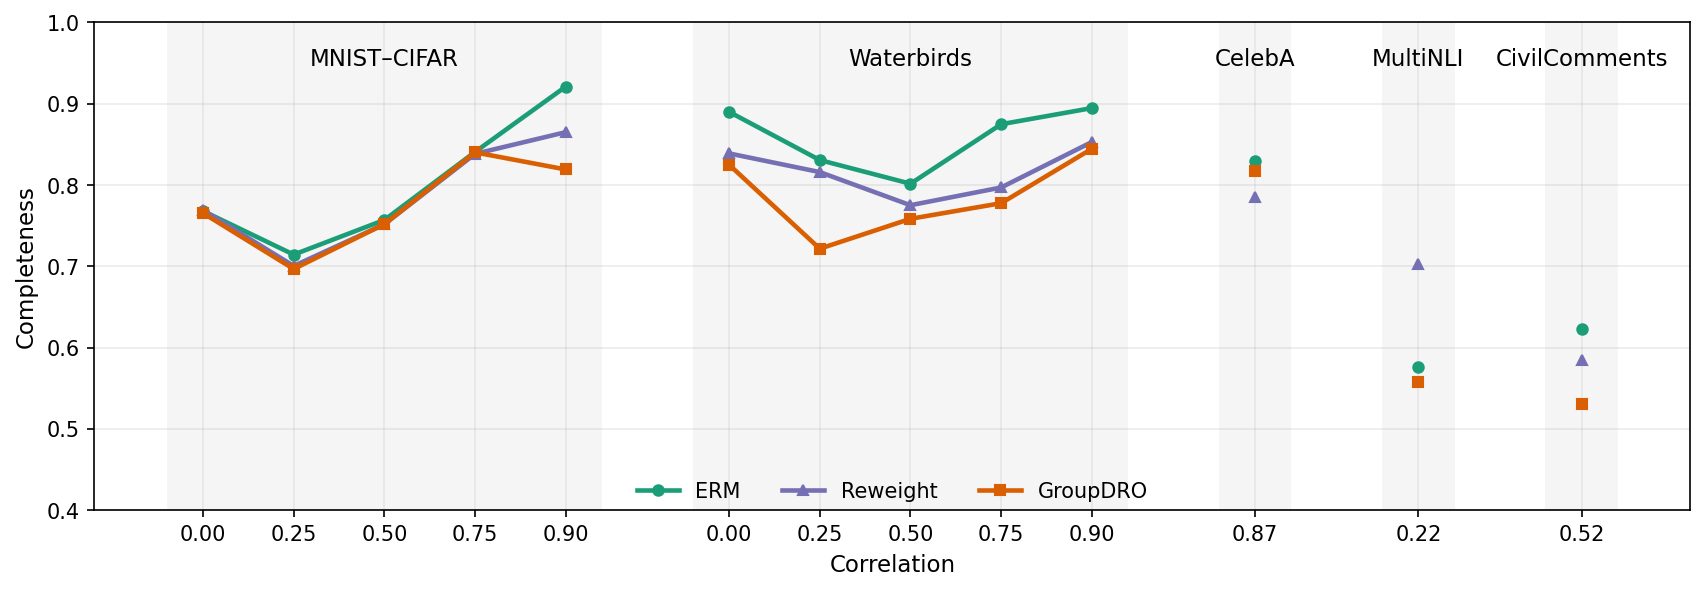

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Cargar y preparar ===
csv_path = "pca_dci_summary_1.csv"   # ajusta si usaste otro nombre
df = pd.read_csv(csv_path)

# Relleno por defecto para corr faltante (solo CelebA suele venir NaN)
default_corr = {"CelebA": 0.9}
df["corr_plot"] = df.apply(
    lambda r: default_corr.get(r["dataset"], r["corr"]) if pd.isna(r["corr"]) else r["corr"],
    axis=1
).astype(float)

corr_overrides = {
    # 1) Valor fijo para todo el dataset:
    "CelebA": 0.87,              # fuerza TODAS las filas de CelebA a 0.87

    # 2) Mapping (solo cambia ciertos valores originales):
    #    ejemplo: en MultiNLI, si corr era 0.10 -> 0.12; si 0.30 -> 0.28; el resto queda igual
    "MultiNLI": 0.22,

    # 3) Función por fila (usa r del DataFrame: r["corr"], r["split"], r["method"], etc.)
    #    ejemplo: en CivilComments, si method es 'gdro' pon 0.35, si no 0.32
    "civilcomments": 0.52,
}

def _apply_corr_overrides(df, corr_col="corr_plot"):
    df = df.copy()
    for ds, rule in corr_overrides.items():
        m = (df["dataset"] == ds)
        if not m.any():
            continue
        if callable(rule):
            df.loc[m, corr_col] = df.loc[m].apply(rule, axis=1).astype(float)
        elif isinstance(rule, dict):
            df.loc[m, corr_col] = df.loc[m, corr_col].map(lambda c: rule.get(float(c), float(c))).astype(float)
        else:
            df.loc[m, corr_col] = float(rule)
    return df

df = _apply_corr_overrides(df, corr_col="corr_plot")

# Promedio y std por semilla
group_cols = ["dataset", "corr_plot", "method"]
metrics = ["disentanglement", "completeness", "informativeness_train", "informativeness_test"]
agg_mean = df.groupby(group_cols)[metrics].mean().reset_index()
agg_std  = df.groupby(group_cols)[metrics].std(ddof=1).reset_index().rename(
    columns={m: f"{m}_std" for m in metrics}
)



agg = pd.merge(agg_mean, agg_std, on=group_cols, how="left").fillna(0.0)

# === Orden del eje X (datasets en secciones con gaps) ===
preferred_order = ["MNISTCIFAR", "CUB", "CelebA", "MultiNLI", "civilcomments"]
dataset_order = [ds for ds in preferred_order if ds in agg["dataset"].unique()]

# correlaciones presentes por dataset
corr_order = {ds: sorted(agg.loc[agg["dataset"] == ds, "corr_plot"].unique().tolist())
              for ds in dataset_order}
if "CelebA" in dataset_order and len(corr_order.get("CelebA", [])) == 0:
    corr_order["CelebA"] = [0.9]

# Construcción de posiciones X con gaps entre datasets
gap = 0.8  # espacio visual entre datasets
x_pos, x_ticks, x_ticklabs, sections = {}, [], [], []
x = 0.0
for ds in dataset_order:
    corrs = corr_order[ds]
    if not corrs:
        continue
    x0 = x
    for c in corrs:
        x_pos[(ds, float(c))] = x
        x_ticks.append(x)
        x_ticklabs.append(f"{c:.2f}")
        x += 1.0
    x1 = x - 1.0
    sections.append((x0-0.4, x1+0.4, ds))
    x += gap

# Métodos (mantén orden consistente en la leyenda)
methods = [m for m in ["erm","rw_erm","gdro"] if m in agg["method"].unique()]
colors  = {"erm":"#1b9e77","gdro":"#d95f02","rw_erm":"#7570b3"}
markers = {"erm":"o","gdro":"s","rw_erm":"^"}

plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "legend.fontsize": 10, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "lines.linewidth": 2.2, "figure.dpi": 150,
})

def plot_grouped_single_panel(
    agg, metric, annotate=False, ylim=None, outfile=None, title=None,
    connect_within_dataset=True,
    show_errorbars=True,
    markersize=5,
    dataset_label_map=None,   # ← NUEVO
    method_label_map=None     # ← NUEVO
):
    dataset_label_map = dataset_label_map or {}
    method_label_map  = method_label_map  or {}

    metric_std = f"{metric}_std"
    fig, ax = plt.subplots(figsize=(max(10, 0.5*len(x_ticks)+len(sections)), 4.2))

    # bandas de fondo por dataset
    for x0, x1, ds in sections:
        ax.axvspan(x0, x1, color="#000000", alpha=0.04, lw=0)

    # líneas por método, separadas por dataset
    for m in methods:
        first_label = True
        for ds in dataset_order:
            xs, ys, es = [], [], []
            sub = agg[(agg["method"] == m) & (agg["dataset"] == ds)]
            for c in corr_order[ds]:
                key = (ds, float(c))
                if key not in x_pos:
                    continue
                row = sub[sub["corr_plot"] == float(c)]
                if row.empty:
                    continue
                xs.append(x_pos[key])
                ys.append(float(row[metric].iloc[0]))
                if show_errorbars and metric_std in row.columns:
                    es.append(float(row[metric_std].iloc[0]))
                else:
                    es.append(0.0)

            if xs:
                fmt = markers.get(m, "o")
                if connect_within_dataset:
                    fmt += "-"
                label_to_show = method_label_map.get(m, m) if first_label else None
                kwargs = dict(fmt=fmt, markersize=markersize,
                              color=colors.get(m, None),
                              label=label_to_show)
                if show_errorbars:
                    kwargs.update(yerr=es, capsize=3)
                ax.errorbar(xs, ys, **kwargs)

                if annotate:
                    for xi, yi in zip(xs, ys):
                        ax.text(xi, yi + 0.003, f"{yi:.3f}",
                                ha="center", va="bottom", fontsize=9)
                first_label = False

    # ejes y decoración
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_ticklabs, rotation=0)
    ax.set_xlabel("Correlation")
    ax.set_ylabel(metric.replace("_", " ").title())
    if title:
        ax.set_title(title)

    # etiquetas de dataset (usa mapping si viene)
    top = ax.get_ylim()[1]
    for x0, x1, ds in sections:
        ds_disp = dataset_label_map.get(ds, ds)
        ax.text((x0+x1)/2, top, ds_disp, ha="center", va="bottom", fontsize=11)

    ax.grid(True, axis="y", alpha=0.25, lw=0.8)
    for xt in x_ticks:
        ax.axvline(xt, color="#000000", alpha=0.06, lw=0.8)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.legend(loc="lower center", ncol=len(methods), frameon=False, bbox_to_anchor=(0.5,-0.02))
    plt.tight_layout(rect=(0,0.03,1,1))
    if outfile:
        plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()


dataset_label_map = {
    "MNISTCIFAR": "MNIST–CIFAR",
    "CUB": "Waterbirds",
    "CelebA": "CelebA",
    "MultiNLI": "MultiNLI",
    "civilcomments": "CivilComments"
}
method_label_map = {
    "erm": "ERM",
    "gdro": "GroupDRO",
    "rw_erm": "Reweight"
}


# === Ejemplos de uso (ajusta títulos/ylim a gusto) ===
plot_grouped_single_panel(
    agg, metric="informativeness_train", annotate=False,
    ylim=(0.80, 1.01),
    title=None,
    outfile="inform_train_grouped.png",
    show_errorbars=False,    
    dataset_label_map=dataset_label_map,
    method_label_map=method_label_map
)
plot_grouped_single_panel(
    agg, metric="informativeness_test", annotate=False,
    ylim=(0.6, 0.99),
    title=None,
    outfile="inform_test_grouped.png",
    show_errorbars=False,
    dataset_label_map=dataset_label_map,
    method_label_map=method_label_map
)
plot_grouped_single_panel(
    agg, metric="disentanglement", annotate=False,
    ylim=(-0.1, 1.1),
    title=None,
    outfile="disentanglement_grouped.png",
    show_errorbars=False,
    dataset_label_map=dataset_label_map,
    method_label_map=method_label_map
)
plot_grouped_single_panel(
    agg, metric="completeness", annotate=False,
    ylim=(0.4, 1.0),
    title=None,
    outfile="completeness_grouped.png",
    show_errorbars=False,
    dataset_label_map=dataset_label_map,
    method_label_map=method_label_map
)

In [9]:
def make_latex_table(
    agg: pd.DataFrame,
    inform_split: str = "test",            # "train" o "test"
    dataset_order: list | None = None,     
    method_order: list | None = None,      
    method_names: dict | None = None,      
    dataset_names: dict | None = None,     
    decimals_mean: int = 3,
    decimals_std: int = 2,
    show_std: bool = True,                 # <-- NUEVO
    caption: str | None = None,
    label: str | None = None,
) -> str:
    """
    Genera una tabla LaTeX con columnas agrupadas por métrica y celdas formateadas como
    'mean (\\scriptsize std)' si show_std=True, o solo 'mean' si show_std=False.
    """
    assert inform_split in {"train", "test"}

    if dataset_order is None:
        preferred = ["MNISTCIFAR", "CUB", "CelebA", "MultiNLI", "civilcomments"]
        present = [ds for ds in preferred if ds in agg["dataset"].unique()]
        rest = [ds for ds in agg["dataset"].unique() if ds not in present]
        dataset_order = present + rest

    if method_order is None:
        method_order = [m for m in ["erm", "gdro", "rw_erm"] if m in agg["method"].unique()]
        extras = [m for m in agg["method"].unique() if m not in method_order]
        method_order += list(extras)

    if method_names is None:
        method_names = {"erm":"ERM","gdro":"GroupDRO","rw_erm":"Reweight"}

    if dataset_names is None:
        dataset_names = {
            "MNISTCIFAR": "MNIST--CIFAR",
            "CUB": "Waterbirds",
            "CelebA": "CelebA",
            "MultiNLI": "MultiNLI",
            "civilcomments": "CivilComments",
        }

    metrics = {
        "Disentanglement": "disentanglement",
        "Completeness": "completeness",
        "Informativeness": f"informativeness_{inform_split}",
    }
    metric_keys = list(metrics.keys())

    corr_by_ds = {
        ds: sorted(agg.loc[agg["dataset"] == ds, "corr_plot"].dropna().unique().tolist())
        for ds in dataset_order
    }

    def fmt_cell(mean, std):
        if pd.isna(mean):
            return "--"
        if show_std and not pd.isna(std):
            return f"{mean:.{decimals_mean}f} {{\\scriptsize ({std:.{decimals_std}f})}}"
        else:
            return f"{mean:.{decimals_mean}f}"

    def fetch(DS, C, M, col):
        row = agg[(agg["dataset"] == DS) &
                  (agg["corr_plot"] == float(C)) &
                  (agg["method"] == M)]
        if row.empty:
            return np.nan, np.nan
        mean = float(row[col].iloc[0])
        std_col = f"{col}_std"
        std = float(row[std_col].iloc[0]) if std_col in row.columns else np.nan
        return mean, std

    left_cols = ["l", "c"]
    right_cols = ["c"] * (len(metrics) * len(method_order))
    colspec = "".join(left_cols + right_cols)

    header_top = ["Dataset", "Corr"]
    for mk in metric_keys:
        header_top.append(f"\\multicolumn{{{len(method_order)}}}{{c}}{{{mk}}}")
    header_top_line = " & ".join(header_top) + " \\\\"

    header_mid = ["", ""]
    for _mk in metric_keys:
        header_mid += [method_names.get(m, m) for m in method_order]
    header_mid_line = " & ".join(header_mid) + " \\\\"

    lines = []
    lines.append("\\begin{table}[t]")
    lines.append("\\centering")
    lines.append("\\small")
    lines.append(f"\\begin{{tabular}}{{{colspec}}}")
    lines.append("\\toprule")
    lines.append(header_top_line)
    lines.append("\\cmidrule(lr){3-" + f"{2+len(method_order)}" + "}" +
                 "".join([
                    f"\\cmidrule(lr){{{3 + i*len(method_order)}-{2 + (i+1)*len(method_order)}}}"
                    for i in range(1, len(metric_keys))
                 ]))
    lines.append(header_mid_line)
    lines.append("\\midrule")

    for ds in dataset_order:
        corrs = corr_by_ds.get(ds, [])
        if not corrs:
            continue
        pretty_ds = dataset_names.get(ds, ds)
        nrows = len(corrs)

        for r_idx, c in enumerate(corrs):
            row_cells = []
            if r_idx == 0:
                row_cells.append(f"\\multirow{{{nrows}}}{{*}}{{{pretty_ds}}}")
            else:
                row_cells.append("")
            row_cells.append(f"{c:.2f}")
            for mk, col in metrics.items():
                for m in method_order:
                    mean, std = fetch(ds, c, m, col)
                    row_cells.append(fmt_cell(mean, std))
            lines.append(" & ".join(row_cells) + " \\\\")
        lines.append("\\midrule")

    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")
    cap = caption or (
        f"Disentanglement, completeness e informativeness ({inform_split}) "
        + ("con media y \\scriptsize desviación estándar." if show_std else "con valores de media.")
    )
    lines.append(f"\\caption{{{cap}}}")
    if label:
        lines.append(f"\\label{{{label}}}")
    lines.append("\\end{table}")

    return "\n".join(lines)


In [10]:
latex = make_latex_table(
    agg,
    inform_split="train",                  # o "train"
    dataset_order=["MNISTCIFAR","CUB","CelebA","MultiNLI","civilcomments"],
    method_order=["erm","gdro","rw_erm"],
    method_names={"erm":"ERM","gdro":"GDRO","rw_erm":"RW"},
    dataset_names={"MNISTCIFAR":"MNIST--CIFAR","CUB":"Waterbirds",
                   "CelebA":"CelebA","MultiNLI":"MultiNLI",
                   "civilcomments":"CivilComments"},
    caption="Resultados DCI (media y std).",
    show_std=False,
    label="tab:dci"
)
print(latex)

\begin{table}[t]
\centering
\small
\begin{tabular}{lcccccccccc}
\toprule
Dataset & Corr & \multicolumn{3}{c}{Disentanglement} & \multicolumn{3}{c}{Completeness} & \multicolumn{3}{c}{Informativeness} \\
\cmidrule(lr){3-5}\cmidrule(lr){6-8}\cmidrule(lr){9-11}
 &  & ERM & GDRO & RW & ERM & GDRO & RW & ERM & GDRO & RW \\
\midrule
\multirow{5}{*}{MNIST--CIFAR} & 0.00 & 0.992 & 0.991 & 0.993 & 0.768 & 0.765 & 0.769 & 0.957 & 0.957 & 0.957 \\
 & 0.25 & 0.545 & 0.449 & 0.454 & 0.714 & 0.697 & 0.700 & 0.955 & 0.957 & 0.957 \\
 & 0.50 & 0.252 & 0.230 & 0.231 & 0.757 & 0.752 & 0.752 & 0.958 & 0.963 & 0.963 \\
 & 0.75 & 0.106 & 0.105 & 0.105 & 0.841 & 0.840 & 0.838 & 0.968 & 0.973 & 0.974 \\
 & 0.90 & 0.030 & 0.016 & 0.017 & 0.921 & 0.819 & 0.865 & 0.984 & 0.983 & 0.984 \\
\midrule
\multirow{5}{*}{Waterbirds} & 0.00 & 0.984 & 0.884 & 0.774 & 0.890 & 0.825 & 0.839 & 0.974 & 0.971 & 0.967 \\
 & 0.25 & 0.774 & 0.699 & 0.695 & 0.831 & 0.722 & 0.816 & 0.974 & 0.959 & 0.971 \\
 & 0.50 & 0.369 & 0.479 & 

In [12]:
latex = make_latex_table(
    agg,
    inform_split="test",                  # o "train"
    dataset_order=["MNISTCIFAR","CUB","CelebA","MultiNLI","civilcomments"],
    method_order=["erm","gdro","rw_erm"],
    method_names={"erm":"ERM","gdro":"GDRO","rw_erm":"RW"},
    dataset_names={"MNISTCIFAR":"MNIST--CIFAR","CUB":"Waterbirds",
                   "CelebA":"CelebA","MultiNLI":"MultiNLI",
                   "civilcomments":"CivilComments"},
    caption="Resultados DCI (media y std).",
    show_std=False,
    label="tab:dci"
)
print(latex)

\begin{table}[t]
\centering
\small
\begin{tabular}{lcccccccccc}
\toprule
Dataset & Corr & \multicolumn{3}{c}{Disentanglement} & \multicolumn{3}{c}{Completeness} & \multicolumn{3}{c}{Informativeness} \\
\cmidrule(lr){3-5}\cmidrule(lr){6-8}\cmidrule(lr){9-11}
 &  & ERM & GDRO & RW & ERM & GDRO & RW & ERM & GDRO & RW \\
\midrule
\multirow{5}{*}{MNIST--CIFAR} & 0.00 & 0.992 & 0.991 & 0.993 & 0.768 & 0.765 & 0.769 & 0.939 & 0.942 & 0.942 \\
 & 0.25 & 0.545 & 0.449 & 0.454 & 0.714 & 0.697 & 0.700 & 0.926 & 0.930 & 0.928 \\
 & 0.50 & 0.252 & 0.230 & 0.231 & 0.757 & 0.752 & 0.752 & 0.873 & 0.888 & 0.886 \\
 & 0.75 & 0.106 & 0.105 & 0.105 & 0.841 & 0.840 & 0.838 & 0.755 & 0.798 & 0.801 \\
 & 0.90 & 0.030 & 0.016 & 0.017 & 0.921 & 0.819 & 0.865 & 0.622 & 0.647 & 0.651 \\
\midrule
\multirow{5}{*}{Waterbirds} & 0.00 & 0.984 & 0.884 & 0.774 & 0.890 & 0.825 & 0.839 & 0.937 & 0.938 & 0.940 \\
 & 0.25 & 0.774 & 0.699 & 0.695 & 0.831 & 0.722 & 0.816 & 0.928 & 0.901 & 0.930 \\
 & 0.50 & 0.369 & 0.479 & 

## Predictiveness of Spurious Features

Datasets:   0%|          | 0/5 [00:00<?, ?it/s]

Correlations:   0%|          | 0/5 [00:00<?, ?it/s]

Methods:   0%|          | 0/3 [00:00<?, ?it/s]

Seeds:   0%|          | 0/3 [00:00<?, ?it/s]

Seeds:   0%|          | 0/3 [00:00<?, ?it/s]

...

Methods:   0%|          | 0/3 [00:00<?, ?it/s]

Seeds:   0%|          | 0/3 [00:00<?, ?it/s]

Seeds:   0%|          | 0/3 [00:00<?, ?it/s]

Seeds:   0%|          | 0/3 [00:00<?, ?it/s]

[OK] guardado per-seed en pca_spurious_predictiveness_per_seed.csv


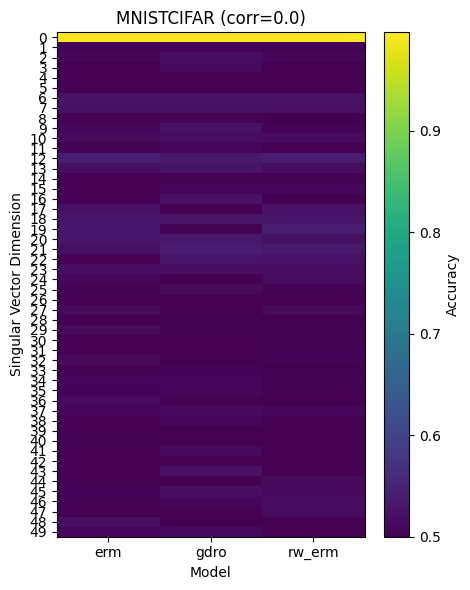

[OK] heatmap_spurious_MNISTCIFAR_0_0.png


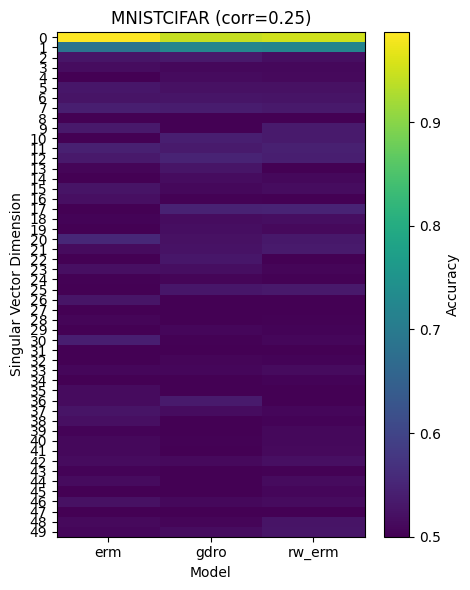

[OK] heatmap_spurious_MNISTCIFAR_0_25.png


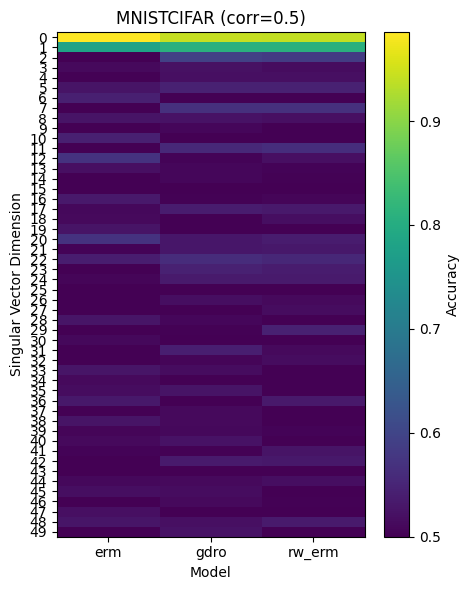

[OK] heatmap_spurious_MNISTCIFAR_0_5.png


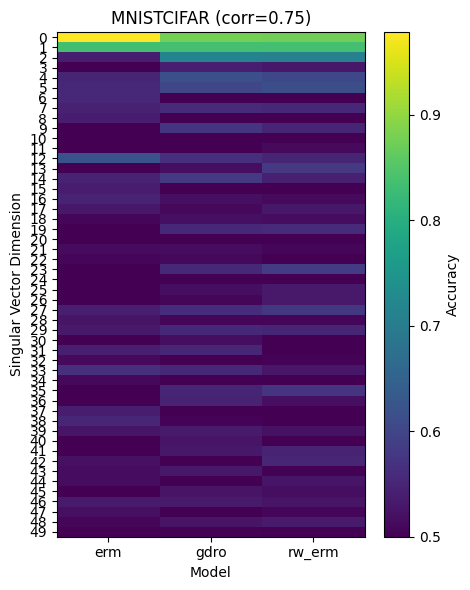

[OK] heatmap_spurious_MNISTCIFAR_0_75.png


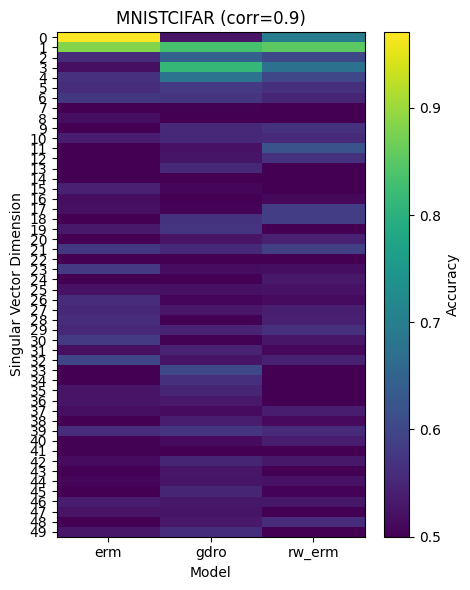

[OK] heatmap_spurious_MNISTCIFAR_0_9.png


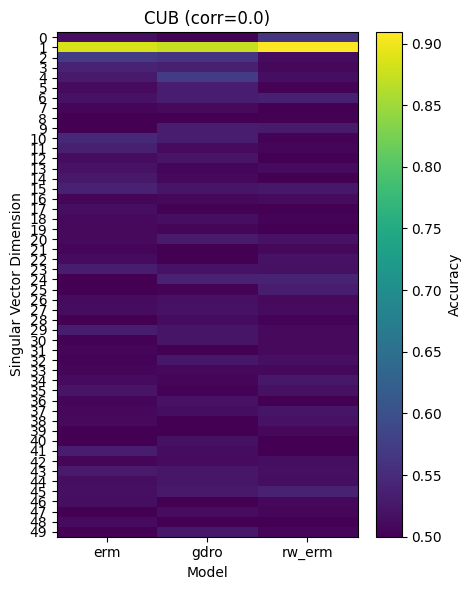

[OK] heatmap_spurious_CUB_0_0.png


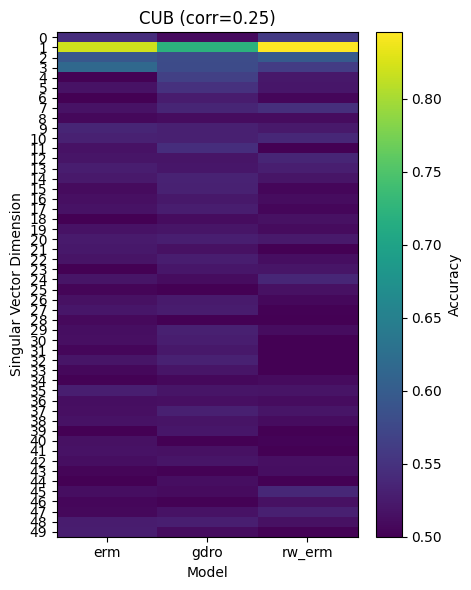

[OK] heatmap_spurious_CUB_0_25.png


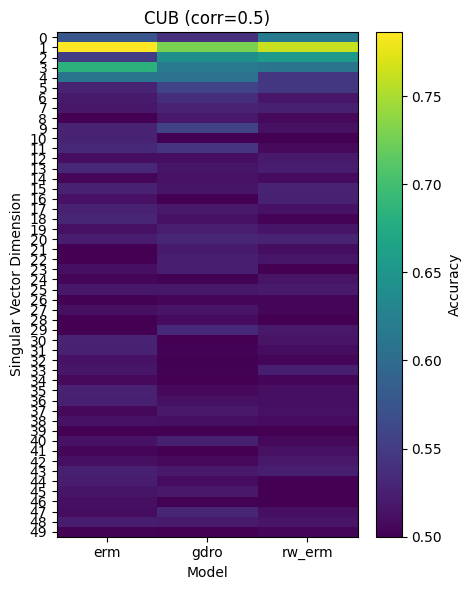

[OK] heatmap_spurious_CUB_0_5.png


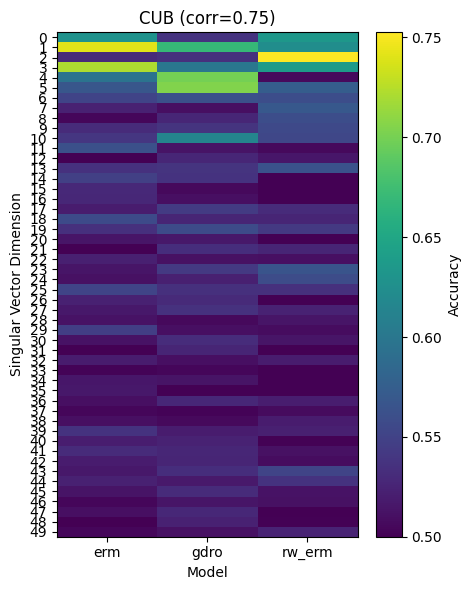

[OK] heatmap_spurious_CUB_0_75.png


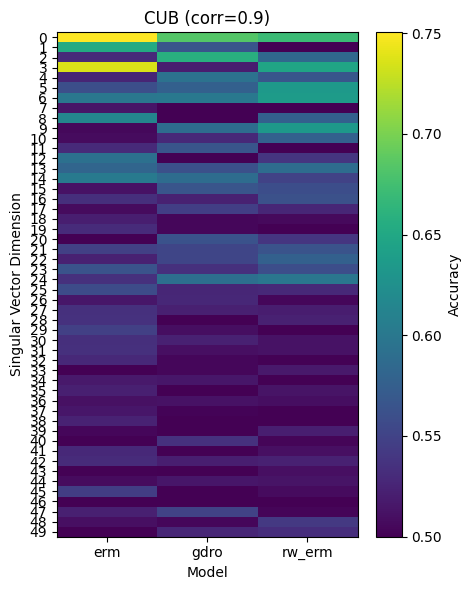

[OK] heatmap_spurious_CUB_0_9.png


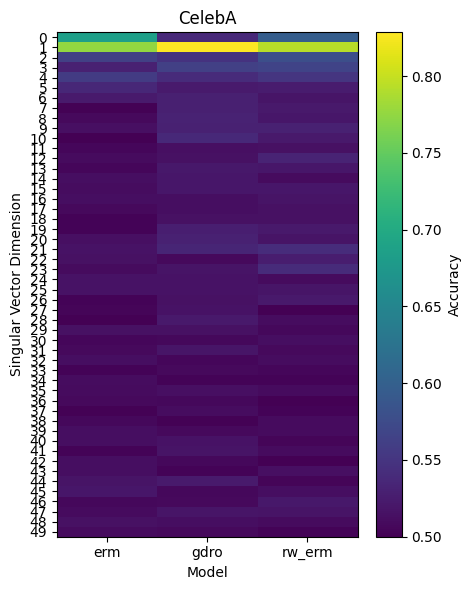

[OK] heatmap_spurious_CelebA_0.90.png


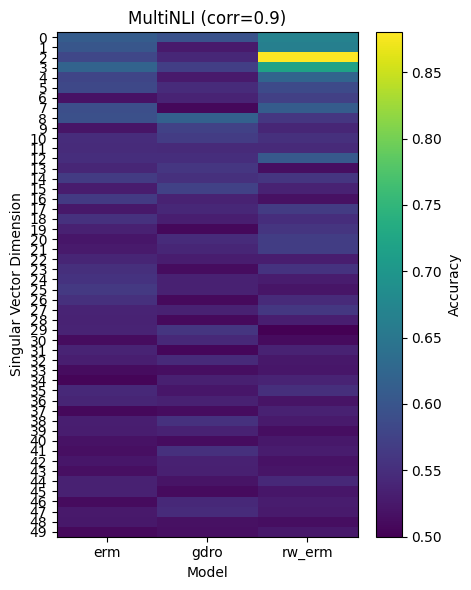

[OK] heatmap_spurious_MultiNLI_0_9.png


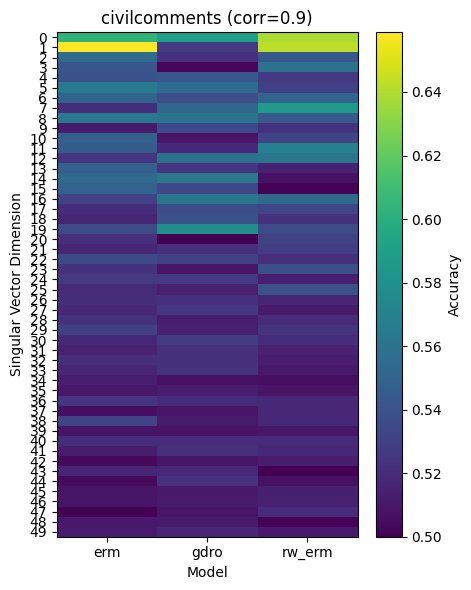

[OK] heatmap_spurious_civilcomments_0_9.png


In [31]:
# pca_spurious_predictiveness.py
import os
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from tqdm.notebook import tqdm
# ==== Config ====
PCA_ROOT = "pca_reps"
OUT_CSV  = "pca_spurious_predictiveness_per_seed.csv"
OUT_DIR  = "fig_pca_spurious_heatmaps"
os.makedirs(OUT_DIR, exist_ok=True)

DATASETS  = ["MNISTCIFAR","CUB","CelebA","MultiNLI","civilcomments"]
METHODS   = ["erm","gdro","rw_erm"]    # orden de columnas en el heatmap
SEEDS     = [111,222,333]
CORRS = {
    "MNISTCIFAR":[0.0,0.25,0.5,0.75,0.9],
    "CUB":[0.0,0.25,0.5,0.75,0.9],
    "CelebA":[0.9],
    "MultiNLI":[0.9],
    "civilcomments":[0.9],
}
MAX_ITERS = {
    "MNISTCIFAR":1000,
    "CUB": 1000,
    "CelebA":1000,
    "MultiNLI":10000,
    "civilcomments":10000,
}
CUB_MAP = {0.0:50, 0.25:625, 0.5:75, 0.75:875, 0.9:95, 1.0:100}

def _subdir_for(dataset, method, corr):
    if dataset=="CelebA":
        return f"{method}"
    if dataset=="CUB":
        return f"{method}_{CUB_MAP[corr]}"
    return f"{method}_{corr}"

def pca_paths(dataset, method, corr, seed):
    base = os.path.join(PCA_ROOT, dataset, _subdir_for(dataset, method, corr), f"seed_{seed}")
    return os.path.join(base, "train.pt"), os.path.join(base, "test.pt")

def load_split(path_pt):
    obj = torch.load(path_pt, map_location="cpu", weights_only=False)
    Z = obj["Z"].float().numpy()                # (N, k)
    y = obj["y"].long().view(-1).numpy()        # (N,) — no lo usamos aquí
    g = obj["g"].long().view(-1).numpy()        # (N,) — spurious (ya binario 0/1)
    return Z, y, g

def per_component_acc(Ztr, gtr, Zte, gte, max_iter=1000, class_weight="balanced", C=1.0):
    """Entrena una LR por componente: g ~ Z[:, d]. Devuelve (acc_train, acc_test) de shape (k,)."""
    k = Ztr.shape[1]
    acc_tr = np.full(k, np.nan, dtype=float)
    acc_te = np.full(k, np.nan, dtype=float)
    for d in range(k):
        xb_tr = Ztr[:, [d]]
        xb_te = Zte[:, [d]]
        # LR univariada
        clf = LogisticRegression(
            max_iter=max_iter,
            class_weight=class_weight,
            C=C,
            solver="liblinear",   # estable para 1D
            random_state=0
        )
        try:
            clf.fit(xb_tr, gtr)
            acc_tr[d] = clf.score(xb_tr, gtr)
            acc_te[d] = clf.score(xb_te, gte)
        except Exception:
            # por si hay varianza ~0, etc.
            acc_tr[d] = np.nan
            acc_te[d] = np.nan
    return acc_tr, acc_te

# --------- 1) Recorre y guarda per-seed ----------
rows = []
for ds in tqdm(DATASETS, desc="Datasets"):
    for corr in tqdm(CORRS[ds], desc="Correlations"):
        for m in tqdm(METHODS, desc="Methods"):
            for s in tqdm(SEEDS, desc="Seeds"):
                tr_pt, te_pt = pca_paths(ds, m, corr, s)
                if not os.path.exists(tr_pt) or not os.path.exists(te_pt):
                    print(f"[skip] faltan PCA: {tr_pt} o {te_pt}")
                    continue
                Ztr, ytr, gtr = load_split(tr_pt)
                Zte, yte, gte = load_split(te_pt)
                # Asegura mismo k
                k = min(Ztr.shape[1], Zte.shape[1])
                Ztr, Zte = Ztr[:, :k], Zte[:, :k]
                acc_tr, acc_te = per_component_acc(Ztr, gtr, Zte, gte,max_iter=MAX_ITERS[ds])
                for d in range(k):
                    rows.append({
                        "dataset": ds,
                        "corr": None if ds=="CelebA" else float(corr),
                        "method": m,
                        "seed": s,
                        "dim": d,
                        "k": k,
                        "acc_train": float(acc_tr[d]),
                        "acc_test": float(acc_te[d])
                    })

df = pd.DataFrame(rows)
if df.empty:
    raise RuntimeError("No se generaron resultados. ¿Existen pca_reps/<...>/{train,test}.pt?")
df.to_csv(OUT_CSV, index=False)
print(f"[OK] guardado per-seed en {OUT_CSV}")

# agregar (promedio por semilla)
agg = (df.groupby(["dataset","corr","method","dim"], dropna=False)
         .agg(acc_train_mean=("acc_train","mean"),
              acc_test_mean=("acc_test","mean"),
              n=("acc_test","count"))
         .reset_index())




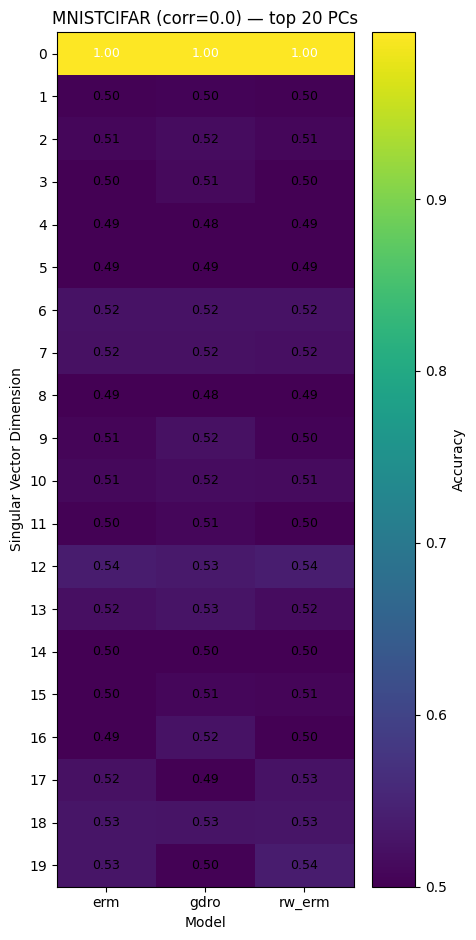

[OK] heatmap_spurious_MNISTCIFAR_0_0_K20_test.png


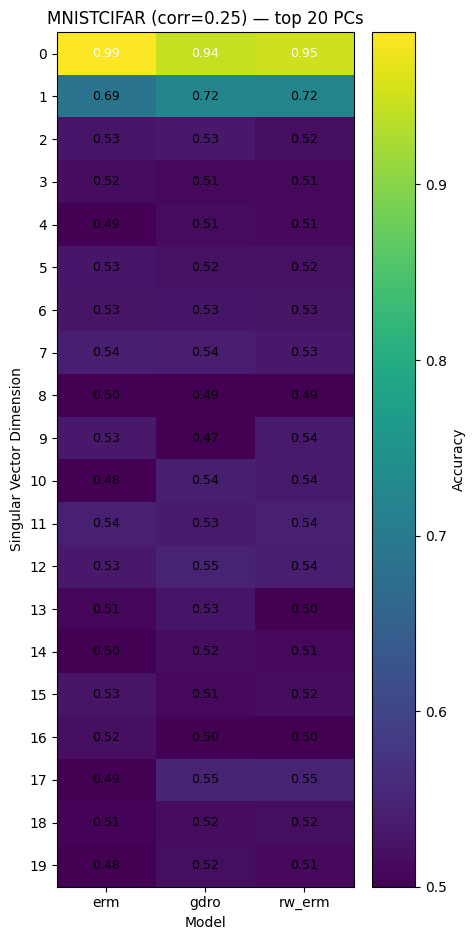

[OK] heatmap_spurious_MNISTCIFAR_0_25_K20_test.png


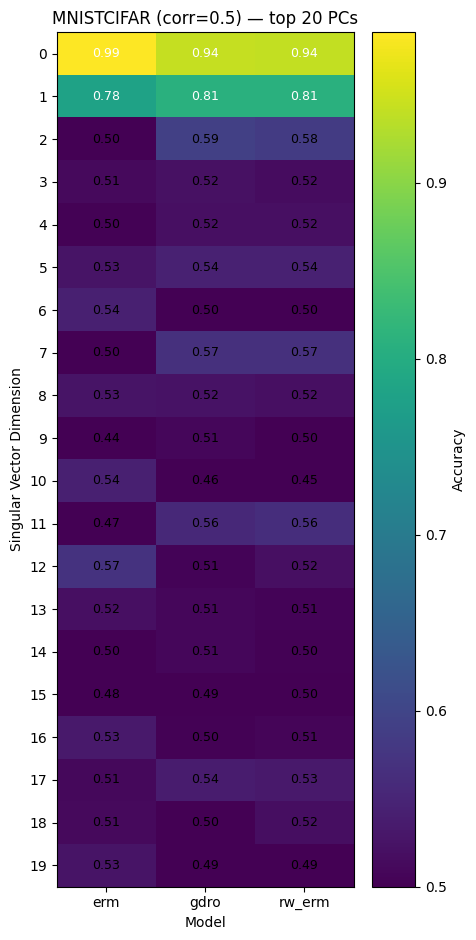

[OK] heatmap_spurious_MNISTCIFAR_0_5_K20_test.png


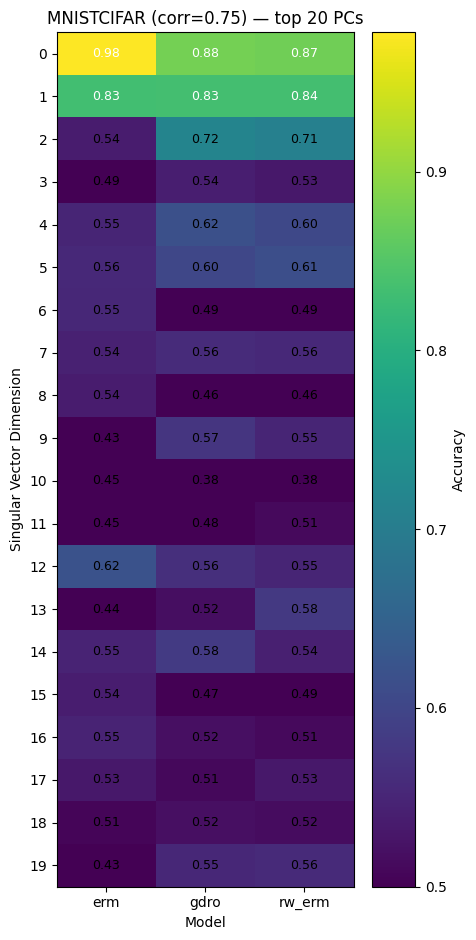

[OK] heatmap_spurious_MNISTCIFAR_0_75_K20_test.png


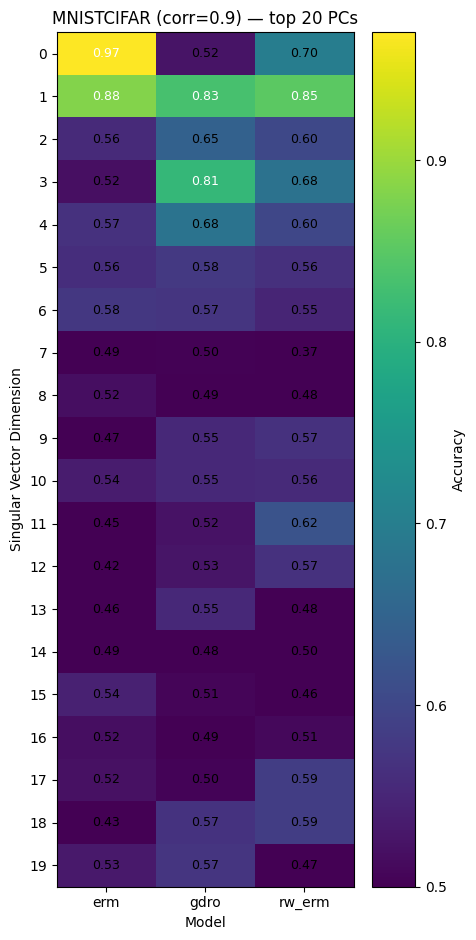

[OK] heatmap_spurious_MNISTCIFAR_0_9_K20_test.png


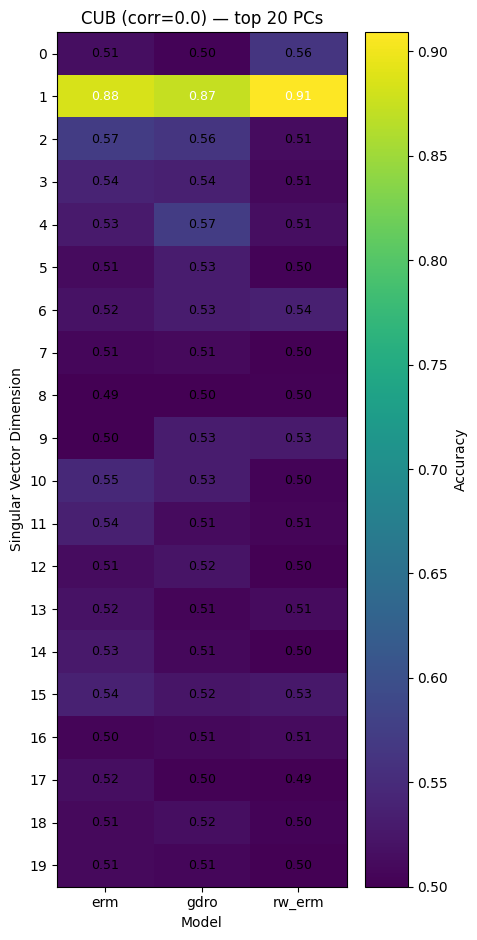

[OK] heatmap_spurious_CUB_0_0_K20_test.png


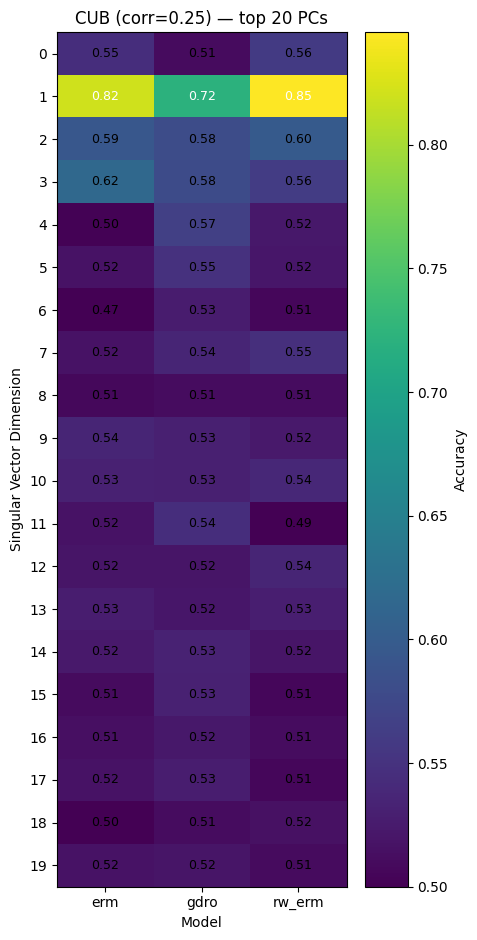

[OK] heatmap_spurious_CUB_0_25_K20_test.png


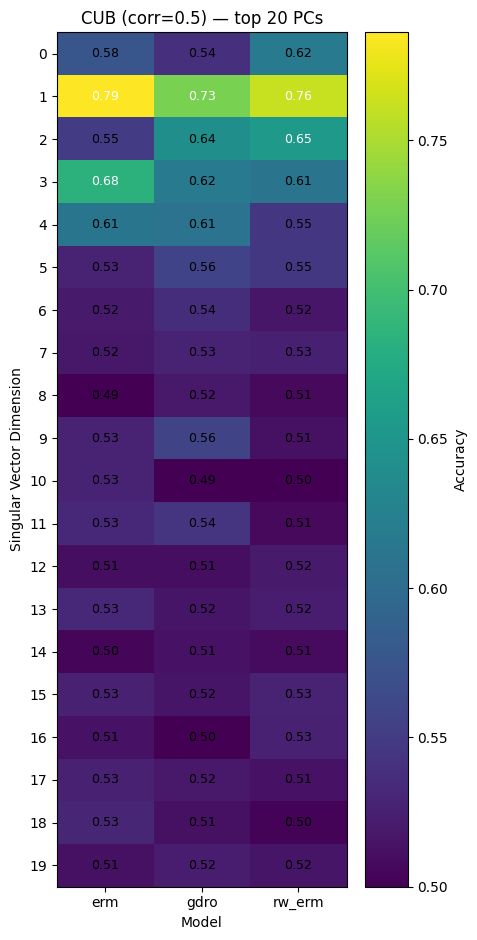

[OK] heatmap_spurious_CUB_0_5_K20_test.png


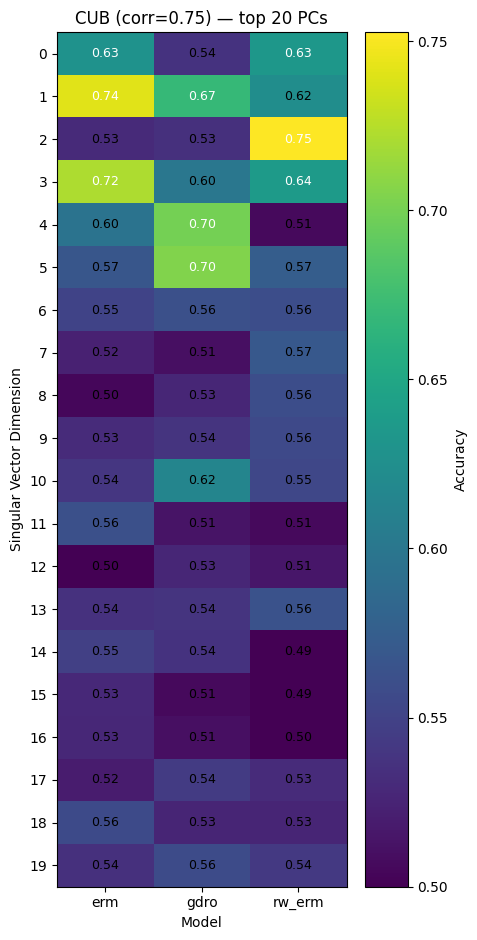

[OK] heatmap_spurious_CUB_0_75_K20_test.png


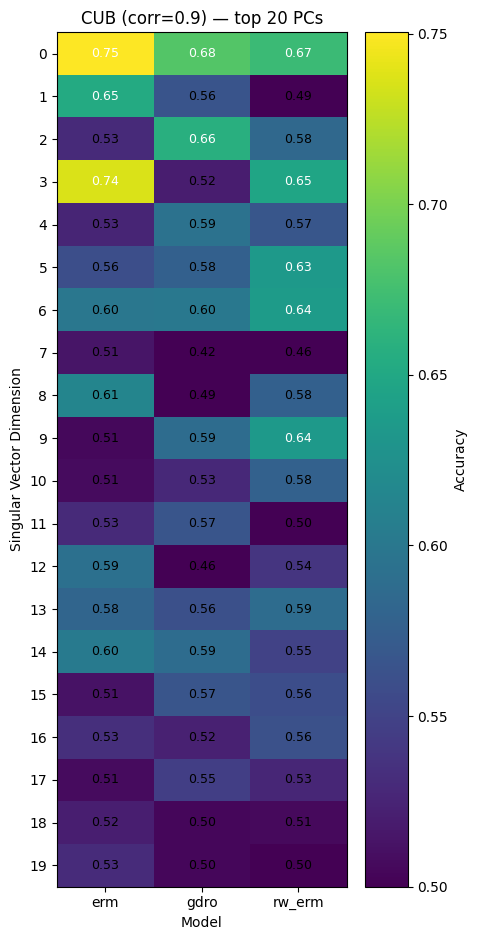

[OK] heatmap_spurious_CUB_0_9_K20_test.png


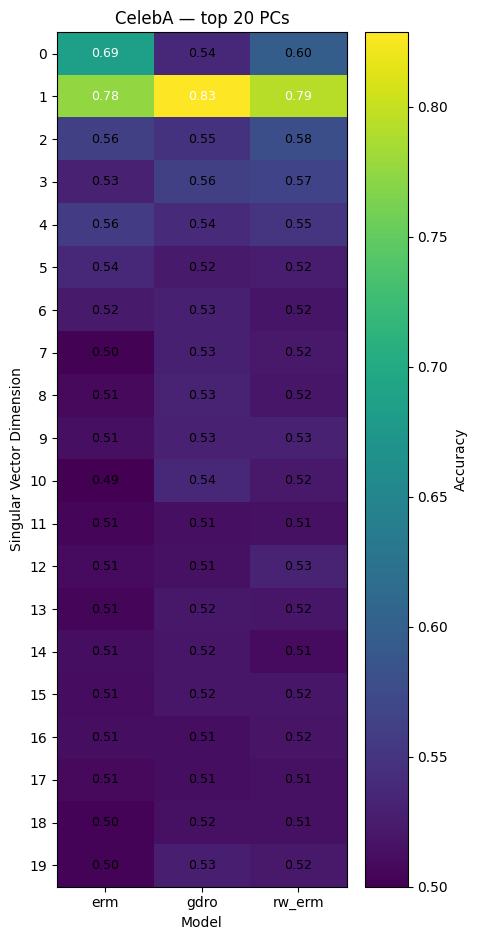

[OK] heatmap_spurious_CelebA_0.90_K20_test.png


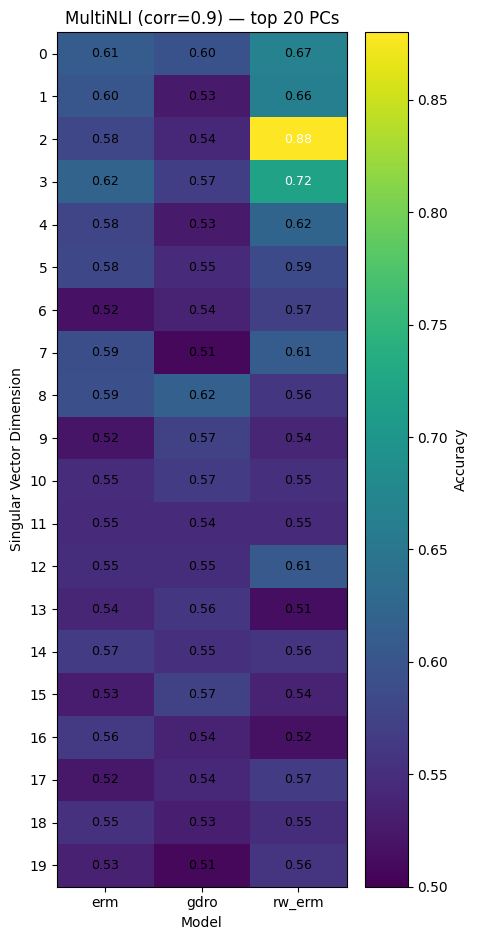

[OK] heatmap_spurious_MultiNLI_0_9_K20_test.png


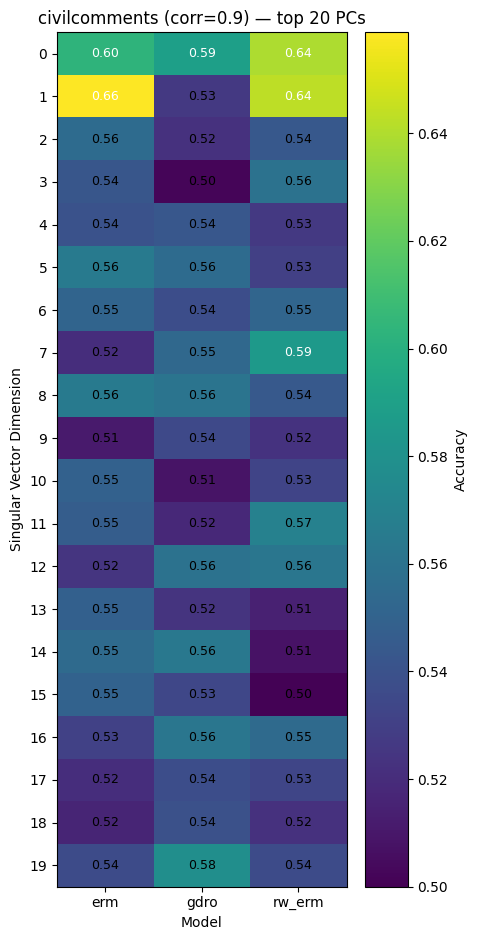

[OK] heatmap_spurious_civilcomments_0_9_K20_test.png


In [38]:
def plot_heatmap_for(ds, corr, df_agg, methods=METHODS, vmax=None, k_plot=None, split="test"):
    """
    ds: dataset (str)
    corr: float o None (para CelebA)
    df_agg: dataframe agregado por semillas con columnas:
            ['dataset','corr','method','dim','acc_test_mean', ...]
    methods: orden de columnas
    vmax: valor máximo de la barra (None -> usa el máximo observado)
    k_plot: cuántas dimensiones PCA mostrar (None -> todas disponibles)
    """
    # Selección de filas para ese dataset-corr
    sub = df_agg[(df_agg["dataset"]==ds) &
                 (df_agg["corr"].fillna(0.9) == (0.9 if pd.isna(corr) else corr))]
    if sub.empty:
        print(f"[skip] sin datos agregados para {ds}-{corr}")
        return

    # K disponible = menor #dim presente entre métodos
    K_avail = int(sub.groupby("method")["dim"].max().dropna().min() + 1)
    K = K_avail if (k_plot is None) else min(int(k_plot), K_avail)

    # Armar matriz (K x M)
    M = len(methods)
    mat = np.full((K, M), np.nan, dtype=float)
    for j, method in enumerate(methods):
        msub = sub[sub["method"]==method]
        for d in range(K):
            val = msub[msub["dim"]==d][f"acc_{split}_mean"]
            if len(val):
                mat[d, j] = float(val.iloc[0])

    # Rango de colores
    vmin = 0.5
    if vmax is None:
        vmax = float(np.nanmax(mat)) if np.isfinite(np.nanmax(mat)) else 1.0
        vmax = max(vmax, 0.6)  # por si todo está muy bajo

    # Plot
    plt.figure(figsize=(3 + 0.6*M, 0.35*K + 2.5))
    im = plt.imshow(mat, origin="upper", aspect="auto", vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(im, label="Accuracy")

    # Ejes
    plt.xticks(np.arange(M), methods)
    plt.yticks(np.arange(K), np.arange(K))
    plt.xlabel("Model")
    plt.ylabel("Singular Vector Dimension")
    title_corr = "" if ds=="CelebA" else f" (corr={corr})"
    plt.title(f"{ds}{title_corr} — top {K} PCs")

    # ---- Anotar cada celda con el valor ----
    # Umbral para color del texto según fondo
    threshold = (vmin + vmax) / 2.0
    for i in range(K):
        for j in range(M):
            val = mat[i, j]
            if not np.isnan(val):
                txt_color = "white" if val >= threshold else "black"
                plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=txt_color)

    plt.tight_layout()
    fname = f"heatmap_spurious_{ds}_{'0.90' if ds=='CelebA' else str(corr).replace('.','_')}_K{K}_{split}.png"
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=150)
    plt.show()
    print(f"[OK] {fname}")
for ds in DATASETS:
     for corr in CORRS[ds]:
         plot_heatmap_for(ds, None if ds=="CelebA" else corr, agg,
                          methods=METHODS, vmax=None, k_plot=20, split="test")

## Correlation

In [17]:
import pandas as pd
import numpy as np

# ====== RELLENA ESTAS RUTAS ======
PATHS = {
    "CelebA": {
        "metadata": "../../datasets/celeba/metadata.csv",
        "eval_partition": None,  # si ocupas list_eval_partition.csv
    },
    "CivilComments": {
        "metadata": "../../datasets/jigsaw/data/all_data_with_identities.csv",
    },
    "MultiNLI": {
        "metadata": "../../datasets/multinli/data/metadata.csv",
    },
}
# =================================

def to_binary(s):
    v = s.copy()
    if set(pd.unique(v.dropna())) <= {-1, 1}:
        v = (v == 1).astype(int)
    elif v.dtype == bool:
        v = v.astype(int)
    else:
        v = (v.astype(float) >= 0.5).astype(int)
    return v

def phi_corr(a, b):
    a = to_binary(pd.Series(a)).astype(float)
    b = to_binary(pd.Series(b)).astype(float)
    if a.std() == 0 or b.std() == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0,1])

def print_block(title):
    print("\n" + "="*len(title))
    print(title)
    print("="*len(title))

def _counts_2x2(sub, y_col, g_col):
    """Devuelve conteos asegurando todas las celdas del 2x2."""
    y = to_binary(sub[y_col])
    g = to_binary(sub[g_col])
    # crosstab y (rows) x g (cols)
    ct = pd.crosstab(y, g)
    # asegurar índices/columnas {0,1}
    for idx in [0,1]:
        if idx not in ct.index: ct.loc[idx] = 0
        if idx not in ct.columns: ct[idx] = 0
    ct = ct.sort_index().sort_index(axis=1)
    # ordenar en tuplas útiles
    n00 = int(ct.loc[0,0])
    n01 = int(ct.loc[0,1])
    n10 = int(ct.loc[1,0])
    n11 = int(ct.loc[1,1])
    N = n00 + n01 + n10 + n11
    return {"n00": n00, "n01": n01, "n10": n10, "n11": n11, "N": N}

def _print_group_counts(counts, labels):
    """
    counts: dict con n00,n01,n10,n11,N
    labels: dict con nombres legibles para cada celda:
        {
          "y1": "...", "y0": "...",
          "g1": "...", "g0": "...",
          "y1g1": "...", "y1g0": "...", "y0g1": "...", "y0g0": "..."
        }
    """
    n00, n01, n10, n11, N = counts["n00"], counts["n01"], counts["n10"], counts["n11"], counts["N"]
    rows = [
        (labels["y1g1"], n11),
        (labels["y1g0"], n10),
        (labels["y0g1"], n01),
        (labels["y0g0"], n00),
    ]
    width = max(len(r[0]) for r in rows)
    for name, n in rows:
        pct = 100.0 * n / N if N > 0 else 0.0
        print(f"  {name:<{width}} : {n:>7}  ({pct:6.2f}%)")
    print(f"  {'Total':<{width}} : {N:>7}")

def corr_by_splits(df, y_col, g_col, split_col="split", labels=None):
    # detectar/normalizar split
    if split_col and split_col in df.columns:
        s = df[split_col]
        if s.dropna().map(type).isin([str]).mean() > 0.5:
            split_map = {"train": "train", "val": "val", "test": "test"}
            df["_split_std_"] = s.map(split_map).fillna("all")
        else:
            split_map = {0:"train", 1:"val", 2:"test"}
            df["_split_std_"] = s.map(split_map).fillna("all")
    else:
        df["_split_std_"] = "all"

    results = []
    for sp in ["train","val","test","all"]:
        sub = df if sp=="all" else df[df["_split_std_"]==sp]
        if len(sub)==0: 
            continue
        phi = phi_corr(sub[y_col], sub[g_col])
        counts = _counts_2x2(sub, y_col, g_col)
        results.append({"split": sp, "n": len(sub), "phi": phi, "counts": counts, "labels": labels})
    del df["_split_std_"]
    return results

# -------- CelebA --------
def celebA_corr(paths):
    meta_path = paths["metadata"]
    df = pd.read_csv(meta_path)
    # Si es list_attr_celeba.csv (sin split) y tienes list_eval_partition.csv:
    if "Blond_Hair" in df.columns and "Male" in df.columns and "split" not in df.columns and paths.get("eval_partition"):
        part = pd.read_csv(paths["eval_partition"])  # debe tener columnas image_id y partition (0/1/2)
        # Ajusta si tus archivos usan 'image_id' o 'filename'
        key = "image_id" if "image_id" in df.columns else "image_id"
        df = df.merge(part.rename(columns={"partition":"split"}), on=key, how="left")

    y_col = "Blond_Hair"   # 1 = Blond, 0 = NonBlond
    g_col = "Male"         # 1 = Male,  0 = Female
    df[y_col] = to_binary(df[y_col])
    df[g_col] = to_binary(df[g_col])

    labels = {
        "y1": "Blonde", "y0": "NonBlonde",
        "g1": "Male",   "g0": "Female",
        "y1g1": "Blonde–Male",
        "y1g0": "Blonde–Female",
        "y0g1": "NonBlonde–Male",
        "y0g0": "NonBlonde–Female",
    }

    res = corr_by_splits(df, y_col, g_col, split_col="split" if "split" in df.columns else None, labels=labels)
    print_block("CelebA  (y=Blond_Hair, g=Male)")
    for r in res:
        print(f"{r['split']:<5}  n={r['n']:>7}  phi={r['phi']:+.4f}")
        _print_group_counts(r["counts"], r["labels"])
    return res

# -------- CivilComments (Jigsaw) --------
def civil_corr(paths):
    df = pd.read_csv(paths["metadata"])
    y_col = "toxicity"
    g_col = "identity_any" if "identity_any" in df.columns else None
    if g_col is None:
        ident_cols = [c for c in df.columns if c not in ("id","split","comment_text","toxicity") and df[c].dtype!=object]
        ident_cols = [c for c in ident_cols if df[c].notna().any()]
        if not ident_cols:
            raise ValueError("No encontré 'identity_any' ni columnas de identidad.")
        df["identity_any"] = (df[ident_cols].astype(float) >= 0.5).any(axis=1).astype(int)
        g_col = "identity_any"

    df[y_col] = to_binary(df[y_col])        # 1 = tóxico (>=0.5), 0 = no-tóxico
    df[g_col] = to_binary(df[g_col])        # 1 = menciona identidad, 0 = no

    labels = {
        "y1": "Toxic", "y0": "NonToxic",
        "g1": "Identity", "g0": "NoIdentity",
        "y1g1": "Toxic–Identity",
        "y1g0": "Toxic–NoIdentity",
        "y0g1": "NonToxic–Identity",
        "y0g0": "NonToxic–NoIdentity",
    }

    res = corr_by_splits(df, y_col, g_col, split_col="split" if "split" in df.columns else None, labels=labels)
    print_block("CivilComments  (y=toxicity>=0.5, g=identity_any)")
    for r in res:
        print(f"{r['split']:<5}  n={r['n']:>7}  phi={r['phi']:+.4f}")
        _print_group_counts(r["counts"], r["labels"])
    return res

# -------- MultiNLI --------
def multinli_corr(paths):
    df = pd.read_csv(paths["metadata"])
    y_col_raw = "gold_label_random" if "gold_label_random" in df.columns else "gold_label"
    if df[y_col_raw].dtype == object:
        map3 = {"contradiction":0, "entailment":1, "neutral":2}
        y3 = df[y_col_raw].map(map3).astype(int)
    else:
        y3 = df[y_col_raw].astype(int)
    # binario: y=1 si contradiction
    y_bin = (y3 == 0).astype(int)
    df = df.copy()
    df["y_contra"] = y_bin

    g_col = "sentence2_has_negation"
    if g_col not in df.columns:
        raise ValueError("No encontré 'sentence2_has_negation' en MultiNLI metadata.")
    df[g_col] = to_binary(df[g_col])  # 1 = hay negación, 0 = no

    labels = {
        "y1": "Contradiction", "y0": "NotContradiction",
        "g1": "Negation", "g0": "NoNegation",
        "y1g1": "Contradiction–Negation",
        "y1g0": "Contradiction–NoNegation",
        "y0g1": "NotContradiction–Negation",
        "y0g0": "NotContradiction–NoNegation",
    }

    res = corr_by_splits(df, "y_contra", g_col, split_col="split" if "split" in df.columns else None, labels=labels)
    print_block("MultiNLI  (y=contradiction vs rest, g=sentence2_has_negation)")
    for r in res:
        print(f"{r['split']:<5}  n={r['n']:>7}  phi={r['phi']:+.4f}")
        _print_group_counts(r["counts"], r["labels"])
    return res

# ---- Ejecutar ----
out = {}
out["CelebA"]        = celebA_corr(PATHS["CelebA"])
out["CivilComments"] = civil_corr(PATHS["CivilComments"])
out["MultiNLI"]      = multinli_corr(PATHS["MultiNLI"])



CelebA  (y=Blond_Hair, g=Male)
train  n= 162770  phi=-0.3073
  Blonde–Male      :    1387  (  0.85%)
  Blonde–Female    :   22880  ( 14.06%)
  NonBlonde–Male   :   66874  ( 41.08%)
  NonBlonde–Female :   71629  ( 44.01%)
  Total            :  162770
val    n=  19867  phi=-0.3158
  Blonde–Male      :     182  (  0.92%)
  Blonde–Female    :    2874  ( 14.47%)
  NonBlonde–Male   :    8276  ( 41.66%)
  NonBlonde–Female :    8535  ( 42.96%)
  Total            :   19867
test   n=  19962  phi=-0.2567
  Blonde–Male      :     180  (  0.90%)
  Blonde–Female    :    2480  ( 12.42%)
  NonBlonde–Male   :    7535  ( 37.75%)
  NonBlonde–Female :    9767  ( 48.93%)
  Total            :   19962
all    n= 202599  phi=-0.3030
  Blonde–Male      :    1749  (  0.86%)
  Blonde–Female    :   28234  ( 13.94%)
  NonBlonde–Male   :   82685  ( 40.81%)
  NonBlonde–Female :   89931  ( 44.39%)
  Total            :  202599

CivilComments  (y=toxicity>=0.5, g=identity_any)
train  n= 269038  phi=+0.1354
  Toxic–Iden

CelebA = 0.89 Correlación
MultiNLI = 0.22
CivilComments = 0.53

In [20]:
22447/(22447+6957)*2-1

0.5267990749557883

In [19]:
import matplotlib.pyplot as plt
from torch.nn import CosineSimilarity
model = "resnet50"
dataset = "CUB"
dataset_corr = 0.0
final_report = defaultdict(list)
n_dirs = 100 # analyze first 1000 directions 
model_corr = 0.0
methods = ["erm","rw","gdro"]
seed = 111
corrs = [0.0, 0.25, 0.5, 0.75, 0.9]
# 6 x 6 x 100 directions x 3 methods = 10800 results

args = setup(model, dataset, dataset_corr)
data = prepare_data(args, train=True)
dls = {'train': DataLoader(data[0], batch_size=128, shuffle=False),
       'test': DataLoader(data[1], batch_size=128, shuffle=False)}

results = {'method': [], 'corr': [], 'cls': [], 'dim': [], 'sim': []}
sim = CosineSimilarity(dim=1)
for model_corr in tqdm(corrs, leave=False, desc="Model Correlations"):
    for method in tqdm(methods,leave=False, desc="Methods"): # 
        #print(f"{method}-{dataset} DS_Corr: {dataset_corr}-M_Corr:{model_corr}")
        model = load_model(dataset, method, model_corr)
        R_train, _ , y_train = get_reps(model, dls['train'], remove="none")
        _,_, V = torch.pca_lowrank(R_train, center=True, q=n_dirs)
        cls1 = model.fc.weight[0].detach().cuda()
        cls2 = model.fc.weight[1].detach().cuda()
        sims1 = sim(V.T, cls1)
        sims2 = sim(V.T, cls2)
        results['method'] += [method]*(2*n_dirs)
        results['corr'] += [model_corr]*(2*n_dirs)
        results['dim'] += list(range(n_dirs))
        results['cls'] += [0]*n_dirs
        results['sim'] += list(sims1.cpu())
        results['dim'] += list(range(n_dirs))
        results['cls'] += [1]*n_dirs
        results['sim'] += list(sims2.cpu())


Reading '/mnt/ialabnas/homes/araymond/investigacion/datasets/waterbird_complete50_forest2water2/metadata.csv'


Model Correlations:   0%|          | 0/5 [00:00<?, ?it/s]

Methods:   0%|          | 0/3 [00:00<?, ?it/s]

Methods:   0%|          | 0/3 [00:00<?, ?it/s]

Methods:   0%|          | 0/3 [00:00<?, ?it/s]

Methods:   0%|          | 0/3 [00:00<?, ?it/s]

Methods:   0%|          | 0/3 [00:00<?, ?it/s]

In [23]:
df

,method,corr,cls,dim,sim
0,erm,0.0,0,0,-0.798253
1,erm,0.0,0,1,-0.075378
2,erm,0.0,0,2,0.118499
3,erm,0.0,0,3,0.019451
4,erm,0.0,0,4,-0.035958
...,...,...,...,...,...
2995,gdro,0.9,1,95,0.022890
2996,gdro,0.9,1,96,-0.012867
2997,gdro,0.9,1,97,0.006849
2998,gdro,0.9,1,98,0.005329


In [20]:
df = pd.DataFrame.from_dict(results)

In [21]:
df['sim'] = df['sim'].apply(lambda x: x.item())


,method,corr,cls,dim,sim
0,erm,0.0,0,0,-0.798253
100,erm,0.0,1,0,0.786418
200,rw,0.0,0,0,0.497281
300,rw,0.0,1,0,-0.490453
400,gdro,0.0,0,0,-0.581615
500,gdro,0.0,1,0,0.542854


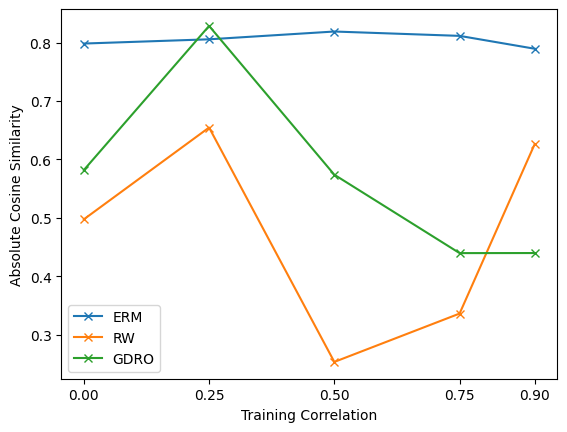

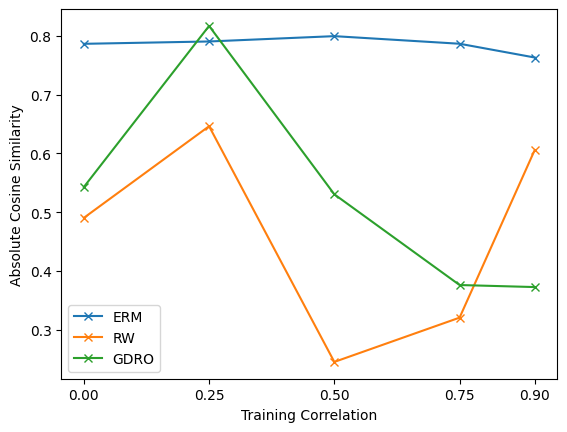

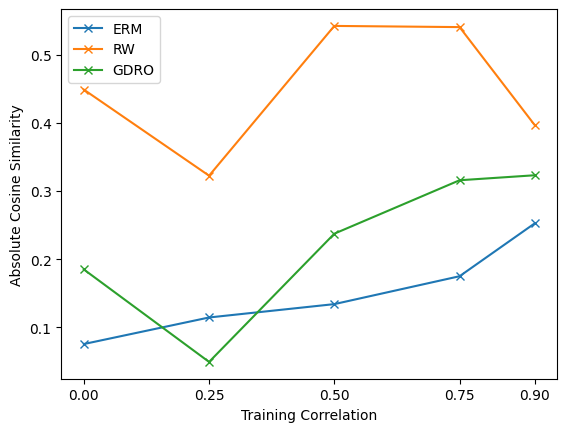

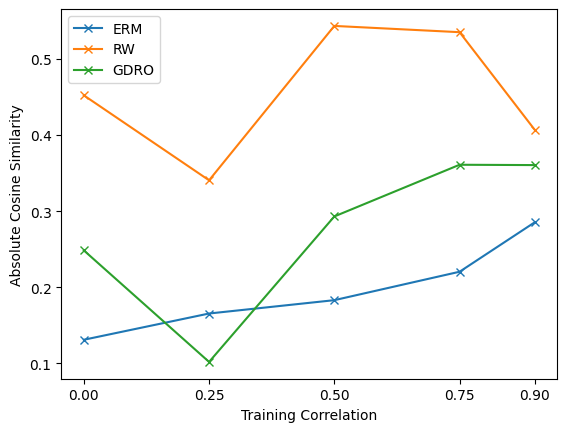

In [32]:

for dim in [0,1]:
    for method in methods:
        r = df[(df['dim']==0) & (df['method']==method) & (df['cls']==dim)]
        y = r['sim'].abs()
        x = corrs
        plt.plot(x,y, marker="x", label=method.upper())
        plt.legend()
        plt.xlabel("Training Correlation")
        plt.ylabel("Absolute Cosine Similarity")
        plt.xticks(x)
    plt.show()
    
for dim in [0,1]:
    for method in methods:
        r = df[(df['dim']==1) & (df['method']==method) & (df['cls']==dim)]
        y = r['sim'].abs()
        x = corrs
        plt.plot(x,y, marker="x", label=method.upper())
        plt.legend()
        plt.xlabel("Training Correlation")
        plt.ylabel("Absolute Cosine Similarity")
        plt.xticks(x)
    plt.show()

In [28]:
y

0   -0.798253
Name: sim, dtype: float64

0 0 100
0 1 100
0 2 100
1 0 100
1 1 100
1 2 100


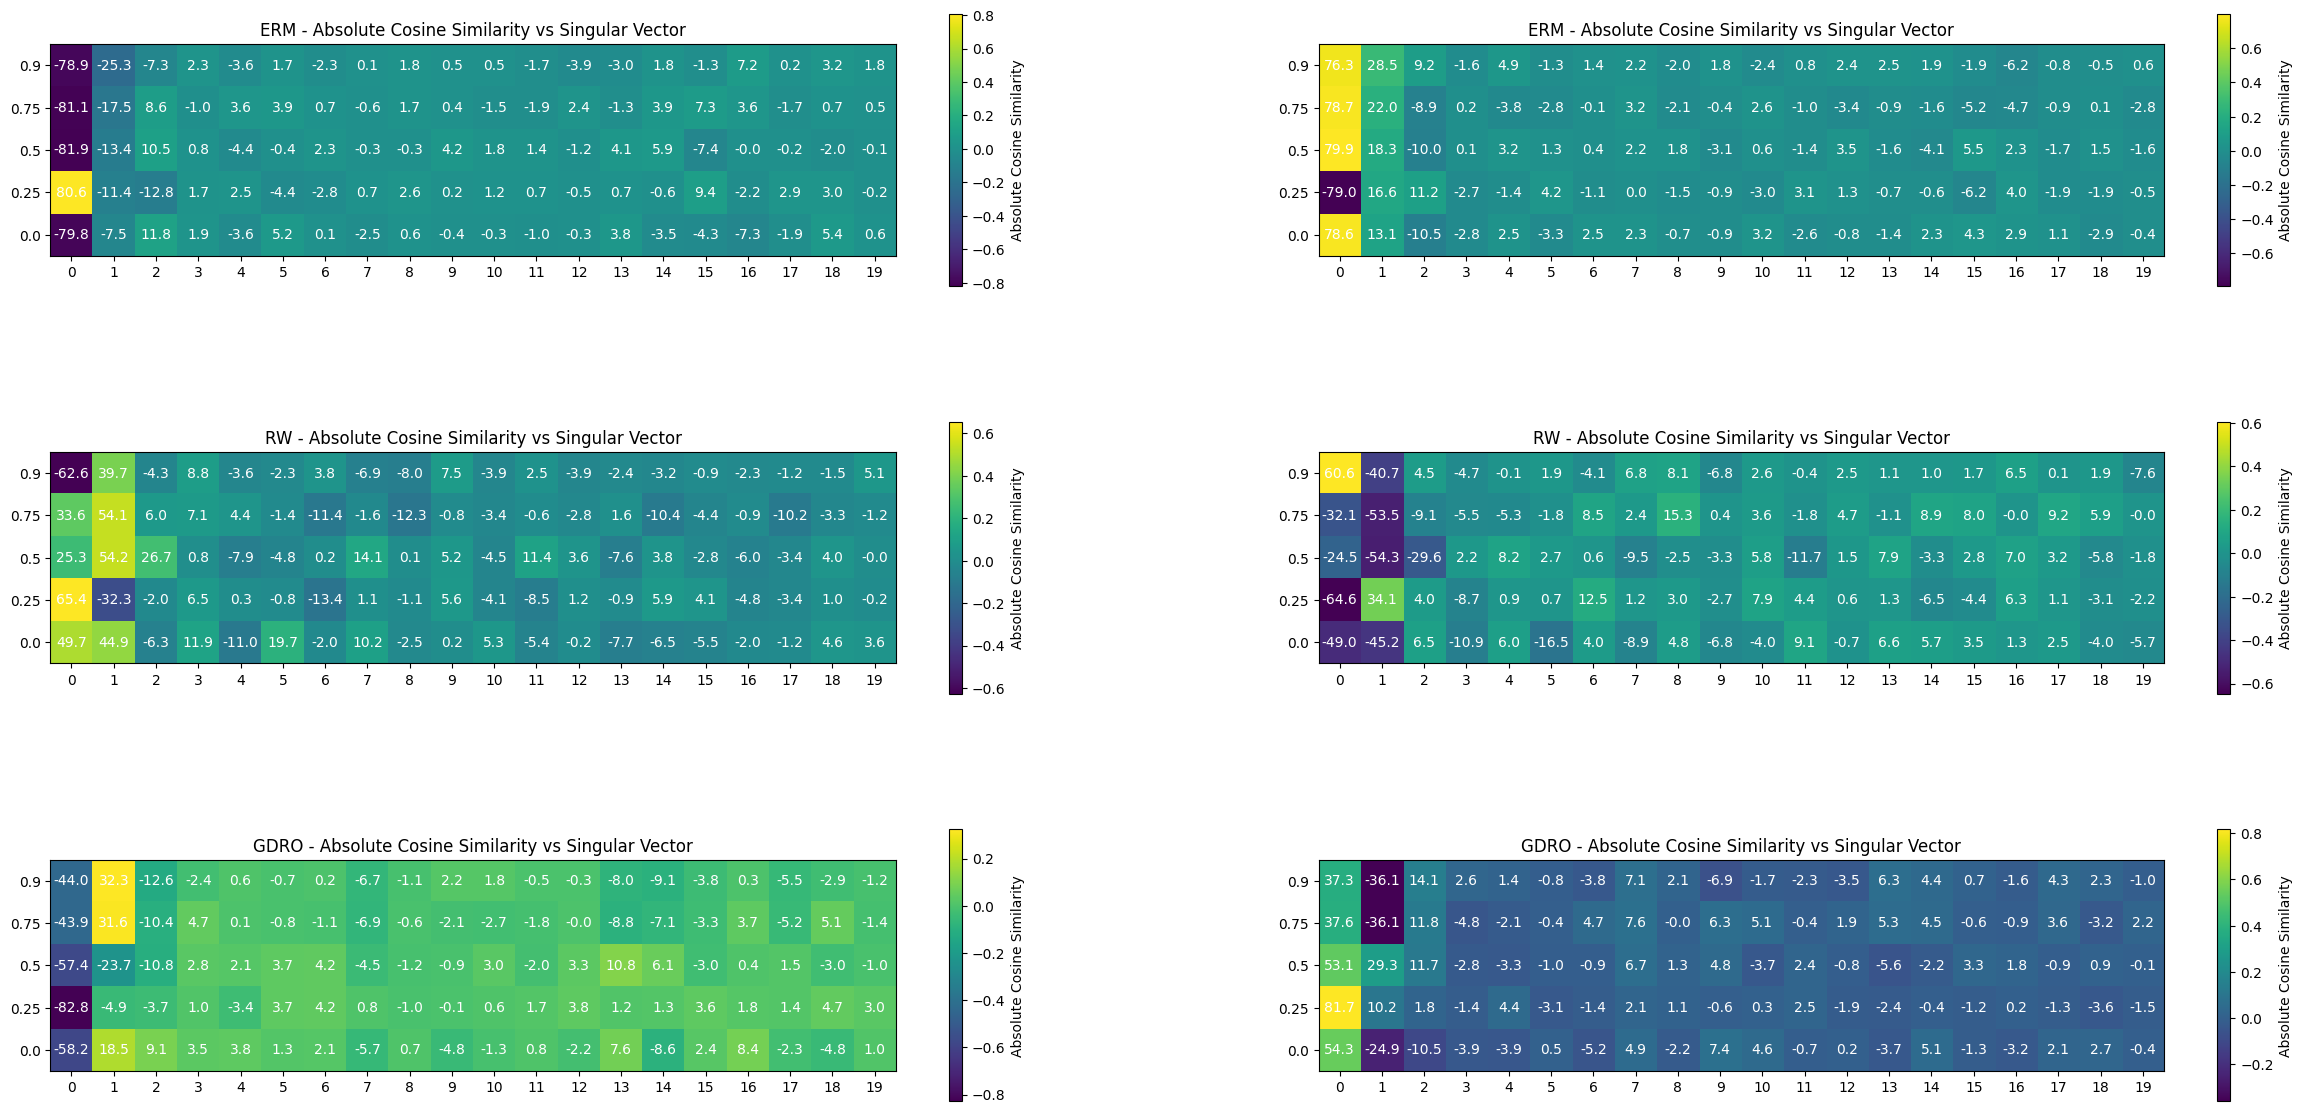

In [31]:
fig, axs = plt.subplots(figsize=(30,5*len(methods)), ncols=2, nrows=len(methods), sharey=False, sharex=False)
for j, c in enumerate([0,1]):
    for i, method in enumerate(methods):
        heatmap_data = df[(df['method']== method) & (df['cls'] == c)  & (df['dim']<20)]
        print(j,i, len(heatmap_data))
        heatmap_data = heatmap_data.pivot("corr","dim","sim")
        im = axs[i,j].imshow(heatmap_data, cmap='viridis', interpolation='nearest', origin='lower')
        # Add text annotations to the first subplot
        for k in range(len(heatmap_data.index)):
            for l in range(len(heatmap_data.columns)):
                axs[i,j].text(l, k, f'{100*heatmap_data.iloc[k, l]:.1f}', ha='center', va='center', color='white')
        axs[i, j].set_xticks(range(len(heatmap_data.columns)))
        axs[i, j].set_xticklabels(heatmap_data.columns)
        axs[i, j].set_yticks(range(len(heatmap_data.index)))
        axs[i, j].set_yticklabels(heatmap_data.index)
        axs[i, j].set_title(f"{method.upper()} - Absolute Cosine Similarity vs Singular Vector")
        fig.colorbar(im, ax=axs[i,j], label='Absolute Cosine Similarity', shrink=0.8)
plt.show()

In [41]:
len(df[(df['method']== method) & (df['cls'] == 1)  & (df['dim']<20)])

100

In [35]:
split_image(original_image, 3, 2,
            caption = f"spurious_accuracy_{dataset}",
            row_names=['erm',"reweight","gdro"], 
            column_names = ['train','test'],
            output_folder="imgs")

,method,corr,cls,dim,sim
0,erm,0.0,0,0,0.004928
1,erm,0.0,0,1,0.290713
2,erm,0.0,0,2,0.204964
3,erm,0.0,0,3,-0.026563
4,erm,0.0,0,4,0.019573
...,...,...,...,...,...
2995,gdro,0.9,1,95,-0.032089
2996,gdro,0.9,1,96,-0.034185
2997,gdro,0.9,1,97,-0.063075
2998,gdro,0.9,1,98,-0.044764
